# SOL — i fatti della campagna principale

Foglio di verita' della campagna `tests/results-main`. Ogni numero che finisce in un
articolo deve venire da una cella di questo notebook.

**Sorgente**: `tidy.csv`, una riga per run. La costruisce `load_raw.py` leggendo gli
artefatti grezzi (`<run_id>.json` + `<run_id>.score.json`) — **non** `index.csv`: l'indice
binarizza `quality` a pass/fail, non riporta ne' `quality.rate` ne' `redundancy_ratio`, e
diverge dai punteggi grezzi su alcune run (cfr. 1.8, che lo verifica).

Il grezzo pesa 213 MB e contiene i prompt somministrati, cioe' il testo delle segnalazioni
di terzi: non viene ridistribuito. `tidy.csv` porta solo identificatori e misure, e da solo
basta a rifare ogni conto di questo notebook.

## Il disegno: tre studi in sequenza, non un fattoriale

La campagna non e' un incrocio `modello x rendering x fixture`. E' una successione di tre
studi, ciascuno nato da quello prima, con una domanda e un'unita' di misura sue.

| studio | fixture | domanda | unita' | misura |
|---|---|---|---|---|
| 1 | `support-intake` | un modello locale regge un compito articolato di sola elaborazione, senza attivita' esecutive? | **la coda** (6-11 item) | quota di item corretti sulla coda |
| 2 | `support-routing` | e su uno scenario realistico, un item per volta? | **l'item** | 8 campi per item; `pass` = tutti e 8 |
| 3 | `support-routing-notrace` | stesso di 2, tolto il tracing dai comandi | **l'item** | come 2, senza le misure di traccia |

Lo studio 3 nasce da un ritrovamento dello studio 2: il tracing inserito nei comandi aveva
un effetto suo. Toglierlo costa le misure di comprensione e di condizionale
(`comprehension_rate`, `conditional_rate` non esistono nello studio 3) e in cambio da' un
dato di successo pulito. Su quella configurazione, e solo su quella, sono stati poi
somministrati anche i tre bracci **hosted** — `claude-code-haiku` (2026-08-31),
`claude-code-sonnet` e `claude-code-opus` (2026-09-02): stessa fixture, stesse venti
richieste, stessi sette rendering, stesse due repliche, stesso oracolo. Fra i tre si muove
solo l'id del modello, quindi si leggono uno contro l'altro e contro le sei celle locali.

**Conseguenza operativa**: nessuna media attraversa gli studi.

**Perimetro di questo notebook**: fatti descrittivi, con la loro N e il loro intervallo.
Le ipotesi — l'effetto del tracing, l'indifferenza di Haiku ai formati — sono confronti da
testare; il capitolo 6 dice come, e perche' non basta un p-value.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

warnings.filterwarnings("ignore", category=FutureWarning)

# I warning di scipy/statsmodels vanno letti — dicono quando un test degenera — ma il
# formato predefinito stampa il path assoluto del file che li emette, cioe' l'albero della
# macchina che ha eseguito il notebook. Cosi' l'output eseguito e' lo stesso ovunque giri,
# e chi legge vede il modulo invece del disco di qualcun altro.
def _breve(message, category, filename, lineno, line=None):
    return f"{Path(filename).name}:{lineno}: {category.__name__}: {message}\n"

warnings.formatwarning = _breve
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110

# Sorgente unica del notebook: la tabella tidy. La produce `load_raw.py`, che legge i
# `.score.json` grezzi della campagna; il grezzo pesa 213 MB e contiene i prompt somministrati,
# quindi non viene ridistribuito. Chi ha il grezzo rigenera il csv, chi ha il csv rifa i conti:
# in entrambi i casi si passa di qui, e non c'e' un secondo posto da cui i numeri possano venire.
TIDY = Path("tidy.csv")
if not TIDY.exists():
    raise FileNotFoundError(
        f"{TIDY} non c'e'. Rigenerala con `py report/analysis/load_raw.py`, che la costruisce "
        "dagli artefatti grezzi in tests/results-main/."
    )
df = pd.read_csv(TIDY)
print(f"{len(df)} run da {TIDY} "
      f"(scritta il {pd.Timestamp(TIDY.stat().st_mtime, unit='s', tz='UTC').date()})")

STUDIO = {"support-intake": "1 — intake", "support-routing": "2 — routing",
          "support-routing-notrace": "3 — notrace"}
df["studio"] = df["fixture"].map(STUDIO)
df["ok"] = (df["quality"] == "pass").astype(int)

# I tre bracci hosted: modelli su infrastruttura Anthropic, invocati via `claude -p`.
# Sono l'opposto di una cella locale su GPU, e ogni confronto "commerciale contro locale"
# deve poter dire chi e' chi in un posto solo: prima del 2026-09-02 il notebook lo diceva
# con `model != "claude-code-haiku"`, che con tre bracci hosted classificherebbe sonnet e
# opus come locali.
HOSTED = ["claude-code-haiku", "claude-code-sonnet", "claude-code-opus"]
df["hosted"] = df.model.isin(HOSTED)

print(f"hosted: {df.hosted.sum()} run su {len(df)} ({sorted(df[df.hosted].model.unique())})")
print()
print(df.groupby("studio").agg(
    run=("run_id", "size"),
    input_distinti=("input_id", "nunique"),
    modelli=("model", "nunique"),
    rendering=("rendering", "nunique"),
).to_string())

5431 run da tidy.csv (scritta il 2026-09-05)
hosted: 840 run su 5431 (['claude-code-haiku', 'claude-code-opus', 'claude-code-sonnet'])

              run  input_distinti  modelli  rendering
studio                                               
1 — intake   1236              10        6          7
2 — routing  1676              20        6          7
3 — notrace  2519              20        9          7


## 1. Audit del dato

Prima di qualunque media: cosa c'e' dentro, cosa manca, quanto e' bilanciato il disegno,
e se le fonti concordano. Un numero calcolato su un disegno sbilanciato o su un missing
sistematico non e' sbagliato per poco: e' la risposta a una domanda diversa da quella che
credi di aver fatto.

In [2]:
# --- 1.1 Ampiezza e fattori ---
fattori = ["studio", "fixture", "input_id", "model", "rendering", "rep",
           "reasoning_budget", "runner_type"]
audit = pd.DataFrame({
    "valori distinti": [df[c].nunique() for c in fattori],
    "esempio": [", ".join(map(str, sorted(df[c].dropna().unique())[:4])) for c in fattori],
}, index=fattori)
print(f"N run = {len(df)}")
audit

N run = 5431


,valori distinti,esempio
studio,3,"1 — intake, 2 — routing, 3 — notrace"
fixture,3,"support-intake, support-routing, support-routi..."
input_id,30,"queue-01, queue-02, queue-03, queue-04"
model,9,"claude-code-haiku, claude-code-opus, claude-co..."
rendering,7,"L0, L1, L2, L3"
rep,3,"1, 2, 3"
reasoning_budget,2,"0, 12000"
runner_type,2,"api, claude-code"


In [3]:
# --- 1.2 Missing per colonna ---
# La domanda non e' "quanto manca" ma "manca a caso?". Un missing che dipende dallo
# studio non e' rumore: e' un sottocampione selezionato, e mediarci sopra e' un bias.
miss = df.isna().sum()
miss = miss[miss > 0].sort_values(ascending=False).to_frame("mancanti")
miss["% su N"] = (100 * miss["mancanti"] / len(df)).round(1)
miss

,mancanti,% su N
observed_branch,5431,100.0
expected_branch,5431,100.0
conditional_rate,3952,72.8
comprehension_rate,3952,72.8
temperature,840,15.5
payload_status,551,10.1
quality_rate,465,8.6
stop_reason,10,0.2
sequence_rate,10,0.2
comprehension,10,0.2


In [4]:
# --- 1.3 Il missing delle misure di traccia dipende dallo studio ---
disp = df.groupby("studio")[["quality_rate", "sequence_rate",
                             "comprehension_rate", "conditional_rate"]].apply(
    lambda g: g.notna().mean().round(3))
print("Quota di run con la misura disponibile:")
print(disp.to_string())
print()
print("Studio 3: comprehension_rate e conditional_rate azzerate per costruzione — e' il")
print("prezzo pagato per il dato di successo senza tracing, non un buco nei dati.")
print("Ogni statistica su quei due tassi vale sugli studi 1 e 2 soltanto.")

Quota di run con la misura disponibile:
             quality_rate  sequence_rate  comprehension_rate  conditional_rate
studio                                                                        
1 — intake          0.837          0.994               0.520             0.520
2 — routing         0.888          1.000               0.499             0.499
3 — notrace         0.969          0.999               0.000             0.000

Studio 3: comprehension_rate e conditional_rate azzerate per costruzione — e' il
prezzo pagato per il dato di successo senza tracing, non un buco nei dati.
Ogni statistica su quei due tassi vale sugli studi 1 e 2 soltanto.


In [5]:
# --- 1.4 Colonne morte ---
morte = [c for c in df.columns if df[c].isna().all()]
print("Colonne vuote su tutte le righe:", morte)
print()
print("expected_branch/observed_branch non sono mai stati popolati: il controllo di ramo")
print("non ha prodotto valori. Il verdetto 'fidelity' poggia interamente su sequence_rate.")
df = df.drop(columns=morte)

Colonne vuote su tutte le righe: ['expected_branch', 'observed_branch']

expected_branch/observed_branch non sono mai stati popolati: il controllo di ramo
non ha prodotto valori. Il verdetto 'fidelity' poggia interamente su sequence_rate.


In [6]:
# --- 1.5 Repliche duplicate ---
# Ogni cella (fixture x input x modello x rendering) dovrebbe avere rep 1..n distinti.
dup = df[df.duplicated(subset=["cell", "rep"], keep=False)]
n_dup = len(dup)
print(f"Run con (cella, rep) duplicato: {n_dup}")
if n_dup:
    print(dup[["cell", "rep", "run_id", "quality", "quality_rate"]]
          .sort_values(["cell", "rep"]).to_string(index=False))
    print()
    print("Sono ri-esecuzioni aggiunte in coda, non sostituzioni: stessa cella e stesso")
    print(f"numero di replica, timestamp diverso. Restano nel dataset — {n_dup} run su")
    print(f"{len(df)} ({100*n_dup/len(df):.2f}%) non spostano nessuna stima, e scegliere")
    print("quale tenere richiederebbe una regola che non e' scritta da nessuna parte.")

Run con (cella, rep) duplicato: 12
                                           cell  rep                                                                                                    run_id quality  quality_rate
  support-intake|queue-07|qwen3.5-9b-nothink|L0    3 w2-branching-support-intake-queue-07-20260823T010736-qwen3.5-9b-nothink-llama-qwen3.5-9b-nothink-L0-rep03    fail      0.860465
  support-intake|queue-07|qwen3.5-9b-nothink|L0    3 w2-branching-support-intake-queue-07-20260823T142030-qwen3.5-9b-nothink-llama-qwen3.5-9b-nothink-L0-rep03    fail      0.930233
  support-intake|queue-07|qwen3.5-9b-nothink|L4    2 w2-branching-support-intake-queue-07-20260823T013604-qwen3.5-9b-nothink-llama-qwen3.5-9b-nothink-L4-rep02    fail      0.860465
  support-intake|queue-07|qwen3.5-9b-nothink|L4    2 w2-branching-support-intake-queue-07-20260823T142117-qwen3.5-9b-nothink-llama-qwen3.5-9b-nothink-L4-rep02    fail      0.883721
  support-intake|queue-07|qwen3.5-9b-nothink|L4    3 w2-bran

In [7]:
# --- 1.6 Bilanciamento del disegno ---
ct = pd.crosstab(df["rendering"], df["model"], margins=True)
print(ct.to_string())
print()
n_cell = df.groupby(["model", "rendering"]).size()
print(f"Celle modello x rendering: {len(n_cell)}, da {n_cell.min()} a {n_cell.max()} run.")
print("=> Sbilanciato. La media marginale per modello e' pesata su un mix di rendering")
print("   diverso da modello a modello: confronti solo a rendering fissato, o dentro")
print("   il singolo studio dove il disegno e' pieno (cfr. 4.2).")

model             claude-code-haiku  claude-code-opus  claude-code-sonnet  gemma-4-12b  granite-4.1-8b  ministral-8b  phi4-mini  qwen3.5-9b-nothink  qwen3.5-9b-think   All
rendering                                                                                                                                                                  
L0                               40                40                  40          110             107           110        110                 111               111   779
L1                               40                40                  40          110             107           110        110                 110               110   777
L2                               40                40                  40          110             107           110        110                 110               112   779
L3                               40                40                  40          110             103           110        110             

In [8]:
# --- 1.7 Il confondimento modello x studio ---
ct = pd.crosstab(df["model"], df["studio"])
print(ct.to_string())
print()
print("I tre bracci hosted esistono SOLO nello studio 3, per come e' andata la campagna.")
print("Confrontarli con i modelli locali su medie che attraversano gli studi misura")
print("modello e compito insieme. Ogni confronto che li coinvolge sta dentro lo studio 3.")
print()
print("Fra loro invece il confronto e' pulito: stessa fixture, stessi item, stessi")
print("rendering, stesse repliche. E' l'unico posto della campagna dove tre modelli")
print("differiscono per una sola coordinata.")

studio              1 — intake  2 — routing  3 — notrace
model                                                   
claude-code-haiku            0            0          280
claude-code-opus             0            0          280
claude-code-sonnet           0            0          280
gemma-4-12b                207          280          280
granite-4.1-8b             189          276          276
ministral-8b               207          280          280
phi4-mini                  210          280          280
qwen3.5-9b-nothink         213          280          280
qwen3.5-9b-think           210          280          283

I tre bracci hosted esistono SOLO nello studio 3, per come e' andata la campagna.
Confrontarli con i modelli locali su medie che attraversano gli studi misura
modello e compito insieme. Ogni confronto che li coinvolge sta dentro lo studio 3.

Fra loro invece il confronto e' pulito: stessa fixture, stessi item, stessi
rendering, stesse repliche. E' l'unico posto della ca

In [9]:
# --- 1.8 L'indice concorda con i punteggi grezzi? ---
# index.csv e' un derivato: se diverge dai .score.json, non e' una proiezione fedele
# del grezzo e non va usato come sorgente.
idx = pd.read_csv(Path("../../tests/results-main/index.csv"))
cmp_ = df[["run_id", "quality"]].merge(idx[["run_id", "quality"]], on="run_id",
                                       suffixes=("_grezzo", "_indice"),
                                       how="outer", indicator=True)
print("Copertura:", cmp_["_merge"].value_counts().to_dict())
dis = cmp_[(cmp_._merge == "both") & (cmp_.quality_grezzo != cmp_.quality_indice)]
n_dis = len(dis)
print(f"\nRun su cui indice e grezzo danno un verdetto 'quality' diverso: {n_dis}")
if n_dis:
    print(pd.crosstab(dis.quality_indice, dis.quality_grezzo,
                      rownames=["index.csv"], colnames=["score.json"]).to_string())
    print()
    print("L'indice e' stato rigenerato in un momento diverso dalla valutazione: non e'")
    print("una proiezione fedele del grezzo. Ragione in piu' per leggere i .score.json.")

Copertura: {'both': 5431, 'left_only': 0, 'right_only': 0}

Run su cui indice e grezzo danno un verdetto 'quality' diverso: 17
score.json     fail  not_checkable  pass
index.csv                               
fail              0             15     1
not_checkable     1              0     0

L'indice e' stato rigenerato in un momento diverso dalla valutazione: non e'
una proiezione fedele del grezzo. Ragione in piu' per leggere i .score.json.


## 2. Che cosa misura ciascuno studio

`n_expected_steps` distingue i due regimi: nello studio 1 una run elabora una coda intera;
negli studi 2 e 3 una run elabora **un item solo**. La stessa colonna `quality_rate`
significa quindi due cose diverse, e va letta due volte.

In [10]:
# --- 2.1 Item per run ---
print(df.groupby("studio")["n_expected_steps"].agg(["count", "min", "median", "max"]).to_string())
print()

# --- 2.2 Che valori assume quality_rate ---
for s, g in df.groupby("studio"):
    v = g["quality_rate"].dropna()
    u = np.sort(v.unique())
    print(f"{s}: {len(v)} run, {len(u)} valori distinti")
    if len(u) <= 12:
        print(f"   valori: {[round(float(x), 3) for x in u]}")
    else:
        print(f"   continuo, da {u.min():.3f} a {u.max():.3f}")
print()
print("Studio 1: continuo — quota di item corretti sulla coda. E' nativamente il 'k su n'.")
print("Studi 2-3: multipli di 1/8 — quota di CAMPI corretti dentro l'unico item.")
print("           'pass' = tutti e otto i campi giusti; il dato per item e' binario,")
print("           e il 'k su 20' va COSTRUITO aggregando gli item (cfr. 4.2).")

             count  min  median   max
studio                               
1 — intake    1229  6.0     9.0  11.0
2 — routing   1676  1.0     1.0   1.0
3 — notrace   2516  1.0     1.0   1.0

1 — intake: 1035 run, 168 valori distinti
   continuo, da 0.000 a 1.000
2 — routing: 1489 run, 9 valori distinti
   valori: [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]
3 — notrace: 2442 run, 9 valori distinti
   valori: [0.0, 0.125, 0.25, 0.375, 0.5, 0.625, 0.75, 0.875, 1.0]

Studio 1: continuo — quota di item corretti sulla coda. E' nativamente il 'k su n'.
Studi 2-3: multipli di 1/8 — quota di CAMPI corretti dentro l'unico item.
           'pass' = tutti e otto i campi giusti; il dato per item e' binario,
           e il 'k su 20' va COSTRUITO aggregando gli item (cfr. 4.2).


### 2.3 Che cosa nasconde la binarizzazione

`quality` e' un'etichetta a tre valori derivata da una misura continua. Vale la pena
vedere dove taglia, perche' la soglia non e' dove uno se l'aspetta.

In [11]:
print(df.groupby("quality")["quality_rate"]
         .agg(["count", "mean", "std", "min", "max"]).round(3).to_string())
print()
print(df.groupby("fidelity")["sequence_rate"]
        .agg(["count", "mean", "std", "min", "max"]).round(3).to_string())
print()
print("quality='pass' <=> quality_rate == 1.0 ESATTO: 'pass' vuol dire perfetto, non buono.")
print(f"I 'fail' hanno quality_rate medio {df.loc[df.quality=='fail','quality_rate'].mean():.3f}: "
      "il fallimento medio ha due terzi del lavoro giusto.")
print(f"Su fidelity il quadro e' opposto: i 'fail' stanno a "
      f"{df.loc[df.fidelity=='fail','sequence_rate'].mean():.3f}, quasi a zero.")
print("Le due etichette 'fail' non significano la stessa cosa e non vanno sommate.")
print()
print("degradation_mode e' l'etichetta della CAUSA del fallimento, non una misura")
print("indipendente: coincide con quality.")
print(pd.crosstab(df["degradation_mode"], df["quality"]).to_string())

               count   mean    std  min  max
quality                                     
fail            3001  0.639  0.213  0.0  1.0
not_checkable      0    NaN    NaN  NaN  NaN
pass            1965  1.000  0.000  1.0  1.0

               count   mean    std  min    max
fidelity                                      
fail            4889  0.049  0.152  0.0  0.909
not_checkable      0    NaN    NaN  NaN    NaN
pass             532  1.000  0.000  1.0  1.000

quality='pass' <=> quality_rate == 1.0 ESATTO: 'pass' vuol dire perfetto, non buono.
I 'fail' hanno quality_rate medio 0.639: il fallimento medio ha due terzi del lavoro giusto.
Su fidelity il quadro e' opposto: i 'fail' stanno a 0.049, quasi a zero.
Le due etichette 'fail' non significano la stessa cosa e non vanno sommate.

degradation_mode e' l'etichetta della CAUSA del fallimento, non una misura
indipendente: coincide con quality.


quality           fail  not_checkable  pass
degradation_mode                           
budget-drift        83              0     0
halt-not-taken      82              0     0
no-halt            429             28     1
no-output            0            398     0
none                 0              0  1963
partial-sequence    87              1     1
refused              0             28     0
timeout             10              0     0
wrong-value       2320              0     0


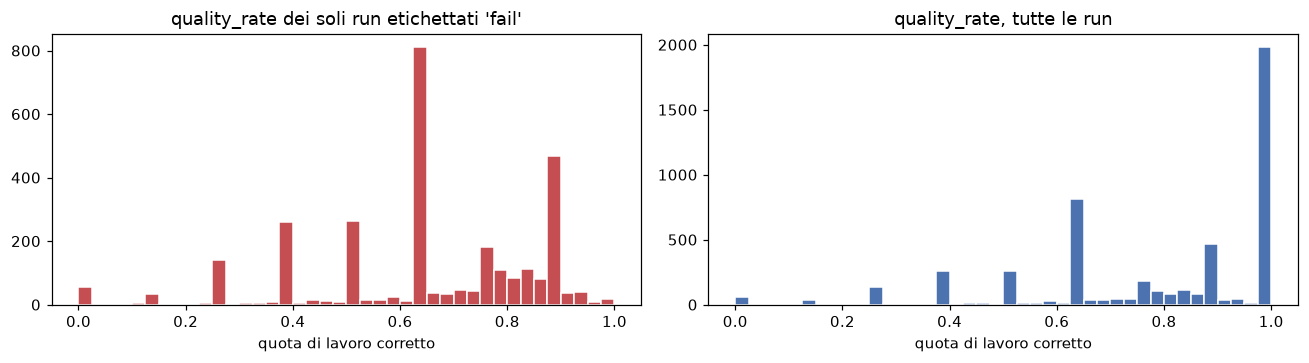

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(df.loc[df.quality == "fail", "quality_rate"].dropna(), bins=40,
             color="#C44E52", edgecolor="white")
axes[0].set_title("quality_rate dei soli run etichettati 'fail'")
axes[0].set_xlabel("quota di lavoro corretto")
axes[1].hist(df["quality_rate"].dropna(), bins=40, color="#4C72B0", edgecolor="white")
axes[1].set_title("quality_rate, tutte le run")
axes[1].set_xlabel("quota di lavoro corretto")
fig.tight_layout()

## 3. Studio 1 — `support-intake`

Una coda per run, 6-11 item. La misura e' nativamente il "quanti su quanti":
`quality_rate` = item corretti / item nella coda.

In [13]:
s1 = df[df.fixture == "support-intake"]
print(f"{len(s1)} run, {s1.input_id.nunique()} code, {s1.model.nunique()} modelli, "
      f"{s1.rendering.nunique()} rendering")
print()
print("--- Distribuzione di quality_rate ---")
print(s1["quality_rate"].describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_string())
print()
print("--- Esito binario (coda perfetta) ---")
q = s1.quality.value_counts()
print(pd.DataFrame({"n": q, "%": (100 * q / len(s1)).round(1)}).to_string())
print()
print(f"Quota media di item corretti per coda : {s1.quality_rate.mean():.3f}")
print(f"Code risolte alla perfezione          : {s1.ok.mean():.1%}")
print()
print("Le due letture della stessa campagna distano ~50 punti. Vanno riportate insieme:")
print("la prima dice quanto lavoro il modello fa bene, la seconda quante volte lo fa")
print("TUTTO bene. Citarne una sola e' mezza verita' in entrambe le direzioni.")

1236 run, 10 code, 6 modelli, 7 rendering

--- Distribuzione di quality_rate ---
count    1035.000
mean        0.732
std         0.206
min         0.000
5%          0.269
25%         0.693
50%         0.792
75%         0.860
95%         0.939
max         1.000

--- Esito binario (coda perfetta) ---
                  n     %
quality                  
fail           1023  82.8
not_checkable   194  15.7
pass             19   1.5

Quota media di item corretti per coda : 0.732
Code risolte alla perfezione          : 1.5%

Le due letture della stessa campagna distano ~50 punti. Vanno riportate insieme:
la prima dice quanto lavoro il modello fa bene, la seconda quante volte lo fa
TUTTO bene. Citarne una sola e' mezza verita' in entrambe le direzioni.


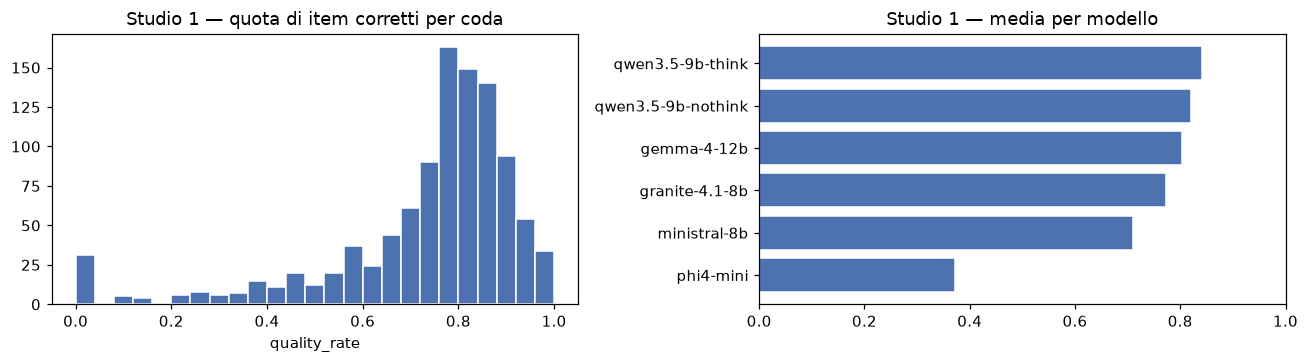

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
axes[0].hist(s1["quality_rate"].dropna(), bins=25, color="#4C72B0", edgecolor="white")
axes[0].set_title("Studio 1 — quota di item corretti per coda")
axes[0].set_xlabel("quality_rate")
tab = s1.groupby("model")["quality_rate"].mean().sort_values()
axes[1].barh(tab.index, tab.values, color="#4C72B0", edgecolor="white")
axes[1].set_title("Studio 1 — media per modello")
axes[1].set_xlim(0, 1)
fig.tight_layout()

In [15]:
# --- Studio 1: modello x rendering ---
piv1 = s1.pivot_table(index="model", columns="rendering", values="quality_rate", aggfunc="mean")
piv1["media"] = s1.groupby("model")["quality_rate"].mean()
print("Quota media di item corretti per coda:")
print(piv1.round(3).sort_values("media", ascending=False).to_string())
print()
print("Run per cella (denominatori):")
print(s1.pivot_table(index="model", columns="rendering", values="run_id",
                     aggfunc="size").to_string())

Quota media di item corretti per coda:
rendering              L0     L1     L2     L3     L4  prose-generated  prose-mechanical  media
model                                                                                          
qwen3.5-9b-think    0.808  0.932  0.836  0.856  0.762            0.888             0.857  0.842
qwen3.5-9b-nothink  0.825  0.822  0.840  0.813  0.807            0.789             0.853  0.820
gemma-4-12b         0.769  0.767  0.820  0.829  0.787            0.830             0.817  0.803
granite-4.1-8b      0.819  0.777  0.772  0.744  0.718            0.806             0.777  0.774
ministral-8b        0.727  0.650  0.655  0.684  0.726            0.807             0.719  0.710
phi4-mini           0.285  0.399  0.485  0.276  0.000            0.442             0.434  0.372

Run per cella (denominatori):
rendering           L0  L1  L2  L3  L4  prose-generated  prose-mechanical
model                                                                    
gemma-4-12b   

## 4. Studi 2 e 3 — `support-routing`

Un item per run, esito binario. Il "venti su trenta" **non e' dentro la run**: va
costruito aggregando i 20 item di ciascuna condizione.

Prima pero' un fatto che condiziona ogni lettura aggregata: quanto sono diversi fra loro
gli item.

In [16]:
s23 = df[df.fixture.isin(["support-routing", "support-routing-notrace"])].copy()
print(f"{len(s23)} run su {s23.input_id.nunique()} item (r01..r20), "
      f"{s23.model.nunique()} modelli, {s23.rendering.nunique()} rendering")
print()

# --- 4.1 Difficolta' dell'item ---
it = (s23.groupby("input_id")
          .agg(run=("ok", "size"), successi=("ok", "sum"), tasso=("ok", "mean"))
          .sort_values("tasso"))
lo, hi = proportion_confint(it["successi"], it["run"], method="wilson")
it["IC95 basso"], it["IC95 alto"] = lo.round(3), hi.round(3)
print("Tasso di successo per item, su tutti i modelli e tutti i rendering:")
print(it.round(3).to_string())

4195 run su 20 item (r01..r20), 9 modelli, 7 rendering

Tasso di successo per item, su tutti i modelli e tutti i rendering:
          run  successi  tasso  IC95 basso  IC95 alto
input_id                                             
r02       210         0  0.000       0.000      0.018
r19       210         0  0.000       0.000      0.018
r10       211         1  0.005       0.001      0.026
r15       210        32  0.152       0.110      0.207
r14       210        57  0.271       0.216      0.335
r12       210        75  0.357       0.295      0.424
r11       212        88  0.415       0.351      0.482
r13       202        93  0.460       0.393      0.529
r18       210        99  0.471       0.405      0.539
r16       210        99  0.471       0.405      0.539
r17       210       100  0.476       0.410      0.544
r05       210       106  0.505       0.438      0.572
r09       210       116  0.552       0.485      0.618
r04       210       118  0.562       0.494      0.627
r20       21

Item a pavimento (sotto il 5%): ['r02', 'r19', 'r10']
  r02: 0 successi su 210 run (0.0%), IC95 [0.000, 0.018]
  r19: 0 successi su 210 run (0.0%), IC95 [0.000, 0.018]
  r10: 1 successi su 211 run (0.5%), IC95 [0.001, 0.026]

Sono 3 item su 20, il 15% del denominatore.
Nessuna configurazione li risolve: non misurano il trattamento, misurano l'item.
Tolgono la stessa quota a tutte le condizioni. Vanno riportati a parte.

Dal 2026-09-02 l'insieme e' piu' informativo di prima: con l'ingresso dei tre
bracci hosted un item ne e' uscito (lo risolvono, quindi non era un pavimento ma
un limite dei modelli locali) e restano quelli che NESSUN modello risolve mai —
gli stessi che i tre bracci hosted sbagliano 14 volte su 14 (cfr. capitolo 6).
Un item che tre modelli di taglia diversa leggono allo stesso modo sbagliato e'
un disaccordo sulla verita' di riferimento, non una difficolta' di resa.


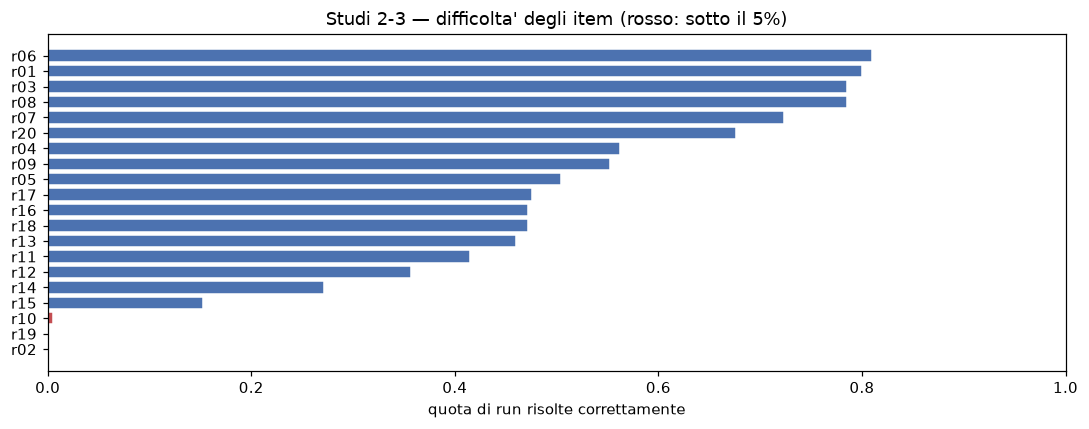

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
e = it.sort_values("tasso")
ax.barh(e.index, e["tasso"],
        color=["#C44E52" if t < 0.05 else "#4C72B0" for t in e["tasso"]],
        edgecolor="white")
ax.set_xlabel("quota di run risolte correttamente")
ax.set_title("Studi 2-3 — difficolta' degli item (rosso: sotto il 5%)")
ax.set_xlim(0, 1)
fig.tight_layout()

pav = it[it["tasso"] < 0.05]
print(f"Item a pavimento (sotto il 5%): {list(pav.index)}")
for i, r in pav.iterrows():
    print(f"  {i}: {int(r['successi'])} successi su {int(r['run'])} run "
          f"({r['tasso']:.1%}), IC95 [{r['IC95 basso']:.3f}, {r['IC95 alto']:.3f}]")
print()
print(f"Sono {len(pav)} item su {len(it)}, il {100*len(pav)/len(it):.0f}% del denominatore.")
print("Nessuna configurazione li risolve: non misurano il trattamento, misurano l'item.")
print("Tolgono la stessa quota a tutte le condizioni. Vanno riportati a parte.")
print()
print("Dal 2026-09-02 l'insieme e' piu' informativo di prima: con l'ingresso dei tre")
print("bracci hosted un item ne e' uscito (lo risolvono, quindi non era un pavimento ma")
print("un limite dei modelli locali) e restano quelli che NESSUN modello risolve mai —")
print("gli stessi che i tre bracci hosted sbagliano 14 volte su 14 (cfr. capitolo 6).")
print("Un item che tre modelli di taglia diversa leggono allo stesso modo sbagliato e'")
print("un disaccordo sulla verita' di riferimento, non una difficolta' di resa.")

### 4.2 Il punteggio "k su 20"

Per ogni condizione, quanti dei 20 item vengono risolti. Unita' = la condizione
(studio x modello x rendering), su un denominatore di 20 item **appaiati**: ogni
condizione vede gli stessi 20 item. Non sono gruppi indipendenti, sono lo stesso gruppo
sotto trattamenti diversi.

In [18]:
# --- Copertura: ogni condizione vede tutti e 20 gli item? ---
cov = s23.groupby(["studio", "model", "rendering"])["input_id"].nunique()
print("Item distinti per condizione (attesi 20):")
print(cov.value_counts().rename("condizioni").to_frame().to_string())
buchi = cov[cov < 20]
if len(buchi):
    print("\nCondizioni incomplete (il loro denominatore e' il proprio, non 20):")
    print(buchi.to_string())

Item distinti per condizione (attesi 20):
          condizioni
input_id            
20               101
19                 4

Condizioni incomplete (il loro denominatore e' il proprio, non 20):
studio       model           rendering
2 — routing  granite-4.1-8b  L3           19
                             L4           19
3 — notrace  granite-4.1-8b  L3           19
                             L4           19


In [19]:
# --- Quota di item risolti, per studio, modello e rendering ---
def tabella(studio):
    g = (s23[s23.studio == studio].groupby(["model", "rendering"])
         .agg(run=("ok", "size"), risolti=("ok", "sum")).reset_index())
    g["tasso"] = g["risolti"] / g["run"]
    lo_, hi_ = proportion_confint(g["risolti"], g["run"], method="wilson")
    g["lo"], g["hi"] = lo_, hi_
    return g

pivots = {}
for st in ["2 — routing", "3 — notrace"]:
    g = tabella(st)
    piv = g.pivot(index="model", columns="rendering", values="tasso")
    piv["media"] = s23[s23.studio == st].groupby("model")["ok"].mean()
    piv = piv.sort_values("media", ascending=False)
    pivots[st] = piv
    print(f"=== Studio {st}: quota di item risolti ===")
    print(piv.round(3).to_string())
    print()

=== Studio 2 — routing: quota di item risolti ===
rendering              L0     L1     L2     L3     L4  prose-generated  prose-mechanical  media
model                                                                                          
ministral-8b        0.625  0.625  0.700  0.650  0.550            0.550             0.575  0.611
qwen3.5-9b-think    0.575  0.550  0.475  0.600  0.575            0.575             0.550  0.557
granite-4.1-8b      0.425  0.550  0.475  0.263  0.158            0.425             0.450  0.395
gemma-4-12b         0.375  0.400  0.300  0.300  0.300            0.425             0.300  0.343
qwen3.5-9b-nothink  0.150  0.200  0.100  0.075  0.125            0.300             0.050  0.143
phi4-mini           0.000  0.025  0.125  0.000  0.050            0.250             0.175  0.089

=== Studio 3 — notrace: quota di item risolti ===
rendering              L0     L1     L2     L3     L4  prose-generated  prose-mechanical  media
model                              

In [20]:
# --- Lo stesso, tolti gli item a pavimento ---
# Fatto, non correzione: mostra quanta parte della media e' occupata da item che nessuna
# configurazione risolve. Entrambe le letture vanno riportate, con la loro N.
vivi = s23[~s23.input_id.isin(pav.index)]
n_vivi = vivi.input_id.nunique()
print(f"Item non a pavimento: {n_vivi} su {s23.input_id.nunique()}")
print()
confronto = {}
for st in ["2 — routing", "3 — notrace"]:
    a_ = s23[s23.studio == st].groupby("model")["ok"].mean()
    b_ = vivi[vivi.studio == st].groupby("model")["ok"].mean()
    t_ = pd.DataFrame({"su 20 item": a_.round(3), f"su {n_vivi} item": b_.round(3)})
    t_["scarto"] = (t_.iloc[:, 1] - t_.iloc[:, 0]).round(3)
    confronto[st] = t_.sort_values(t_.columns[1], ascending=False)
    print(f"=== Studio {st} ===")
    print(confronto[st].to_string())
    print()

Item non a pavimento: 17 su 20

=== Studio 2 — routing ===
                    su 20 item  su 17 item  scarto
model                                             
ministral-8b             0.611       0.718   0.107
qwen3.5-9b-think         0.557       0.655   0.098
granite-4.1-8b           0.395       0.466   0.071
gemma-4-12b              0.343       0.403   0.060
qwen3.5-9b-nothink       0.143       0.168   0.025
phi4-mini                0.089       0.105   0.016

=== Studio 3 — notrace ===
                    su 20 item  su 17 item  scarto
model                                             
claude-code-sonnet       0.846       0.996   0.150
claude-code-opus         0.836       0.983   0.147
claude-code-haiku        0.789       0.929   0.140
qwen3.5-9b-think         0.633       0.746   0.113
ministral-8b             0.557       0.655   0.098
gemma-4-12b              0.446       0.525   0.079
granite-4.1-8b           0.380       0.449   0.069
qwen3.5-9b-nothink       0.264       0.307   0

## 5. Studio 2 -> studio 3: cosa cambia togliendo il tracing

Confronto **descrittivo**. Gli stessi 20 item, gli stessi sei modelli locali, gli stessi
sette rendering; l'unica differenza dichiarata e' il tracing tolto dai comandi.
I tre bracci hosted non ci sono nello studio 2, quindi restano fuori.

Qui non si testa niente: si mette il numero accanto al numero.

In [21]:
loc = s23[~s23.model.isin(HOSTED)]
agg = loc.groupby("studio").agg(run=("ok", "size"), risolti=("ok", "sum"))
agg["tasso"] = (agg["risolti"] / agg["run"]).round(3)
lo, hi = proportion_confint(agg["risolti"], agg["run"], method="wilson")
agg["IC95 basso"], agg["IC95 alto"] = lo.round(3), hi.round(3)
print("Complessivo, soli modelli locali:")
print(agg.to_string())
print()

tr_m = loc.pivot_table(index="model", columns="studio", values="ok", aggfunc="mean").round(3)
tr_m["scarto"] = (tr_m["3 — notrace"] - tr_m["2 — routing"]).round(3)
tr_m = tr_m.sort_values("scarto", ascending=False)
print("Per modello:")
print(tr_m.to_string())
print()
tr_r = loc.pivot_table(index="rendering", columns="studio", values="ok", aggfunc="mean").round(3)
tr_r["scarto"] = (tr_r["3 — notrace"] - tr_r["2 — routing"]).round(3)
tr_r = tr_r.sort_values("scarto", ascending=False)
print("Per rendering:")
print(tr_r.to_string())
print()
su = int((tr_m["scarto"] > 0).sum()); giu = int((tr_m["scarto"] < 0).sum())
print(f"{su} modelli salgono, {giu} scendono. Il complessivo e' la somma di due gruppi")
print("che vanno in direzioni opposte, non un effetto che tutti condividono.")

Complessivo, soli modelli locali:
              run  risolti  tasso  IC95 basso  IC95 alto
studio                                                  
2 — routing  1676      597  0.356       0.334      0.379
3 — notrace  1679      657  0.391       0.368      0.415

Per modello:
studio              2 — routing  3 — notrace  scarto
model                                               
qwen3.5-9b-nothink        0.143        0.264   0.121
gemma-4-12b               0.343        0.446   0.103
qwen3.5-9b-think          0.557        0.633   0.076
granite-4.1-8b            0.395        0.380  -0.015
phi4-mini                 0.089        0.064  -0.025
ministral-8b              0.611        0.557  -0.054

Per rendering:
studio            2 — routing  3 — notrace  scarto
rendering                                         
prose-mechanical        0.350        0.442   0.092
prose-generated         0.421        0.512   0.091
L3                      0.315        0.353   0.038
L4                      0.294

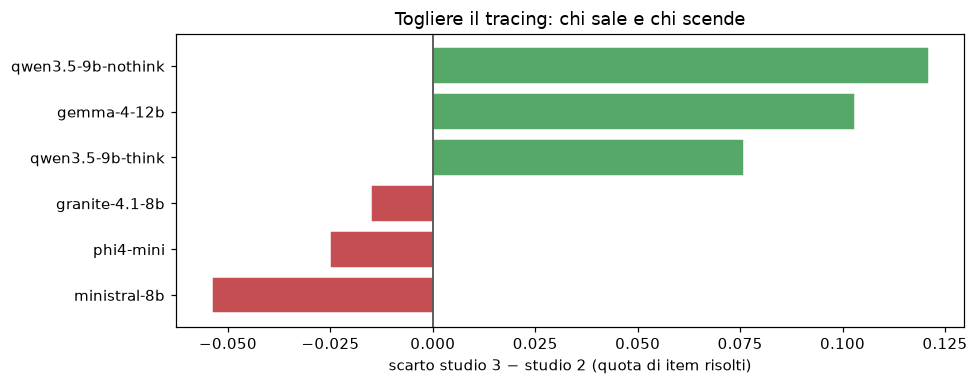

In [22]:
fig, ax = plt.subplots(figsize=(9, 3.6))
o = tr_m.sort_values("scarto")
ax.barh(o.index, o["scarto"],
        color=["#C44E52" if v < 0 else "#55A868" for v in o["scarto"]], edgecolor="white")
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("scarto studio 3 − studio 2 (quota di item risolti)")
ax.set_title("Togliere il tracing: chi sale e chi scende")
fig.tight_layout()

## 6. Studio 3 — la scala hosted: haiku, sonnet, opus

Tre bracci, 280 run ciascuno, sugli stessi venti item e sugli stessi sette rendering.
Solo descrittivo: prima la scala, poi il profilo di ciascuno sui formati, poi dove
stanno i fallimenti.

In [23]:
g3 = tabella("3 — notrace")
s3 = s23[s23.studio == "3 — notrace"]
h3all = s3[s3.model.isin(HOSTED)]

scala = h3all.groupby("model").agg(run=("ok", "size"), risolti=("ok", "sum"))
scala["tasso"] = scala["risolti"] / scala["run"]
lo_, hi_ = proportion_confint(scala["risolti"], scala["run"], method="wilson")
scala["IC95 basso"], scala["IC95 alto"] = lo_, hi_
scala["quality_rate medio"] = h3all.groupby("model")["quality_rate"].mean()
scala = scala.reindex(HOSTED)
print("Studio 3 — i tre bracci hosted:")
print(scala.round(3).to_string())
print()

locali3 = s3[~s3.model.isin(HOSTED)]
print(f"Sei celle locali, pooled: {locali3.ok.mean():.3f} "
      f"(quality_rate medio {locali3.quality_rate.mean():.3f}) su {len(locali3)} run.")
print()
d_hs = scala.loc["claude-code-sonnet", "tasso"] - scala.loc["claude-code-haiku", "tasso"]
d_so = scala.loc["claude-code-opus", "tasso"] - scala.loc["claude-code-sonnet", "tasso"]
n_so = abs(d_so) * scala.loc["claude-code-opus", "run"]
print(f"haiku -> sonnet : {d_hs:+.3f}")
print(f"sonnet -> opus  : {d_so:+.3f}  ({n_so:.0f} run su "
      f"{int(scala.loc['claude-code-opus', 'run'])})")
print()
print("La scala si appiattisce al piolo di mezzo: il salto sta fra i locali e il primo")
print("modello hosted, non lungo la scala hosted. Il terzo piolo non compra niente, e la")
print("differenza fra il secondo e il terzo e' dell'ordine di poche run.")

Studio 3 — i tre bracci hosted:
                    run  risolti  tasso  IC95 basso  IC95 alto  quality_rate medio
model                                                                             
claude-code-haiku   280      221  0.789       0.738      0.833               0.908
claude-code-sonnet  280      237  0.846       0.800      0.884               0.942
claude-code-opus    280      234  0.836       0.788      0.875               0.931

Sei celle locali, pooled: 0.391 (quality_rate medio 0.757) su 1679 run.

haiku -> sonnet : +0.057
sonnet -> opus  : -0.011  (3 run su 280)

La scala si appiattisce al piolo di mezzo: il salto sta fra i locali e il primo
modello hosted, non lungo la scala hosted. Il terzo piolo non compra niente, e la
differenza fra il secondo e il terzo e' dell'ordine di poche run.


In [24]:
# Il profilo sui sette rendering, un braccio alla volta.
hosted_prof = {}
for m in HOSTED:
    p = (g3[g3.model == m].set_index("rendering")
         .sort_values("tasso", ascending=False))
    hosted_prof[m] = p
    esc_m = p["tasso"].max() - p["tasso"].min()
    amp_m = (p["hi"] - p["lo"]).mean()
    print(f"=== {m} — quota di item risolti per rendering ===")
    print(p[["run", "risolti", "tasso", "lo", "hi"]].round(3).to_string())
    print(f"escursione migliore-peggiore: {esc_m:.3f}   "
          f"ampiezza media dell'IC 95%: {amp_m:.3f}")
    print()

h = hosted_prof["claude-code-haiku"]
esc_h = h["tasso"].max() - h["tasso"].min()
amp_h = (h["hi"] - h["lo"]).mean()

escursioni = pd.DataFrame({
    "escursione": {m: hosted_prof[m]["tasso"].max() - hosted_prof[m]["tasso"].min()
                   for m in HOSTED},
    "ampiezza IC medio": {m: (hosted_prof[m]["hi"] - hosted_prof[m]["lo"]).mean()
                          for m in HOSTED},
})
print("Su tutti e tre i bracci l'escursione fra formati e' piu' stretta dell'incertezza")
print("su una singola condizione:")
print(escursioni.round(3).to_string())
print()
print("E' COERENTE con l'ipotesi che sopra la frontiera i formati non facciano")
print("differenza. Non la dimostra: cfr. capitolo 7 e il test di equivalenza in 8.3.")
print()
print("Una riga va guardata da vicino invece che mediata: l'escursione di opus e' tutta")
print("nella cella prose-mechanical, e quella cella e' fatta delle quattro run che hanno")
print("risposto INVALID_INPUT invece di eseguire (cella successiva). Non e' una resa piu'")
print("bassa su quel formato: e' un rifiuto di eseguire su quel formato.")

=== claude-code-haiku — quota di item risolti per rendering ===
                  run  risolti  tasso     lo     hi
rendering                                          
prose-generated    40       33  0.825  0.681  0.913
L2                 40       32  0.800  0.652  0.895
L0                 40       32  0.800  0.652  0.895
L4                 40       32  0.800  0.652  0.895
L1                 40       31  0.775  0.625  0.877
L3                 40       31  0.775  0.625  0.877
prose-mechanical   40       30  0.750  0.598  0.858
escursione migliore-peggiore: 0.075   ampiezza media dell'IC 95%: 0.246

=== claude-code-sonnet — quota di item risolti per rendering ===
                  run  risolti  tasso     lo     hi
rendering                                          
L0                 40       34  0.850  0.709  0.929
L2                 40       34  0.850  0.709  0.929
L3                 40       34  0.850  0.709  0.929
prose-generated    40       34  0.850  0.709  0.929
L4                

In [25]:
# Dove stanno i fallimenti: gli stessi item, o item diversi per modello?
falliti = (h3all.assign(ko=1 - h3all.ok)
           .pivot_table(index="input_id", columns="model", values="ko", aggfunc="sum")
           .reindex(columns=HOSTED).fillna(0).astype(int))
falliti = falliti[falliti.sum(axis=1) > 0]
falliti["run per item"] = h3all.groupby("input_id").size().reindex(falliti.index)
print("Fallimenti per item (su 14 run per item e per modello):\n")
print(falliti.sort_values(HOSTED, ascending=False).to_string())
print()
sempre = [i for i in falliti.index if (falliti.loc[i, HOSTED] == 14).all()]
quota_sempre = falliti.loc[sempre, HOSTED].sum() / falliti[HOSTED].sum()
print(f"Item sbagliati da TUTTI e tre i bracci in TUTTE e 14 le run: {sempre}")
print("Quota dei fallimenti di ciascun braccio che quegli item da soli spiegano:")
print(quota_sempre.round(3).to_string())
print()
print("Non e' rumore stocastico e non lo tocca nessun contesto collaterale: e' lo stesso")
print("disaccordo, ripetuto identico da modelli che distano un fattore trenta di taglia.")

Fallimenti per item (su 14 run per item e per modello):

model     claude-code-haiku  claude-code-sonnet  claude-code-opus  run per item
input_id                                                                       
r02                      14                  14                14            42
r10                      14                  14                14            42
r19                      14                  14                14            42
r15                       9                   1                 1            42
r11                       5                   0                 1            42
r09                       1                   0                 0            42
r14                       1                   0                 0            42
r16                       1                   0                 0            42
r05                       0                   0                 1            42
r07                       0                   0                

In [26]:
# Cosa hanno dichiarato di aver fatto: lo `status` dell'oggetto restituito.
ps = (h3all.groupby(["model", "payload_status"]).size()
      .unstack(fill_value=0).reindex(HOSTED))
print("`status` del payload restituito, per braccio:\n")
print(ps.to_string())
print()
anom = h3all[h3all.payload_status.notna() & (h3all.payload_status != "OK")]
if len(anom):
    print(f"Run che NON hanno dichiarato OK: {len(anom)} su {len(h3all)}")
    print(anom.groupby(["model", "rendering", "payload_status"]).size().to_string())
    print()
    print("Sono l'unico caso in cui un braccio hosted non ha eseguito il processo: ha")
    print("dichiarato l'input invalido. L'oracolo le conta come sbagliate — per il suo")
    print("metro lo sono — ma il guasto non e' dello stesso tipo degli altri, e per")
    print("questo sta in una riga sua invece che dentro il tasso.")

`status` del payload restituito, per braccio:

payload_status      INVALID_INPUT   OK
model                                 
claude-code-haiku               0  280
claude-code-sonnet              0  280
claude-code-opus                4  276

Run che NON hanno dichiarato OK: 4 su 840
model             rendering         payload_status
claude-code-opus  prose-mechanical  INVALID_INPUT     4

Sono l'unico caso in cui un braccio hosted non ha eseguito il processo: ha
dichiarato l'input invalido. L'oracolo le conta come sbagliate — per il suo
metro lo sono — ma il guasto non e' dello stesso tipo degli altri, e per
questo sta in una riga sua invece che dentro il tasso.


                      min    max   mean  escursione  sd attesa
model                                                         
claude-code-sonnet  0.825  0.850  0.846       0.025      0.057
claude-code-opus    0.750  0.850  0.836       0.100      0.059
claude-code-haiku   0.750  0.825  0.789       0.075      0.064
qwen3.5-9b-think    0.550  0.750  0.633       0.200      0.076
ministral-8b        0.450  0.650  0.557       0.200      0.079
gemma-4-12b         0.300  0.750  0.446       0.450      0.079
granite-4.1-8b      0.211  0.500  0.378       0.289      0.077
qwen3.5-9b-nothink  0.200  0.325  0.264       0.125      0.070
phi4-mini           0.000  0.225  0.064       0.225      0.039



La colonna 'sd attesa' e' l'errore standard di una proporzione a quel livello, su
n=40: con un esito binario la variabilita' e' massima intorno a 0.5 e si
schiaccia ai bordi. Haiku (in alto) e phi4-mini (in basso) stanno entrambi vicino
a un bordo: parte della loro escursione stretta e' il soffitto o il pavimento,
non l'indifferenza al formato. Le escursioni grezze NON sono confrontabili fra
modelli a livelli diversi.


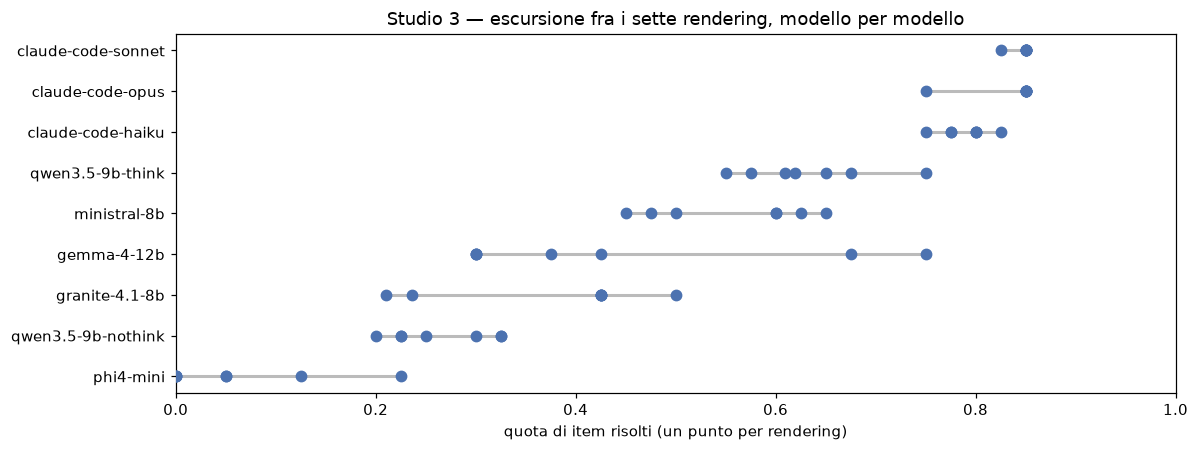

In [27]:
# Escursione fra rendering, modello per modello
fig, ax = plt.subplots(figsize=(11, 4.2))
ordine = g3.groupby("model")["tasso"].mean().sort_values().index
for i, m in enumerate(ordine):
    sub = g3[g3.model == m]
    ax.hlines(i, sub["tasso"].min(), sub["tasso"].max(), color="#BBB", lw=2, zorder=2)
    ax.scatter(sub["tasso"], [i] * len(sub), s=45, color="#4C72B0", zorder=3)
ax.set_yticks(range(len(ordine)))
ax.set_yticklabels(ordine)
ax.set_xlabel("quota di item risolti (un punto per rendering)")
ax.set_title("Studio 3 — escursione fra i sette rendering, modello per modello")
ax.set_xlim(0, 1)
fig.tight_layout()

esc = g3.groupby("model")["tasso"].agg(["min", "max", "mean"])
esc["escursione"] = (esc["max"] - esc["min"]).round(3)
# Varianza attesa di una proporzione su n item: massima a 0.5, schiacciata ai bordi.
n_it = int(g3["run"].median())
esc["sd attesa"] = np.sqrt(esc["mean"] * (1 - esc["mean"]) / n_it).round(3)
esc = esc.sort_values("mean", ascending=False)
print(esc.round(3).to_string())
print()
print("La colonna 'sd attesa' e' l'errore standard di una proporzione a quel livello, su")
print(f"n={n_it}: con un esito binario la variabilita' e' massima intorno a 0.5 e si")
print("schiaccia ai bordi. Haiku (in alto) e phi4-mini (in basso) stanno entrambi vicino")
print("a un bordo: parte della loro escursione stretta e' il soffitto o il pavimento,")
print("non l'indifferenza al formato. Le escursioni grezze NON sono confrontabili fra")
print("modelli a livelli diversi.")

## 7. Cosa resta da testare, e perche' non basta un p-value

Tre avvertenze metodologiche, da tenere ferme quando si passera' ai test.

**7.1 Le run non sono osservazioni indipendenti.** Ci sono tre annidamenti: le repliche
(2-3 esecuzioni dello stesso identico prompt a `temperature=0.2`), gli input ripetuti
(ogni item passa sotto decine di condizioni), e gli studi (tre compiti in tutto). Un test
che assume indipendenza gonfia la statistica e restituisce p minuscoli su qualunque cosa —
comprese differenze che sono rumore fra item. Non produce mai un risultato assurdo:
produce *tutto significativo*.

**7.2 Ma il disegno e' appaiato, ed e' un vantaggio.** Negli studi 2-3 ogni condizione vede
gli stessi 20 item. La difficolta' dell'item — che e' la fonte principale di dipendenza —
si puo' **annullare** invece di subirla, usando test appaiati (McNemar fra due condizioni,
Cochran's Q fra piu' di due) o un modello con l'item come effetto casuale. Sono piu'
potenti *e* piu' corretti dei test non appaiati.

**7.3 "Nessuna differenza" non si dimostra con un p alto.** L'ipotesi su Haiku e' un'ipotesi
**nulla**: che i formati non facciano differenza. Un test di significativita' che non
rifiuta non e' prova di assenza — puo' solo voler dire che i dati sono pochi. Per
sostenere quell'ipotesi serve un test di **equivalenza** (TOST): si dichiara prima quale
scarto e' abbastanza piccolo da non contare, e si verifica che l'intervallo di confidenza
ci stia dentro. Senza quella soglia dichiarata in anticipo, la domanda non e' ancora
ben posta.

In [28]:
# Quanto conta l'annidamento: quota di varianza attribuibile all'item, per studio.
for st, g in df.dropna(subset=["quality_rate"]).groupby("studio"):
    gm = g.groupby("input_id")["quality_rate"]
    var_tra, var_entro = gm.mean().var(), gm.var().mean()
    icc = var_tra / (var_tra + var_entro)
    n_medio = g.groupby("input_id").size().mean()
    deff = 1 + (n_medio - 1) * icc
    print(f"{st:14s}  ICC={icc:.3f}  run per input={n_medio:5.0f}  "
          f"deff={deff:5.1f}  N={len(g):5d} -> N efficace ~{len(g)/deff:.0f}")
print()
print("Letto cosi', l'annidamento e' devastante. Ma e' la misura del disegno NON appaiato:")
print("con test appaiati sull'item (7.2) quella varianza esce dal denominatore invece di")
print("gonfiarlo. E' il motivo per cui i test vanno impostati sull'appaiamento.")

1 — intake      ICC=0.036  run per input=  104  deff=  4.7  N= 1035 -> N efficace ~222
2 — routing     ICC=0.255  run per input=   74  deff= 19.7  N= 1489 -> N efficace ~75
3 — notrace     ICC=0.289  run per input=  122  deff= 36.0  N= 2442 -> N efficace ~68

Letto cosi', l'annidamento e' devastante. Ma e' la misura del disegno NON appaiato:
con test appaiati sull'item (7.2) quella varianza esce dal denominatore invece di
gonfiarlo. E' il motivo per cui i test vanno impostati sull'appaiamento.


## 8. I test

Impostazione dichiarata **prima** dei risultati.

**Unita' e appaiamento.** Negli studi 2-3 ogni condizione vede gli stessi 20 item. Tutti i
test qui sotto sono **appaiati sull'item**: la difficolta' dell'item — la fonte principale
di dipendenza fra le run — esce dal confronto invece di gonfiarlo. Il valore di ogni cella
e' la quota di successo dell'item in quella condizione, mediata sulle 2-3 repliche.

**Soglia di significativita'**: alpha = 0.05.

**Soglia di equivalenza (TOST)**: **0.10**, cioe' dieci punti percentuali di quota di item
risolti. Fissata a priori su un criterio pratico: sotto i dieci punti la scelta del formato
non cambierebbe una decisione in un caso d'uso reale. La soglia e' dichiarata qui e non
viene toccata dopo aver visto i numeri.

**Tre domande, tre strumenti.**

| domanda | test | perche' quello |
|---|---|---|
| togliere il tracing sposta l'esito? | Wilcoxon dei ranghi con segno, appaiato | due condizioni sugli stessi item, valori non binari (media di repliche), nessuna assunzione di normalita' |
| il rendering sposta l'esito, a modello fissato? | Friedman + Kendall's W | sette condizioni sugli stessi item; W dice quanto, non solo se |
| Haiku e' indifferente ai formati? | TOST appaiato su tutte le 21 coppie | e' un'ipotesi **nulla**: un p alto non la sostiene, serve l'equivalenza |

Sul terzo: dichiarare equivalenza solo se **tutte** le 21 coppie risultano equivalenti e'
un test a intersezione-unione, conservativo per costruzione. Non serve correzione per
confronti multipli: basta una coppia fuori soglia perche' la conclusione cada.

In [29]:
import scipy.stats as ss
from statsmodels.stats.weightstats import ttost_paired
from itertools import combinations

ALPHA = 0.05
MARGINE = 0.10   # soglia di equivalenza, fissata a priori (cfr. testo sopra)

def matrice(dati, modello, studio=None):
    """Item x rendering, valore = quota di successo dell'item in quella condizione."""
    d = dati[dati.model == modello]
    if studio is not None:
        d = d[d.studio == studio]
    return d.pivot_table(index="input_id", columns="rendering", values="ok", aggfunc="mean")

print(f"alpha = {ALPHA}   margine di equivalenza = {MARGINE}")
print(f"Item disponibili per l'appaiamento: {s23.input_id.nunique()} "
      f"({len(pav)} dei quali a pavimento)")

alpha = 0.05   margine di equivalenza = 0.1
Item disponibili per l'appaiamento: 20 (3 dei quali a pavimento)


### 8.1 Togliere il tracing sposta l'esito?

Confronto appaiato studio 2 vs studio 3, su `rendering x item` (140 coppie per modello).
I tre bracci hosted non ci sono nello studio 2 e restano fuori.

Gli item a pavimento danno differenza zero in ogni coppia: Wilcoxon scarta i pari, quindi
l'N efficace e' minore di 140 e va riportato.

In [30]:
righe = []
for m in sorted(loc.model.unique()):
    # dropna: granite non ha tutti i 20 item su L3/L4, e una coppia incompleta
    # non e' appaiabile. Il denominatore di quel modello e' il suo, non 140.
    a2 = matrice(loc, m, "2 — routing").stack().dropna()
    a3 = matrice(loc, m, "3 — notrace").stack().dropna()
    comuni = a2.index.intersection(a3.index)
    x2, x3 = a2.loc[comuni].to_numpy(), a3.loc[comuni].to_numpy()
    diff = x3 - x2
    non_pari = int((diff != 0).sum())
    stat, p = ss.wilcoxon(x3, x2, zero_method="wilcox")
    # IC 95% della differenza media, appaiata
    sd = diff.std(ddof=1) / np.sqrt(len(diff))
    righe.append({"modello": m, "coppie": len(diff), "non pari": non_pari,
                  "studio 2": x2.mean(), "studio 3": x3.mean(),
                  "differenza": diff.mean(),
                  "IC95 basso": diff.mean() - 1.96 * sd,
                  "IC95 alto": diff.mean() + 1.96 * sd,
                  "W": stat, "p": p})
trac = pd.DataFrame(righe).sort_values("differenza", ascending=False)
trac["esito"] = np.where(trac.p < ALPHA,
                         np.where(trac.differenza > 0, "sale", "scende"), "non concluso")
print("Effetto di togliere il tracing, appaiato su rendering x item:\n")
print(trac.round(4).to_string(index=False))
print()
n_sale = int((trac.esito == "sale").sum())
n_scende = int((trac.esito == "scende").sum())
n_nulla = int((trac.esito == "non concluso").sum())
n_giu_desc = int((trac.differenza < 0).sum())
print(f"{n_sale} modelli salgono in modo significativo, {n_scende} scendono, "
      f"{n_nulla} senza conclusione ({n_giu_desc} dei quali descrittivamente in calo).")
print("Attenzione a come si racconta: i test NON dimostrano un effetto in due direzioni")
print("opposte. Dimostrano un effetto positivo su una parte dei modelli, e nessun effetto")
print("dimostrato sugli altri. Un calo descrittivo che il test non conferma non e' un calo.")

Effetto di togliere il tracing, appaiato su rendering x item:

           modello  coppie  non pari  studio 2  studio 3  differenza  IC95 basso  IC95 alto     W      p        esito
qwen3.5-9b-nothink     140        29    0.1429    0.2643      0.1214      0.0699     0.1729  33.5 0.0000         sale
       gemma-4-12b     140        22    0.3429    0.4464      0.1036      0.0461     0.1611  23.0 0.0004         sale
  qwen3.5-9b-think     140        61    0.5571    0.6345      0.0774      0.0157     0.1391 630.0 0.0134         sale
    granite-4.1-8b     138        40    0.3949    0.3804     -0.0145     -0.0687     0.0397 370.0 0.5601 non concluso
         phi4-mini     140        18    0.0893    0.0643     -0.0250     -0.0569     0.0069  54.0 0.1266 non concluso
      ministral-8b     140        44    0.6107    0.5571     -0.0536     -0.1170     0.0098 372.0 0.1323 non concluso

3 modelli salgono in modo significativo, 0 scendono, 3 senza conclusione (3 dei quali descrittivamente in calo

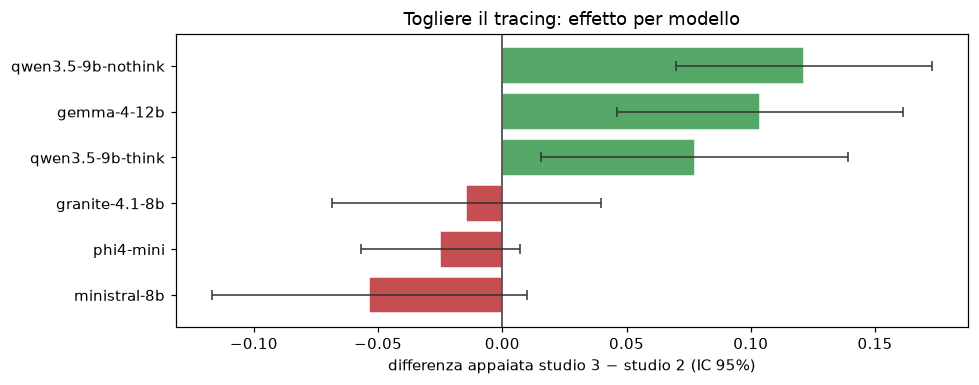

In [31]:
fig, ax = plt.subplots(figsize=(9, 3.6))
o = trac.sort_values("differenza").set_index("modello")
colori = ["#C44E52" if v < 0 else "#55A868" for v in o["differenza"]]
ax.barh(o.index, o["differenza"], color=colori, edgecolor="white")
ax.errorbar(o["differenza"], range(len(o)),
            xerr=[o["differenza"] - o["IC95 basso"], o["IC95 alto"] - o["differenza"]],
            fmt="none", ecolor="#333", capsize=3, lw=1)
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("differenza appaiata studio 3 − studio 2 (IC 95%)")
ax.set_title("Togliere il tracing: effetto per modello")
fig.tight_layout()

### 8.2 Il rendering sposta l'esito, a modello fissato?

Friedman sui 20 item x 7 rendering, dentro lo studio 3. Kendall's W e' l'ampiezza
dell'effetto: 0 = nessuna concordanza fra item su quale rendering sia migliore,
1 = tutti gli item ordinano i rendering allo stesso modo.

In [32]:
s3m = df[df.fixture == "support-routing-notrace"]
righe = []
for m in sorted(s3m.model.unique()):
    M = matrice(s3m, m).dropna()
    k = M.shape[1]
    chi2, p = ss.friedmanchisquare(*[M[c].to_numpy() for c in M.columns])
    W = chi2 / (len(M) * (k - 1))
    per_r = M.mean()
    righe.append({"modello": m, "item": len(M), "rendering": k,
                  "chi2": chi2, "p": p, "Kendall W": W,
                  "migliore": per_r.idxmax(), "peggiore": per_r.idxmin(),
                  "escursione": per_r.max() - per_r.min()})
fried = pd.DataFrame(righe).sort_values("p")
fried["esito"] = np.where(fried.p < ALPHA, "il rendering conta", "non concluso")
print("Friedman sul rendering, dentro ciascun modello (studio 3, appaiato sull'item):\n")
print(fried.round(4).to_string(index=False))
print()
print(f"Il rendering risulta significativo su {int((fried.p < ALPHA).sum())} modelli "
      f"su {len(fried)}.")

Friedman sul rendering, dentro ciascun modello (studio 3, appaiato sull'item):

           modello  item  rendering    chi2      p  Kendall W        migliore         peggiore  escursione              esito
       gemma-4-12b    20          7 42.1607 0.0000     0.3513 prose-generated               L2      0.4500 il rendering conta
  claude-code-opus    20          7 24.0000 0.0005     0.2000              L0 prose-mechanical      0.1000 il rendering conta
         phi4-mini    20          7 20.1519 0.0026     0.1679 prose-generated               L0      0.2250 il rendering conta
    granite-4.1-8b    19          7 18.3158 0.0055     0.1607              L1               L4      0.2895 il rendering conta
      ministral-8b    20          7 11.5640 0.0724     0.0964              L2 prose-mechanical      0.2000       non concluso
  qwen3.5-9b-think    20          7  8.1396 0.2281     0.0678 prose-generated               L1      0.2000       non concluso
qwen3.5-9b-nothink    20          7  6

### 8.3 I bracci hosted sono indifferenti ai formati? — test di equivalenza

TOST appaiato su tutte le 21 coppie di rendering, margine **0.10** dichiarato a priori.
Equivalenza complessiva solo se ogni coppia risulta equivalente.

Doppia lettura, per onesta': gli item a pavimento danno differenza zero in ogni coppia e
quindi **restringono la varianza, rendendo l'equivalenza piu' facile da dichiarare**. Il
test gira sia su tutti e 20 gli item sia sui soli non a pavimento; se le due letture
divergono, vale la seconda.

In [33]:
def tost_modello(dati, modello, item_esclusi=()):
    M = matrice(dati, modello).dropna()
    M = M.drop(index=[i for i in item_esclusi if i in M.index])
    out = []
    for a, b in combinations(M.columns, 2):
        p, _, _ = ttost_paired(M[a].to_numpy(), M[b].to_numpy(), -MARGINE, MARGINE)
        d = (M[a] - M[b]).mean()
        out.append({"coppia": f"{a} vs {b}", "differenza": d, "p TOST": p,
                    "equivalenti": p < ALPHA})
    return pd.DataFrame(out), len(M)

hosted_tost = {}
for mod in HOSTED:
    for etichetta, esclusi in [("tutti i 20 item", ()),
                               (f"i {n_vivi} item non a pavimento", tuple(pav.index))]:
        t, n_it_ = tost_modello(s3m, mod, esclusi)
        ok_ = int(t.equivalenti.sum())
        print(f"=== {mod} — {etichetta} (n={n_it_}) ===")
        print(f"Coppie equivalenti entro ±{MARGINE}: {ok_} su {len(t)}")
        print(f"Differenza assoluta massima osservata: {t.differenza.abs().max():.3f}")
        peggio = t.loc[t["p TOST"].idxmax()]
        print(f"Coppia piu' lontana dall'equivalenza: {peggio['coppia']} "
              f"(differenza {peggio['differenza']:+.3f}, p TOST = {peggio['p TOST']:.4f})")
        verdetto = ("EQUIVALENZA DICHIARATA" if ok_ == len(t)
                    else "NON CONCLUSO — almeno una coppia fuori soglia")
        print(f"Verdetto: {verdetto}")
        print()
        if esclusi:
            hosted_tost[mod] = {"tost": t, "ok": ok_, "n": n_it_, "coppie": len(t),
                                "verdetto": verdetto, "peggio": peggio}

# Il foglio dei fatti cita per esteso il braccio piu' vecchio, che e' quello su cui
# l'ipotesi era stata formulata; gli altri due la mettono alla prova.
_hk = hosted_tost["claude-code-haiku"]
haiku_tost, haiku_ok, haiku_n, haiku_tot = _hk["tost"], _hk["ok"], _hk["n"], _hk["coppie"]
haiku_verdetto, haiku_peggio = _hk["verdetto"], _hk["peggio"]
n_eq_hosted = sum(1 for m in HOSTED if hosted_tost[m]["ok"] == hosted_tost[m]["coppie"])
print(f"Bracci hosted con equivalenza dichiarata su tutte le coppie: "
      f"{n_eq_hosted} su {len(HOSTED)}.")

=== claude-code-haiku — tutti i 20 item (n=20) ===
Coppie equivalenti entro ±0.1: 9 su 21
Differenza assoluta massima osservata: 0.075
Coppia piu' lontana dall'equivalenza: prose-generated vs prose-mechanical (differenza +0.075, p TOST = 0.2744)
Verdetto: NON CONCLUSO — almeno una coppia fuori soglia

=== claude-code-haiku — i 17 item non a pavimento (n=17) ===
Coppie equivalenti entro ±0.1: 9 su 21
Differenza assoluta massima osservata: 0.088
Coppia piu' lontana dall'equivalenza: prose-generated vs prose-mechanical (differenza +0.088, p TOST = 0.4041)
Verdetto: NON CONCLUSO — almeno una coppia fuori soglia

=== claude-code-sonnet — tutti i 20 item (n=20) ===
Coppie equivalenti entro ±0.1: 21 su 21
Differenza assoluta massima osservata: 0.025
Coppia piu' lontana dall'equivalenza: L0 vs L1 (differenza +0.025, p TOST = 0.0037)
Verdetto: EQUIVALENZA DICHIARATA

=== claude-code-sonnet — i 17 item non a pavimento (n=17) ===
Coppie equivalenti entro ±0.1: 21 su 21
Differenza assoluta massima

weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide


In [34]:
# Lo stesso test su tutti i modelli: chi e' indifferente al formato e chi no.
righe = []
for m in sorted(s3m.model.unique()):
    t, n_it_ = tost_modello(s3m, m, tuple(pav.index))
    righe.append({"modello": m, "item": n_it_, "coppie": len(t),
                  "equivalenti": int(t.equivalenti.sum()),
                  "diff max": t.differenza.abs().max(),
                  "verdetto": "indifferente al formato" if t.equivalenti.all()
                              else "non concluso"})
tost = pd.DataFrame(righe)
tost = tost.merge(fried[["modello", "p", "Kendall W"]].rename(
    columns={"p": "p Friedman"}), on="modello")
tost["media"] = tost.modello.map(s3m.groupby("model")["ok"].mean())
tost = tost.sort_values("media", ascending=False)
print(f"Equivalenza fra rendering, margine ±{MARGINE}, sui {n_vivi} item non a pavimento:\n")
print(tost.round(4).to_string(index=False))
print()
print("Due test complementari: Friedman chiede 'c'e' una differenza?', TOST chiede")
print("'la differenza e' abbastanza piccola da non contare?'. Le risposte possono essere")
print("entrambe no — significa che i dati non bastano a decidere in nessuna direzione.")

weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide


Equivalenza fra rendering, margine ±0.1, sui 17 item non a pavimento:

           modello  item  coppie  equivalenti  diff max                verdetto  p Friedman  Kendall W  media
claude-code-sonnet    17      21           21    0.0294 indifferente al formato      0.4232     0.0500 0.8464
  claude-code-opus    17      21           15    0.1176            non concluso      0.0005     0.2000 0.8357
 claude-code-haiku    17      21            9    0.0882            non concluso      0.5633     0.0404 0.7893
  qwen3.5-9b-think    17      21            0    0.2353            non concluso      0.2281     0.0678 0.6325
      ministral-8b    17      21            0    0.2353            non concluso      0.0724     0.0964 0.5571
       gemma-4-12b    17      21            3    0.5294            non concluso      0.0000     0.3513 0.4464
    granite-4.1-8b    16      21            0    0.3438            non concluso      0.0055     0.1607 0.3804
qwen3.5-9b-nothink    17      21            1    

### 8.4 Quanti item servirebbero per decidere?

Un verdetto "non concluso" non dice che l'effetto sia nullo: dice che il campione non
basta. Vale la pena quantificare quanto manca, perche' e' l'unica informazione che rende
azionabile un test fallito.

Calcolo sulla coppia piu' lontana dall'equivalenza di ciascun modello, potenza 0.80.

In [35]:
from statsmodels.stats.power import TTestPower

righe = []
for m in tost.modello:
    M = matrice(s3m, m).dropna()
    M = M.drop(index=[i for i in pav.index if i in M.index])
    peggiore, sd_p, coppia = 0.0, np.nan, None
    for a, b in combinations(M.columns, 2):
        d = M[a] - M[b]
        if abs(d.mean()) > abs(peggiore):
            peggiore, sd_p, coppia = d.mean(), d.std(ddof=1), f"{a} vs {b}"
    r = {"modello": m, "item ora": len(M), "coppia peggiore": coppia,
         "differenza": peggiore, "sd": sd_p}
    if abs(peggiore) >= MARGINE:
        r["item necessari"] = np.nan
        r["nota"] = f"differenza >= margine {MARGINE}: nessun campione la rende equivalente"
    elif sd_p == 0 or np.isnan(sd_p):
        r["item necessari"] = 0.0
        r["nota"] = "varianza nulla — gia' deciso"
    else:
        eff = (MARGINE - abs(peggiore)) / sd_p
        r["item necessari"] = float(np.ceil(
            TTestPower().solve_power(effect_size=eff, power=0.80, alpha=ALPHA,
                                     alternative="larger")))
        r["nota"] = ""
    righe.append(r)
potenza = pd.DataFrame(righe)
print(f"Item necessari per dichiarare equivalenza a ±{MARGINE} con potenza 0.80:\n")
print(potenza.round(3).to_string(index=False))
print()
print("Dove la differenza osservata supera gia' il margine, nessun campione la rende")
print("equivalente: li' la risposta non e' 'servono piu' dati', e' 'il formato conta'.")

Item necessari per dichiarare equivalenza a ±0.1 con potenza 0.80:

           modello  item ora                     coppia peggiore  differenza    sd  item necessari                                                            nota
claude-code-sonnet        17                            L0 vs L1       0.029 0.121            20.0                                                                
  claude-code-opus        17              L0 vs prose-mechanical       0.118 0.219             NaN differenza >= margine 0.1: nessun campione la rende equivalente
 claude-code-haiku        17 prose-generated vs prose-mechanical       0.088 0.196          1726.0                                                                
  qwen3.5-9b-think        17               L1 vs prose-generated      -0.235 0.359             NaN differenza >= margine 0.1: nessun campione la rende equivalente
      ministral-8b        17              L2 vs prose-mechanical       0.235 0.437             NaN differenza >= marg

### 8.5 C'e' un formato migliore e uno peggiore, in generale?

Le sezioni precedenti guardano il rendering **dentro** ciascun modello. Qui la domanda e'
l'opposto: messi insieme tutti i modelli, esiste un formato che vince e uno che perde?

Unita' di blocco = **(modello, item)**: ogni blocco vede tutti e sette i rendering sullo
stesso item con lo stesso modello. Friedman per la domanda d'insieme, poi confronti
appaiati con correzione di **Holm** per dire quale formato batte quale.

La verifica gira su **tutti e tre gli studi**: un ordinamento che si ripete su tre studi
con unita' di misura diverse e' molto piu' solido di uno visto in un colpo solo.

In [36]:
from statsmodels.stats.multitest import multipletests

def blocchi(studio):
    d = df[df.studio == studio]
    val = "quality_rate" if studio.startswith("1") else "ok"
    return d.pivot_table(index=["model", "input_id"], columns="rendering",
                         values=val, aggfunc="mean").dropna()

classifica = {}
for st in ["1 — intake", "2 — routing", "3 — notrace"]:
    M = blocchi(st)
    chi2, p = ss.friedmanchisquare(*[M[c].to_numpy() for c in M.columns])
    W = chi2 / (len(M) * (M.shape[1] - 1))
    t = pd.DataFrame({"media": M.mean().round(3),
                      "rango medio": M.rank(axis=1, ascending=False).mean().round(2)})
    t = t.sort_values("media")
    classifica[st] = {"tab": t, "chi2": chi2, "p": p, "W": W, "n": len(M)}
    print(f"=== STUDIO {st} — blocchi (modello, item) completi: {len(M)} ===")
    print(t.to_string())
    print(f"Friedman: chi2={chi2:.1f}  p={p:.3g}  Kendall W={W:.3f}")
    print()
print("L'ordinamento e' lo stesso nei tre studi agli estremi: prose-generated in cima,")
print("L4 in fondo. Ma Kendall's W e' minuscolo — cfr. la cella dopo per cosa significa.")

=== STUDIO 1 — intake — blocchi (modello, item) completi: 40 ===
                  media  rango medio
rendering                           
L4                0.701         4.68
L3                0.722         4.26
L1                0.724         4.11
L0                0.742         3.70
L2                0.748         3.79
prose-mechanical  0.761         3.91
prose-generated   0.779         3.55
Friedman: chi2=7.7  p=0.258  Kendall W=0.032

=== STUDIO 2 — routing — blocchi (modello, item) completi: 119 ===
                  media  rango medio
rendering                           
L4                0.294         4.32
L3                0.315         4.21
prose-mechanical  0.349         4.00
L0                0.361         3.96
L2                0.366         3.95
L1                0.391         3.84
prose-generated   0.424         3.72
Friedman: chi2=19.1  p=0.00402  Kendall W=0.027

=== STUDIO 3 — notrace — blocchi (modello, item) completi: 179 ===
                  media  rango medio
ren

In [37]:
# Confronti appaiati con correzione di Holm, per i tre formati che interessano.
def posthoc(M, target):
    righe = []
    for other in M.columns:
        if other == target:
            continue
        d_ = M[target] - M[other]
        try:
            _, p_ = ss.wilcoxon(M[target], M[other], zero_method="wilcox")
        except ValueError:      # tutte le differenze nulle: nessun test possibile
            p_ = 1.0
        righe.append({"vs": other, "differenza": d_.mean(), "p": p_})
    t = pd.DataFrame(righe)
    t["p Holm"] = multipletests(t.p, method="holm")[1]
    t["esito"] = np.where(t["p Holm"] < ALPHA,
                          np.where(t.differenza > 0, "MEGLIO", "PEGGIO"), "non concluso")
    return t

posthoc_res = {}
for st in ["2 — routing", "3 — notrace"]:
    M = blocchi(st)
    print(f"=== STUDIO {st} (blocchi={len(M)}) ===")
    for target in ["prose-mechanical", "L4", "prose-generated"]:
        t = posthoc(M, target)
        posthoc_res[(st, target)] = t
        print(f"\n--- {target} contro gli altri sei ---")
        print(t.round(4).to_string(index=False))
    print()

=== STUDIO 2 — routing (blocchi=119) ===



--- prose-mechanical contro gli altri sei ---
             vs  differenza      p  p Holm        esito
             L0     -0.0126 0.6522  0.9056 non concluso
             L1     -0.0420 0.1770  0.7080 non concluso
             L2     -0.0168 0.4528  0.9056 non concluso
             L3      0.0336 0.2864  0.8592 non concluso
             L4      0.0546 0.0547  0.2735 non concluso
prose-generated     -0.0756 0.0307  0.1844 non concluso

--- L4 contro gli altri sei ---
              vs  differenza      p  p Holm        esito
              L0     -0.0672 0.0488  0.1463 non concluso
              L1     -0.0966 0.0021  0.0105       PEGGIO
              L2     -0.0714 0.0142  0.0567 non concluso
              L3     -0.0210 0.3863  0.3863 non concluso
 prose-generated     -0.1303 0.0007  0.0041       PEGGIO
prose-mechanical     -0.0546 0.0547  0.1463 non concluso



--- prose-generated contro gli altri sei ---
              vs  differenza      p  p Holm        esito
              L0      0.0630 0.0675  0.2025 non concluso
              L1      0.0336 0.3056  0.3056 non concluso
              L2      0.0588 0.0699  0.2025 non concluso
              L3      0.1092 0.0048  0.0238       MEGLIO
              L4      0.1303 0.0007  0.0041       MEGLIO
prose-mechanical      0.0756 0.0307  0.1229 non concluso

=== STUDIO 3 — notrace (blocchi=179) ===



--- prose-mechanical contro gli altri sei ---
             vs  differenza      p  p Holm        esito
             L0      0.0438 0.0576  0.2304 non concluso
             L1      0.0307 0.1437  0.2873 non concluso
             L2      0.0326 0.1929  0.2873 non concluso
             L3      0.0475 0.0665  0.2304 non concluso
             L4      0.0642 0.0202  0.1008 non concluso
prose-generated     -0.0670 0.0097  0.0579 non concluso



--- L4 contro gli altri sei ---
              vs  differenza      p  p Holm        esito
              L0     -0.0205 0.2819  0.4786 non concluso
              L1     -0.0335 0.1553  0.4658 non concluso
              L2     -0.0317 0.0296  0.1184 non concluso
              L3     -0.0168 0.2393  0.4786 non concluso
 prose-generated     -0.1313 0.0000  0.0000       PEGGIO
prose-mechanical     -0.0642 0.0202  0.1008 non concluso

--- prose-generated contro gli altri sei ---
              vs  differenza      p  p Holm  esito
              L0      0.1108 0.0000  0.0001 MEGLIO
              L1      0.0978 0.0005  0.0010 MEGLIO
              L2      0.0996 0.0002  0.0006 MEGLIO
              L3      0.1145 0.0000  0.0001 MEGLIO
              L4      0.1313 0.0000  0.0000 MEGLIO
prose-mechanical      0.0670 0.0097  0.0097 MEGLIO



In [38]:
# Quanto e' consistente l'ordinamento, blocco per blocco?
# Se un formato fosse "il peggiore" davvero, lo sarebbe nella grande maggioranza dei blocchi.
for st in ["2 — routing", "3 — notrace"]:
    M = blocchi(st)
    quota = M.eq(M.min(axis=1), axis=0).mean().sort_values(ascending=False)
    print(f"--- STUDIO {st}: quota di blocchi in cui il formato e' (fra) i peggiori ---")
    print(quota.round(3).to_string())
    print(f"escursione fra il massimo e il minimo: {quota.max() - quota.min():.3f}")
    print()
print("La banda e' stretta e Kendall's W sta sotto 0.05: blocco per blocco l'ordinamento")
print("e' quasi rumore. Regge la DIREZIONE agli estremi, ripetuta nei tre studi, non")
print("l'ordinamento completo: 'L4 e' il peggiore' e' difendibile, 'L3 e' peggio di L2' no.")

--- STUDIO 2 — routing: quota di blocchi in cui il formato e' (fra) i peggiori ---
rendering
L4                  0.790
L3                  0.765
prose-mechanical    0.697
L0                  0.689
L2                  0.689
L1                  0.639
prose-generated     0.639
escursione fra il massimo e il minimo: 0.151

--- STUDIO 3 — notrace: quota di blocchi in cui il formato e' (fra) i peggiori ---
rendering
L4                  0.821
L3                  0.788
L0                  0.782
L2                  0.771
L1                  0.760
prose-mechanical    0.749
prose-generated     0.659
escursione fra il massimo e il minimo: 0.162

La banda e' stretta e Kendall's W sta sotto 0.05: blocco per blocco l'ordinamento
e' quasi rumore. Regge la DIREZIONE agli estremi, ripetuta nei tre studi, non
l'ordinamento completo: 'L4 e' il peggiore' e' difendibile, 'L3 e' peggio di L2' no.


### 8.6 Il contrasto che conta: SOL contro prosa

Le sezioni 8.3-8.5 confrontano i sette rendering uno per uno. Ma l'ipotesi di partenza
della campagna non e' sui singoli livelli: e' se faccia differenza dare al modello
**l'algoritmo in SOL** oppure **lo stesso processo in prosa**, con piu' o meno condimento.

Questo e' un contrasto pianificato a due gruppi:

- **SOL** = media di `L0`..`L4` sull'item;
- **PROSA** = media di `prose-generated` e `prose-mechanical` sull'item.

Aggregare cosi' e' molto meno rumoroso del confronto coppia-a-coppia: ogni lato e' la
media di cinque (risp. due) condizioni invece di una sola con 2-3 repliche. E' il motivo
per cui qui il TOST conclude dove sulle 21 coppie non concludeva.

**Trasparenza sull'ordine**: questo contrasto e' stato specificato *dopo* aver visto i
risultati coppia-a-coppia. Corrisponde all'ipotesi originaria della campagna, e il margine
di equivalenza e' rimasto quello dichiarato in 8 (±0.10), non e' stato adattato all'esito.

In [39]:
SOL = ["L0", "L1", "L2", "L3", "L4"]
PROSA = ["prose-generated", "prose-mechanical"]

d3 = df[(df.fixture == "support-routing-notrace") & (~df.input_id.isin(pav.index))]
righe = []
for m in sorted(d3.model.unique()):
    M = d3[d3.model == m].pivot_table(index="input_id", columns="rendering",
                                      values="ok", aggfunc="mean").dropna()
    sol, pro = M[SOL].mean(axis=1), M[PROSA].mean(axis=1)
    diff = sol - pro
    try:
        _, p_ = ss.wilcoxon(sol, pro, zero_method="wilcox")
    except ValueError:
        p_ = 1.0
    p_tost, _, _ = ttost_paired(sol.to_numpy(), pro.to_numpy(), -MARGINE, MARGINE)
    se = diff.std(ddof=1) / np.sqrt(len(diff))
    righe.append({"modello": m, "item": len(M), "SOL": sol.mean(), "PROSA": pro.mean(),
                  "differenza": diff.mean(),
                  "IC95 basso": diff.mean() - 1.96 * se,
                  "IC95 alto": diff.mean() + 1.96 * se,
                  "p": p_, "p TOST": p_tost})
solpro = pd.DataFrame(righe).sort_values("differenza")
solpro["esito"] = np.where(
    solpro.p < ALPHA, np.where(solpro.differenza > 0, "SOL meglio", "PROSA meglio"),
    np.where(solpro["p TOST"] < ALPHA, "equivalenti", "non concluso"))
print(f"Studio 3, {int(solpro.item.iloc[0])} item non a pavimento, appaiato sull'item, "
      f"margine ±{MARGINE}:\n")
print(solpro.round(4).to_string(index=False))
print()
n_prosa = int((solpro.esito == "PROSA meglio").sum())
n_sol = int((solpro.esito == "SOL meglio").sum())
n_eq = int((solpro.esito == "equivalenti").sum())
print(f"PROSA meglio su {n_prosa} modelli, SOL meglio su {n_sol}, equivalenti su {n_eq}.")

Studio 3, 17 item non a pavimento, appaiato sull'item, margine ±0.1:

           modello  item    SOL  PROSA  differenza  IC95 basso  IC95 alto      p  p TOST        esito
       gemma-4-12b    17 0.4000 0.8382     -0.4382     -0.6497    -0.2267 0.0074  0.9968 PROSA meglio
         phi4-mini    17 0.0235 0.2059     -0.1824     -0.3217    -0.0430 0.0274  0.8682 PROSA meglio
  qwen3.5-9b-think    17 0.7157 0.8235     -0.1078     -0.2022    -0.0135 0.0400  0.5637 PROSA meglio
qwen3.5-9b-nothink    17 0.2765 0.3824     -0.1059     -0.2256     0.0138 0.1282  0.5378 non concluso
    granite-4.1-8b    16 0.4312 0.5312     -0.1000     -0.2383     0.0383 0.2204  0.5000 non concluso
claude-code-sonnet    17 0.9941 1.0000     -0.0059     -0.0174     0.0056 0.3173  0.0000  equivalenti
 claude-code-haiku    17 0.9294 0.9265      0.0029     -0.0395     0.0454 0.7855  0.0002  equivalenti
      ministral-8b    17 0.6706 0.6176      0.0529     -0.0362     0.1421 0.3240  0.1580 non concluso
  claude-cod

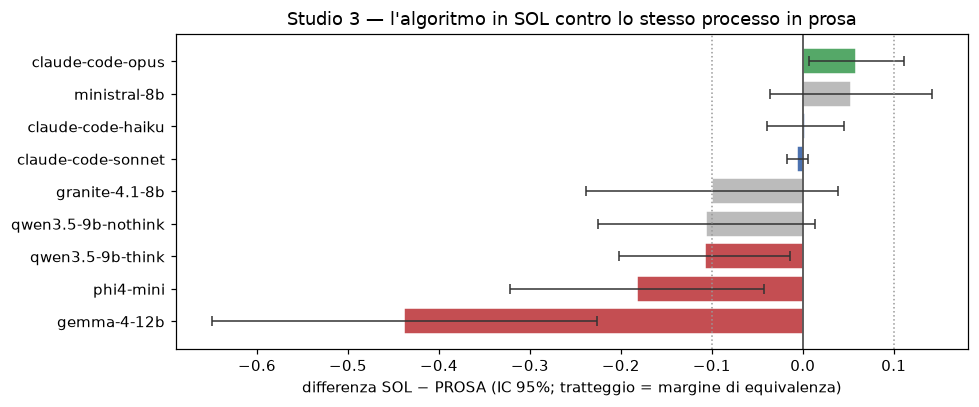

In [40]:
fig, ax = plt.subplots(figsize=(9, 3.8))
o = solpro.set_index("modello")
col = {"PROSA meglio": "#C44E52", "SOL meglio": "#55A868",
       "equivalenti": "#4C72B0", "non concluso": "#BBBBBB"}
ax.barh(o.index, o["differenza"], color=[col[e] for e in o["esito"]], edgecolor="white")
ax.errorbar(o["differenza"], range(len(o)),
            xerr=[o["differenza"] - o["IC95 basso"], o["IC95 alto"] - o["differenza"]],
            fmt="none", ecolor="#333", capsize=3, lw=1)
for x in (-MARGINE, MARGINE):
    ax.axvline(x, color="#999", lw=1, ls=":")
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("differenza SOL − PROSA (IC 95%; tratteggio = margine di equivalenza)")
ax.set_title("Studio 3 — l'algoritmo in SOL contro lo stesso processo in prosa")
fig.tight_layout()

In [41]:
# Bracci hosted: prose-generated (il formato migliore d'insieme) contro ciascun
# livello SOL, un braccio alla volta.
hk_tab = {}
for mod in HOSTED:
    M = d3[d3.model == mod].pivot_table(
        index="input_id", columns="rendering", values="ok", aggfunc="mean").dropna()
    righe = []
    for c in SOL + ["prose-mechanical"]:
        diff = M["prose-generated"] - M[c]
        p_tost, _, _ = ttost_paired(M["prose-generated"].to_numpy(), M[c].to_numpy(),
                                    -MARGINE, MARGINE)
        righe.append({"confronto": f"prose-generated vs {c}", "differenza": diff.mean(),
                      "p TOST": p_tost, "equivalenti": p_tost < ALPHA})
    hk_tab[mod] = (pd.DataFrame(righe), M)
    print(f"=== {mod} — il formato migliore d'insieme contro ciascun livello SOL ===")
    print(hk_tab[mod][0].round(4).to_string(index=False))
    liv_ = M[SOL + PROSA].mean()
    print(f"su {len(M)} item, resa fra {liv_.min():.3f} e {liv_.max():.3f}")
    print()

hk, M_hk = hk_tab["claude-code-haiku"]
M = M_hk
liv = M_hk[SOL + PROSA].mean()
print("Tutti e tre stanno in una banda stretta in ogni condizione: c'e' pochissimo spazio")
print("per differire. L'equivalenza vale A QUEL LIVELLO di prestazione — non dimostra che")
print("i formati siano equivalenti in assoluto, dimostra che per un modello che risolve")
print("quasi tutto non fanno differenza. Con tre bracci invece di uno, pero', la banda non")
print("e' piu' una proprieta' di un modello: e' dove finisce questo compito.")

=== claude-code-haiku — il formato migliore d'insieme contro ciascun livello SOL ===
                          confronto  differenza  p TOST  equivalenti
              prose-generated vs L0      0.0294  0.0145         True
              prose-generated vs L1      0.0588  0.2470        False
              prose-generated vs L2      0.0294  0.0145         True
              prose-generated vs L3      0.0588  0.1609        False
              prose-generated vs L4      0.0294  0.0145         True
prose-generated vs prose-mechanical      0.0882  0.4041        False
su 17 item, resa fra 0.882 e 0.971

=== claude-code-sonnet — il formato migliore d'insieme contro ciascun livello SOL ===
                          confronto  differenza  p TOST  equivalenti
              prose-generated vs L0      0.0000  0.0000         True
              prose-generated vs L1      0.0294  0.0145         True
              prose-generated vs L2      0.0000  0.0000         True
              prose-generated vs L

weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide


### 8.7 Quali bracci vale la pena riproporre

Domanda operativa, non di pubblicazione: quali dei sette formati meritano di stare in una
prossima campagna? Per questa decisione la soglia non e' `p < 0.05` — e' **"quel braccio ha
mai portato un beneficio?"**. Tre viste che rispondono insieme.

In [42]:
# --- 8.7.1 Matrice completa dei confronti, per studio ---
# Holm su tutte e 21 le coppie: la famiglia giusta quando si scandagliano tutti i formati,
# piu' severa della correzione su 6 usata in 8.5 per tre bersagli scelti in anticipo.
bilancio = {}
for st in ["1 — intake", "2 — routing", "3 — notrace"]:
    M = blocchi(st)
    righe = []
    for a, b in combinations(M.columns, 2):
        try:
            _, p_ = ss.wilcoxon(M[a], M[b], zero_method="wilcox")
        except ValueError:
            p_ = 1.0
        righe.append({"a": a, "b": b, "diff": (M[a] - M[b]).mean(), "p": p_})
    t = pd.DataFrame(righe)
    t["pH"] = multipletests(t.p, method="holm")[1]
    win = {c: 0 for c in M.columns}
    loss = {c: 0 for c in M.columns}
    for _, r in t.iterrows():
        if r.pH < ALPHA:
            vinc, perd = (r.a, r.b) if r["diff"] > 0 else (r.b, r.a)
            win[vinc] += 1
            loss[perd] += 1
    b_ = pd.DataFrame({"media": M.mean().round(3), "batte": pd.Series(win),
                       "battuto da": pd.Series(loss)})
    b_["saldo"] = b_["batte"] - b_["battuto da"]
    bilancio[st] = b_.sort_values("saldo", ascending=False)
    print(f"=== {st} (blocchi={len(M)}, 21 coppie, Holm) ===")
    print(bilancio[st].to_string())
    print()

saldo = pd.DataFrame({
    "batte": sum(bilancio[s]["batte"] for s in bilancio),
    "battuto da": sum(bilancio[s]["battuto da"] for s in bilancio)})
saldo["saldo"] = saldo["batte"] - saldo["battuto da"]
saldo = saldo.sort_values("saldo", ascending=False)
print("=== SALDO AGGREGATO sui tre studi (63 confronti in tutto) ===")
print(saldo.to_string())
print()
print("NESSUN livello SOL batte mai niente, in nessuno studio — l'unica eccezione e' L1")
print("che batte L4 nello studio 2. Tutto cio' che vince, lo vince prose-generated.")

=== 1 — intake (blocchi=40, 21 coppie, Holm) ===
                  media  batte  battuto da  saldo
L0                0.742      0           0      0
L1                0.724      0           0      0
L2                0.748      0           0      0
L3                0.722      0           0      0
L4                0.701      0           0      0
prose-generated   0.779      0           0      0
prose-mechanical  0.761      0           0      0

=== 2 — routing (blocchi=119, 21 coppie, Holm) ===
                  media  batte  battuto da  saldo
L1                0.391      1           0      1
prose-generated   0.424      1           0      1
L0                0.361      0           0      0
L2                0.366      0           0      0
L3                0.315      0           0      0
prose-mechanical  0.349      0           0      0
L4                0.294      0           2     -2



=== 3 — notrace (blocchi=179, 21 coppie, Holm) ===
                  media  batte  battuto da  saldo
prose-generated   0.626      5           0      5
prose-mechanical  0.559      0           0      0
L0                0.515      0           1     -1
L2                0.526      0           1     -1
L1                0.528      0           1     -1
L4                0.494      0           1     -1
L3                0.511      0           1     -1

=== SALDO AGGREGATO sui tre studi (63 confronti in tutto) ===
                  batte  battuto da  saldo
prose-generated       6           0      6
prose-mechanical      0           0      0
L1                    1           1      0
L2                    0           1     -1
L0                    0           1     -1
L3                    0           1     -1
L4                    0           3     -3

NESSUN livello SOL batte mai niente, in nessuno studio — l'unica eccezione e' L1
che batte L4 nello studio 2. Tutto cio' che vince, lo vince 

In [43]:
# --- 8.7.2 Rango di ciascun formato dentro ogni cella studio x modello ---
righe = []
for st in ["1 — intake", "2 — routing", "3 — notrace"]:
    d_ = df[df.studio == st]
    val = "quality_rate" if st.startswith("1") else "ok"
    t = d_.pivot_table(index="model", columns="rendering", values=val, aggfunc="mean")
    r_ = t.rank(axis=1, ascending=False)     # 1 = migliore dei sette
    for m in t.index:
        righe.append(r_.loc[m].rename(f"{st[0]}/{m}"))
R = pd.DataFrame(righe)
ranghi = pd.DataFrame({
    "rango medio": R.mean().round(2),
    "migliore su 7": (R == 1).sum(),
    "peggiore su 7": (R == 7).sum(),
    "quinto o peggio": (R >= 5).sum(),
}).sort_values("rango medio")
ranghi["celle"] = len(R)
print(f"Rango dentro ogni cella studio x modello ({len(R)} celle). 1 = migliore dei sette.\n")
print(ranghi.to_string())
print()

# Test dei segni: sta sotto il rango mediano piu' spesso del caso?
segni = []
for c in R.columns:
    sotto = int((R[c] > 4).sum())
    n_ = int((R[c] != 4).sum())
    segni.append({"rendering": c, "sotto la mediana": f"{sotto}/{n_}",
                  "p": ss.binomtest(sotto, n_, 0.5).pvalue if n_ else 1.0})
segni = pd.DataFrame(segni)
segni["p Holm"] = multipletests(segni.p, method="holm")[1]
segni["esito"] = np.where(segni["p Holm"] < ALPHA, "confermato", "non concluso")
print("Test dei segni sul rango, con correzione di Holm sui sette formati:\n")
print(segni.round(4).to_string(index=False))
print()
print("Solo prose-generated sopravvive alla correzione. Su L4 l'evidenza e' DIREZIONALE,")
print("non conclusiva come prova statistica — ma per decidere se riproporre un braccio")
print("la domanda e' un'altra: cfr. 'migliore su 7' nella tabella dei ranghi.")

Rango dentro ogni cella studio x modello (21 celle). 1 = migliore dei sette.

                  rango medio  migliore su 7  peggiore su 7  quinto o peggio  celle
rendering                                                                          
prose-generated          2.45              9              1                2     21
L2                       3.88              3              1                9     21
prose-mechanical         3.98              1              4                7     21
L1                       4.02              3              4                8     21
L0                       4.14              1              1                8     21
L3                       4.40              1              0               11     21
L4                       5.12              0              5               13     21

Test dei segni sul rango, con correzione di Holm sui sette formati:

       rendering sotto la mediana      p  p Holm        esito
              L0             9/20 

#### 8.7.3 Il meccanismo: il contesto collaterale costa la finestra

**Un vincolo di disegno, prima dei numeri.** `doc/experiment-minimum-context.md:478`:

> *The seven do not sit on one axis. Five of them form a curve, in which each level is a
> strict prefix of the next; two are comparison points against it. A figure that plots all
> seven in sequence, or an average taken across them, reads a change of language as a
> change of quantity and is wrong by construction.*

Quindi la correlazione fra token e resa si calcola **solo sui cinque livelli SOL**, dove il
contesto cresce per costruzione e ogni livello e' prefisso stretto del successivo. I due
formati in prosa restano nella tabella come punti di confronto, fuori dall'asse e fuori
dalla correlazione.

La curva L0..L4 — l'asse su cui il contesto cresce:

           token_prompt  token_output  tasso
rendering                                   
L0               2710.5         589.5  0.353
L1               2719.5         652.0  0.383
L2               3122.5         647.5  0.372
L3               9782.0         672.5  0.353
L4              11758.0         579.5  0.324

Spearman token del prompt / tasso, sui soli livelli SOL: rho=-0.400  p=0.5046  (n=5)
Con cinque punti la direzione e' netta ma il test non conclude: e' un indizio
coerente con il meccanismo, non una prova.

I due formati in prosa, punti di confronto FUORI dall'asse:

                  token_prompt  token_output  tasso
rendering                                          
prose-mechanical        2437.0         515.0  0.442
prose-generated         2379.0         360.5  0.512

Il salto di costo dentro la curva non e' graduale: da L2 a L3 il prompt cresce
di 3.1 volte (3122 -> 9782 token) e non compra nulla.

doc/experiment-minim

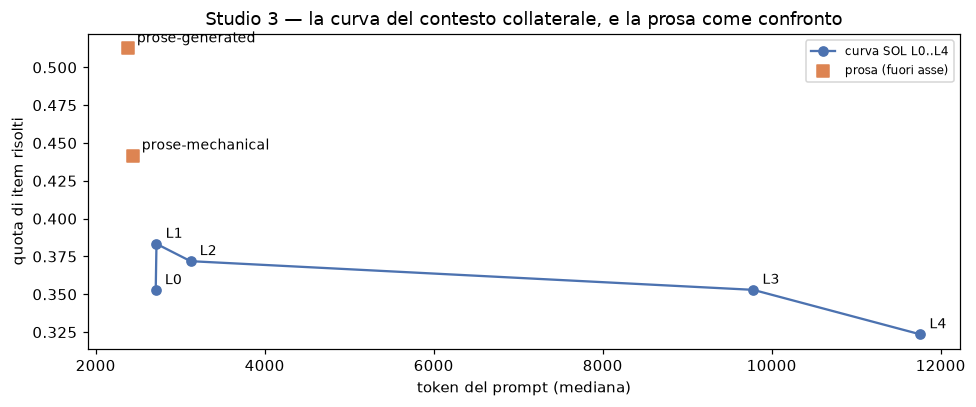

In [44]:
# Soli modelli locali: `tokens_in` di un braccio hosted lo riporta la CLI, con la
# sua contabilita' di cache e il contesto che aggiunge attorno al turno; quello di una
# cella locale lo conta il tokenizer del modello. Nella stessa mediana sarebbero due
# strumenti diversi, e la curva del costo e' un'affermazione sul prompt, non sul runner.
costo_rend = (df[(df.studio == "3 — notrace") & ~df.model.isin(HOSTED)].groupby("rendering")
              .agg(token_prompt=("tokens_in", "median"),
                   token_output=("tokens_out", "median"), tasso=("ok", "mean")))
curva = costo_rend.loc[["L0", "L1", "L2", "L3", "L4"]]
conf = costo_rend.loc[["prose-mechanical", "prose-generated"]]

print("La curva L0..L4 — l'asse su cui il contesto cresce:\n")
print(curva.round(3).to_string())
rho, p_rho = ss.spearmanr(curva.token_prompt, curva.tasso)
print(f"\nSpearman token del prompt / tasso, sui soli livelli SOL: "
      f"rho={rho:.3f}  p={p_rho:.4f}  (n={len(curva)})")
print("Con cinque punti la direzione e' netta ma il test non conclude: e' un indizio")
print("coerente con il meccanismo, non una prova.")
print()
print("I due formati in prosa, punti di confronto FUORI dall'asse:\n")
print(conf.round(3).to_string())
print()
salto = curva.loc["L3", "token_prompt"] / curva.loc["L2", "token_prompt"]
print(f"Il salto di costo dentro la curva non e' graduale: da L2 a L3 il prompt cresce")
print(f"di {salto:.1f} volte ({curva.loc['L2','token_prompt']:.0f} -> "
      f"{curva.loc['L3','token_prompt']:.0f} token) e non compra nulla.")
print()
print("doc/experiment-minimum-context.md:575 lo aveva previsto: «the L scale competes with")
print("reasoning for the window ... A model that closes well at L1 may have no room left at")
print("L4. The curve can be a bell rather than a step.»")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(curva.token_prompt, curva.tasso, "-o", color="#4C72B0", zorder=3, label="curva SOL L0..L4")
ax.scatter(conf.token_prompt, conf.tasso, s=70, marker="s", color="#DD8452",
           zorder=3, label="prosa (fuori asse)")
for r_, row in costo_rend.iterrows():
    ax.annotate(r_, (row.token_prompt, row.tasso), xytext=(6, 4),
                textcoords="offset points", fontsize=9)
ax.set_xlabel("token del prompt (mediana)")
ax.set_ylabel("quota di item risolti")
ax.set_title("Studio 3 — la curva del contesto collaterale, e la prosa come confronto")
ax.legend(fontsize=8)
fig.tight_layout()

### 8.8 Il contrasto ristretto: solo i bracci consigliati

Conseguenza operativa di 8.7: se `L3` e `L4` escono dal disegno, il confronto giusto
diventa **il meglio di SOL** (`L0`, `L1`, `L2`) contro la prosa. E' anche il confronto piu'
onesto verso SOL, perche' toglie i due livelli che lo zavorravano.

Due riferimenti: `prose-generated` da solo (il formato migliore d'insieme) e la media dei
due formati in prosa.

**Nota di metodo, e va detta qui.** Questo e' il terzo contrasto specificato dopo aver
visto i risultati: 21 coppie (8.3) -> SOL vs prosa (8.6) -> SOL ristretto vs prosa (qui).
Sono raffinamenti successivi della **stessa** ipotesi, non tre conferme indipendenti: che
l'equivalenza di Haiku esca tre volte non moltiplica l'evidenza. Per una pubblicazione la
forma onesta e' dichiarare il percorso, oppure ripetere questo contrasto su una campagna
nuova come conferma pre-registrata.

In [45]:
SOL_R = ["L0", "L1", "L2"]

def contrasto(rif, etichetta):
    righe = []
    for m in sorted(d3.model.unique()):
        M = d3[d3.model == m].pivot_table(index="input_id", columns="rendering",
                                          values="ok", aggfunc="mean").dropna()
        sol, pro = M[SOL_R].mean(axis=1), M[rif].mean(axis=1)
        diff = sol - pro
        try:
            _, p_ = ss.wilcoxon(sol, pro, zero_method="wilcox")
        except ValueError:
            p_ = 1.0
        p_tost, _, _ = ttost_paired(sol.to_numpy(), pro.to_numpy(), -MARGINE, MARGINE)
        se = diff.std(ddof=1) / np.sqrt(len(diff))
        righe.append({"modello": m, "SOL": sol.mean(), "riferimento": pro.mean(),
                      "differenza": diff.mean(),
                      "IC95 basso": diff.mean() - 1.96 * se,
                      "IC95 alto": diff.mean() + 1.96 * se,
                      "p": p_, "p TOST": p_tost})
    t = pd.DataFrame(righe).sort_values("differenza")
    t["esito"] = np.where(
        t.p < ALPHA, np.where(t.differenza > 0, "SOL meglio", "PROSA meglio"),
        np.where(t["p TOST"] < ALPHA, "equivalenti", "non concluso"))
    print(f"=== SOL ristretto (L0, L1, L2) contro {etichetta} — "
          f"{len(d3.input_id.unique())} item, appaiato, margine ±{MARGINE} ===")
    print(t.round(4).to_string(index=False))
    print()
    return t

ristretto_pg = contrasto(["prose-generated"], "prose-generated")
ristretto_pr = contrasto(["prose-generated", "prose-mechanical"], "entrambi i formati in prosa")

n_prosa_r = int((ristretto_pr.esito == "PROSA meglio").sum())
print(f"Con i soli bracci consigliati, la prosa batte SOL su {n_prosa_r} modelli locali "
      f"(erano {n_prosa} col confronto su tutti e cinque i livelli).")
print("Togliere L3 e L4 rende il confronto piu' PRECISO, non piu' favorevole a SOL:")
print("quei due livelli trascinavano in basso la media SOL da entrambe le parti.")

_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide


=== SOL ristretto (L0, L1, L2) contro prose-generated — 17 item, appaiato, margine ±0.1 ===
           modello    SOL  riferimento  differenza  IC95 basso  IC95 alto      p  p TOST        esito
       gemma-4-12b 0.4314       0.8824     -0.4510     -0.6729    -0.2291 0.0066  0.9966 PROSA meglio
         phi4-mini 0.0196       0.2647     -0.2451     -0.4549    -0.0353 0.0405  0.9029 PROSA meglio
  qwen3.5-9b-think 0.7026       0.8824     -0.1797     -0.2935    -0.0659 0.0069  0.9057 PROSA meglio
qwen3.5-9b-nothink 0.2843       0.3824     -0.0980     -0.2541     0.0581 0.1138  0.4903 non concluso
      ministral-8b 0.6373       0.7059     -0.0686     -0.2391     0.1019 0.2334  0.3616 non concluso
 claude-code-haiku 0.9314       0.9706     -0.0392     -0.0988     0.0204 0.1797  0.0315  equivalenti
claude-code-sonnet 0.9902       1.0000     -0.0098     -0.0290     0.0094 0.3173  0.0000  equivalenti
  claude-code-opus 1.0000       1.0000      0.0000      0.0000     0.0000    NaN  0.0000  eq

In [46]:
# I bracci hosted: il caso al soffitto, guardato da vicino.
for mod in HOSTED:
    a_ = ristretto_pg[ristretto_pg.modello == mod].iloc[0]
    b_ = ristretto_pr[ristretto_pr.modello == mod].iloc[0]
    print(f"{mod}, studio 3, {n_vivi} item non a pavimento:")
    for nome, r in [("vs prose-generated", a_), ("vs entrambi i formati in prosa", b_)]:
        print(f"  {nome:32s} SOL={r['SOL']:.3f}  rif={r['riferimento']:.3f}  "
              f"diff={r['differenza']:+.3f}  "
              f"IC95=[{r['IC95 basso']:+.3f}, {r['IC95 alto']:+.3f}]  "
              f"TOST p={r['p TOST']:.4f}  -> {r['esito']}")
    print()

hk_pg = ristretto_pg[ristretto_pg.modello == "claude-code-haiku"].iloc[0]
hk_pr = ristretto_pr[ristretto_pr.modello == "claude-code-haiku"].iloc[0]
Mh = d3[d3.model == "claude-code-haiku"].pivot_table(
    index="input_id", columns="rendering", values="ok", aggfunc="mean").dropna()
print(f"Su questi {len(Mh)} item prose-generated risolve "
      f"una quota di {Mh['prose-generated'].mean():.3f}: il soffitto e' assoluto.")
print("L'affermazione che regge e': su un compito che i modelli hosted risolvono quasi")
print("interamente, dare l'algoritmo in SOL o in prosa non cambia nulla — e vale su tutti")
print("e tre i bracci, non su uno. NON dimostra che non cambierebbe su un compito piu'")
print("difficile: servirebbe una fixture dove nemmeno Opus stia al soffitto, e il fatto")
print("che Opus non superi Sonnet dice che quella fixture non si ottiene cambiando modello.")

claude-code-haiku, studio 3, 17 item non a pavimento:
  vs prose-generated               SOL=0.931  rif=0.971  diff=-0.039  IC95=[-0.099, +0.020]  TOST p=0.0315  -> equivalenti
  vs entrambi i formati in prosa   SOL=0.931  rif=0.926  diff=+0.005  IC95=[-0.038, +0.048]  TOST p=0.0003  -> equivalenti

claude-code-sonnet, studio 3, 17 item non a pavimento:
  vs prose-generated               SOL=0.990  rif=1.000  diff=-0.010  IC95=[-0.029, +0.009]  TOST p=0.0000  -> equivalenti
  vs entrambi i formati in prosa   SOL=0.990  rif=1.000  diff=-0.010  IC95=[-0.029, +0.009]  TOST p=0.0000  -> equivalenti

claude-code-opus, studio 3, 17 item non a pavimento:
  vs prose-generated               SOL=1.000  rif=1.000  diff=+0.000  IC95=[+0.000, +0.000]  TOST p=0.0000  -> equivalenti
  vs entrambi i formati in prosa   SOL=1.000  rif=0.941  diff=+0.059  IC95=[+0.007, +0.111]  TOST p=0.0700  -> SOL meglio

Su questi 17 item prose-generated risolve una quota di 0.971: il soffitto e' assoluto.
L'affermazi

### 8.9 Le conclusioni operative, messe alla prova

Quattro affermazioni che uno vorrebbe portare fuori dalla campagna. Ciascuna verificata
contro i dati, con il verdetto scritto accanto.

1. *un po' di contesto in piu' per capire SOL aiuta — e quanto ne serve?*
2. *sui modelli commerciali usatelo crudo, o con un minimo di contesto*
3. *sui modelli locali convertitelo in prosa, usando il prompt*
4. *il ramo `prose-mechanical` e' un fallimento del convertitore: non e' maturo*

In [47]:
# --- 8.9.1 Un po' di contesto aiuta? L1 e L2 contro L0 crudo ---
righe = []
for m in sorted(d3.model.unique()):
    M = d3[d3.model == m].pivot_table(index="input_id", columns="rendering",
                                      values="ok", aggfunc="mean").dropna()
    for lv in ["L1", "L2"]:
        diff = M[lv] - M["L0"]
        try:
            _, p_ = ss.wilcoxon(M[lv], M["L0"], zero_method="wilcox")
        except ValueError:
            p_ = 1.0
        p_tost, _, _ = ttost_paired(M[lv].to_numpy(), M["L0"].to_numpy(), -MARGINE, MARGINE)
        righe.append({"modello": m, "confronto": f"{lv} − L0", "differenza": diff.mean(),
                      "p": p_, "p TOST": p_tost})
ctx = pd.DataFrame(righe)
ctx["p Holm"] = multipletests(ctx.p, method="holm")[1]
ctx["esito"] = np.where(ctx["p Holm"] < ALPHA,
                        np.where(ctx.differenza > 0, "AIUTA", "PEGGIORA"),
                        np.where(ctx["p TOST"] < ALPHA, "equivalente", "non concluso"))
print(f"L1 e L2 contro L0 crudo, appaiato sull'item, Holm sui {len(ctx)} confronti:\n")
print(ctx.round(4).to_string(index=False))
n_aiuta = int((ctx.esito == "AIUTA").sum())
print(f"\nCasi in cui il contesto aggiuntivo aiuta in modo significativo: "
      f"{n_aiuta} su {len(ctx)}.")
print("Nessun contesto aggiuntivo aiuta, a nessun livello. Il PEGGIORAMENTO di L3/L4 e'")
print("un'altra affermazione, e va verificata a parte: cfr. 8.10.1.")
print("Questa risposta non dipende dal soffitto di Haiku ne' da contrasti post-hoc:")
print("e' un confronto diretto su tutti i modelli.")

_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide


L1 e L2 contro L0 crudo, appaiato sull'item, Holm sui 18 confronti:

           modello confronto  differenza      p  p TOST  p Holm        esito
 claude-code-haiku   L1 − L0     -0.0294 0.3173  0.0145   1.000  equivalente
 claude-code-haiku   L2 − L0      0.0000 1.0000  0.0165   1.000  equivalente
  claude-code-opus   L1 − L0      0.0000    NaN  0.0000     NaN  equivalente
  claude-code-opus   L2 − L0      0.0000    NaN  0.0000     NaN  equivalente
claude-code-sonnet   L1 − L0     -0.0294 0.3173  0.0145   1.000  equivalente
claude-code-sonnet   L2 − L0      0.0000    NaN  0.0000     NaN  equivalente
       gemma-4-12b   L1 − L0      0.0588 0.4142  0.2897   1.000 non concluso
       gemma-4-12b   L2 − L0     -0.0882 0.1797  0.4283   1.000 non concluso
    granite-4.1-8b   L1 − L0      0.0625 0.5637  0.3697   1.000 non concluso
    granite-4.1-8b   L2 − L0     -0.0312 0.7630  0.2646   1.000 non concluso
      ministral-8b   L1 − L0     -0.0294 0.5637  0.0967   1.000 non concluso
      m

In [48]:
# --- 8.9.2 I bracci hosted con SOL crudo: quanto perdono a non ricevere niente? ---
crudo_tab = {}
for mod in HOSTED:
    Mx = d3[d3.model == mod].pivot_table(
        index="input_id", columns="rendering", values="ok", aggfunc="mean").dropna()
    righe = []
    for c in [x for x in Mx.columns if x != "L0"]:
        diff = Mx["L0"] - Mx[c]
        p_tost, _, _ = ttost_paired(Mx["L0"].to_numpy(), Mx[c].to_numpy(), -MARGINE, MARGINE)
        righe.append({"confronto": f"L0 vs {c}", "differenza": diff.mean(),
                      "p TOST": p_tost, "equivalenti": p_tost < ALPHA})
    crudo_tab[mod] = (pd.DataFrame(righe), Mx)
    print(f"=== {mod}, L0 crudo contro tutto il resto ({len(Mx)} item) ===")
    print(crudo_tab[mod][0].round(4).to_string(index=False))
    print(f"L0 crudo: quota {Mx['L0'].mean():.3f}   "
          f"equivalente a {int(crudo_tab[mod][0].equivalenti.sum())} formati su "
          f"{len(crudo_tab[mod][0])}")
    print()

crudo, Mh2 = crudo_tab["claude-code-haiku"]
print("Le repliche danno mezzi punti — un item risolto in una sola delle due run vale 0.5 —")
print("quindi il conteggio intero non e' la misura giusta: si legge la quota.")
print("'Crudo' non e' un compromesso: e' il massimo, al costo minimo. Vale su tutti e tre")
print("i bracci hosted, su UNA fixture, al soffitto. 'I modelli commerciali' al plurale")
print("ora e' nei dati per tre modelli su tre — resta una sola fixture.")

=== claude-code-haiku, L0 crudo contro tutto il resto (17 item) ===
             confronto  differenza  p TOST  equivalenti
              L0 vs L1      0.0294  0.0145         True
              L0 vs L2      0.0000  0.0165         True
              L0 vs L3      0.0294  0.0145         True
              L0 vs L4      0.0000  0.0165         True
 L0 vs prose-generated     -0.0294  0.0145         True
L0 vs prose-mechanical      0.0588  0.1609        False
L0 crudo: quota 0.941   equivalente a 5 formati su 6

=== claude-code-sonnet, L0 crudo contro tutto il resto (17 item) ===
             confronto  differenza  p TOST  equivalenti
              L0 vs L1      0.0294  0.0145         True
              L0 vs L2      0.0000  0.0000         True
              L0 vs L3      0.0000  0.0000         True
              L0 vs L4      0.0000  0.0000         True
 L0 vs prose-generated      0.0000  0.0000         True
L0 vs prose-mechanical      0.0000  0.0000         True
L0 crudo: quota 1.000   e

weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide
weightstats.py:440: RuntimeWarning: divide by zero encountered in scalar divide


In [49]:
# --- 8.9.3 Come converti conta? generated contro mechanical, per modello ---
righe = []
for m in sorted(d3.model.unique()):
    M = d3[d3.model == m].pivot_table(index="input_id", columns="rendering",
                                      values="ok", aggfunc="mean").dropna()
    diff = M["prose-generated"] - M["prose-mechanical"]
    try:
        _, p_ = ss.wilcoxon(M["prose-generated"], M["prose-mechanical"], zero_method="wilcox")
    except ValueError:
        p_ = 1.0
    righe.append({"modello": m, "generated": M["prose-generated"].mean(),
                  "mechanical": M["prose-mechanical"].mean(), "differenza": diff.mean(),
                  "p": p_})
conv = pd.DataFrame(righe).sort_values("differenza", ascending=False)
conv["p Holm"] = multipletests(conv.p, method="holm")[1]
conv["esito"] = np.where(conv["p Holm"] < ALPHA, "GENERATED meglio", "non concluso")
print("prose-generated contro prose-mechanical, per modello:\n")
print(conv.round(4).to_string(index=False))
print(f"\nDifferenze significative: {int((conv.esito == 'GENERATED meglio').sum())} su "
      f"{len(conv)}. La direzione favorisce la resa generata in "
      f"{int((conv.differenza > 0).sum())} casi su {len(conv)}, ma non e' dimostrata.")
print("=> 'convertitelo in prosa' regge; 'usando il prompt' e' una preferenza pratica,")
print("   non un risultato.")

_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide


prose-generated contro prose-mechanical, per modello:

           modello  generated  mechanical  differenza      p  p Holm        esito
      ministral-8b     0.7059      0.5294      0.1765 0.1653  0.9438 non concluso
         phi4-mini     0.2647      0.1471      0.1176 0.1573  0.9438 non concluso
  claude-code-opus     1.0000      0.8824      0.1176 0.0455  0.4095 non concluso
  qwen3.5-9b-think     0.8824      0.7647      0.1176 0.0455  0.4095 non concluso
 claude-code-haiku     0.9706      0.8824      0.0882 0.0833  0.5829 non concluso
       gemma-4-12b     0.8824      0.7941      0.0882 0.1797  0.9438 non concluso
claude-code-sonnet     1.0000      1.0000      0.0000    NaN     NaN non concluso
    granite-4.1-8b     0.5312      0.5312      0.0000 0.9415  1.0000 non concluso
qwen3.5-9b-nothink     0.3824      0.3824      0.0000 1.0000  1.0000 non concluso

Differenze significative: 0 su 9. La direzione favorisce la resa generata in 6 casi su 9, ma non e' dimostrata.
=> 'converti

In [50]:
# --- 8.9.4 prose-mechanical ha fallito? ---
# Il convertitore deterministico (sol2prose.py) contro SOL, aggregato sui blocchi.
Mb = d3.pivot_table(index=["model", "input_id"], columns="rendering",
                    values="ok", aggfunc="mean").dropna()
righe = []
for b in ["L4", "L0", "L1", "L2", "prose-generated"]:
    diff = Mb["prose-mechanical"] - Mb[b]
    _, p_ = ss.wilcoxon(Mb["prose-mechanical"], Mb[b], zero_method="wilcox")
    righe.append({"confronto": f"prose-mechanical vs {b}", "differenza": diff.mean(), "p": p_})
mech = pd.DataFrame(righe).sort_values("p")
mech["p Holm"] = multipletests(mech.p, method="holm")[1]
mech["esito"] = np.where(mech["p Holm"] < ALPHA,
                         np.where(mech.differenza > 0, "MECHANICAL meglio", "peggio"),
                         "non concluso")
print(f"Aggregato su {len(Mb)} blocchi (modello x item), studio 3, item non a pavimento:\n")
print(mech.round(4).to_string(index=False))
print()
print(f"Rango medio di prose-mechanical fra i sette formati: "
      f"{ranghi.loc['prose-mechanical','rango medio']:.2f} — secondo su sette, davanti a")
print("tutti e cinque i livelli SOL. Bilancio vinte-perse nei tre studi: "
      f"{int(saldo.loc['prose-mechanical','batte'])} vinte, "
      f"{int(saldo.loc['prose-mechanical','battuto da'])} perse.")
print()
print("Il convertitore deterministico produce output che fa risolvere PIU' item di SOL")
print("crudo, e non e' distinguibile da prose-generated. Nella campagna non ha")
print("sottoperformato: ha battuto SOL crudo.")
print()
print("Nota epistemologica, valida e da tenere: questi numeri sono una proprieta' di")
print("sol2prose.py, non della conversione meccanica come classe — da qui non si conclude")
print("nulla su 'un convertitore migliore'. Ma lo stesso argomento impedisce la")
print("conclusione opposta: non si puo' dire immaturo cio' che non ha sottoperformato.")

Aggregato su 152 blocchi (modello x item), studio 3, item non a pavimento:

                          confronto  differenza      p  p Holm        esito
prose-mechanical vs prose-generated     -0.0789 0.0097  0.0483       peggio
             prose-mechanical vs L4      0.0757 0.0202  0.0806 non concluso
             prose-mechanical vs L0      0.0515 0.0576  0.1728 non concluso
             prose-mechanical vs L1      0.0362 0.1437  0.2873 non concluso
             prose-mechanical vs L2      0.0384 0.1929  0.2873 non concluso

Rango medio di prose-mechanical fra i sette formati: 3.98 — secondo su sette, davanti a
tutti e cinque i livelli SOL. Bilancio vinte-perse nei tre studi: 0 vinte, 0 perse.

Il convertitore deterministico produce output che fa risolvere PIU' item di SOL
crudo, e non e' distinguibile da prose-generated. Nella campagna non ha
sottoperformato: ha battuto SOL crudo.

Nota epistemologica, valida e da tenere: questi numeri sono una proprieta' di
sol2prose.py, non della 

### 8.10 Tre verifiche sulla sintesi finale

Tre affermazioni che chiudono il quadro operativo, e che vanno controllate perche' due
sono forti e una e' un'estrapolazione fuori dai dati.

In [51]:
# --- 8.10.1 'Piu' contesto spesso PEGGIORA': e' vero? ---
# Testa a testa L3/L4 contro i tre livelli economici, per modello e aggregato.
righe = []
for m in sorted(d3.model.unique()):
    M = d3[d3.model == m].pivot_table(index="input_id", columns="rendering",
                                      values="ok", aggfunc="mean").dropna()
    for hi in ["L3", "L4"]:
        for lo in ["L0", "L1", "L2"]:
            try:
                _, p_ = ss.wilcoxon(M[hi], M[lo], zero_method="wilcox")
            except ValueError:
                p_ = 1.0
            righe.append({"modello": m, "confronto": f"{hi} − {lo}",
                          "differenza": (M[hi] - M[lo]).mean(), "p": p_})
caro = pd.DataFrame(righe)
caro["p Holm"] = multipletests(caro.p, method="holm")[1]
n_peggio = int(((caro["p Holm"] < ALPHA) & (caro.differenza < 0)).sum())
n_meglio = int(((caro["p Holm"] < ALPHA) & (caro.differenza > 0)).sum())
print(f"Confronti per modello: {len(caro)}   peggioramenti significativi: {n_peggio}   "
      f"miglioramenti: {n_meglio}")
print()

Mb2 = d3.pivot_table(index=["model", "input_id"], columns="rendering",
                     values="ok", aggfunc="mean").dropna()
righe = []
for hi in ["L3", "L4"]:
    for lo in ["L0", "L1", "L2"]:
        _, p_ = ss.wilcoxon(Mb2[hi], Mb2[lo], zero_method="wilcox")
        righe.append({"confronto": f"{hi} − {lo}",
                      "differenza": (Mb2[hi] - Mb2[lo]).mean(), "p": p_})
caro_agg = pd.DataFrame(righe)
caro_agg["p Holm"] = multipletests(caro_agg.p, method="holm")[1]
print(f"Aggregato su {len(Mb2)} blocchi (modello x item):\n")
print(caro_agg.round(4).to_string(index=False))
print()
print("=> 'Non aiuta' e' dimostrato (zero miglioramenti). 'Spesso peggiora' NON lo e':")
print("   testa a testa contro i livelli economici il peggioramento non regge la")
print("   correzione. La formulazione esatta e': non aiuta mai, e costa tre volte tanto.")
print("   L'argomento contro L3/L4 e' il COSTO, non un danno dimostrato.")

_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide
_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide
_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide
_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide


Confronti per modello: 54   peggioramenti significativi: 0   miglioramenti: 0

Aggregato su 152 blocchi (modello x item):

confronto  differenza      p  p Holm
  L3 − L0     -0.0077 0.7413  0.9145
  L3 − L1     -0.0230 0.3302  0.9145
  L3 − L2     -0.0208 0.2286  0.9145
  L4 − L0     -0.0241 0.2819  0.9145
  L4 − L1     -0.0395 0.1553  0.7764
  L4 − L2     -0.0373 0.0296  0.1776

=> 'Non aiuta' e' dimostrato (zero miglioramenti). 'Spesso peggiora' NON lo e':
   testa a testa contro i livelli economici il peggioramento non regge la
   correzione. La formulazione esatta e': non aiuta mai, e costa tre volte tanto.
   L'argomento contro L3/L4 e' il COSTO, non un danno dimostrato.


In [52]:
# --- 8.10.2 'Sui locali il formato migliore va trovato con i test': i test sono stabili? ---
righe = []
for m in sorted(df[df.fixture == "support-routing"].model.unique()):
    r = {"modello": m}
    for et, fx in [("studio 2", "support-routing"), ("studio 3", "support-routing-notrace")]:
        g = (df[(df.fixture == fx) & (df.model == m) & (~df.input_id.isin(pav.index))]
             .groupby("rendering")["ok"].mean())
        r[et] = g.idxmax()
        r[f"{et} tasso"] = g.max()
    r["concorda"] = "si" if r["studio 2"] == r["studio 3"] else "no"
    righe.append(r)
stab = pd.DataFrame(righe)
print("Formato migliore per modello, nei due studi indipendenti:\n")
print(stab.round(3).to_string(index=False))
n_stab = int((stab.concorda == "si").sum())
print(f"\nConcordano: {n_stab} su {len(stab)}.")
print()
sol_vince = stab[stab["studio 3"].str.startswith("L")]
print(f"Modelli il cui formato migliore e' un livello SOL in ENTRAMBI gli studi: "
      f"{list(sol_vince[sol_vince.concorda=='si'].modello)}")
print("Non e' rumore: e' ripetuto su due studi. Per quei modelli la risposta e' davvero SOL.")
print("=> 'testalo' non e' una formula di prudenza: i test danno risposte stabili, e")
print("   la risposta non e' la stessa per tutti.")

Formato migliore per modello, nei due studi indipendenti:

           modello        studio 2  studio 2 tasso        studio 3  studio 3 tasso concorda
       gemma-4-12b prose-generated           0.500 prose-generated           0.882       si
    granite-4.1-8b              L1           0.647              L1           0.588       si
      ministral-8b              L2           0.824              L2           0.765       si
         phi4-mini prose-generated           0.294 prose-generated           0.265       si
qwen3.5-9b-nothink prose-generated           0.353 prose-generated           0.382       si
  qwen3.5-9b-think              L3           0.706 prose-generated           0.882       no

Concordano: 5 su 6.

Modelli il cui formato migliore e' un livello SOL in ENTRAMBI gli studi: ['granite-4.1-8b', 'ministral-8b']
Non e' rumore: e' ripetuto su due studi. Per quei modelli la risposta e' davvero SOL.
=> 'testalo' non e' una formula di prudenza: i test danno risposte stabili, e
   

#### 8.10.3 I bracci hosted contro tutto il resto

**I modelli dello studio 3 non stanno su una scala di potenza.** Sono qualitativamente diversi, e
metterli in fila per resa media su *questa* fixture e chiamarla capacita' e' lo stesso
errore che il documento di disegno vieta per i sette rendering: leggere una differenza di
natura come una differenza di quantita'. Una correlazione di rango fra resa e sensibilita'
al formato — che una versione precedente di questo notebook calcolava — presuppone
un'ordinabilita' che non c'e'. E' stata tolta.

L'unico scarto di capacita' su cui si puo' contare e' **i tre bracci hosted contro i sei
locali**. Al massimo, con cautela, `qwen3.5-9b-think` un gradino sopra gli altri locali.
Fra i tre hosted, invece, non c'e' scala: sonnet e opus distano una manciata di run.

Resta un problema di misura: l'escursione fra formati **si comprime da sola** vicino al
soffitto, per la varianza di un esito binario. Confrontare le escursioni grezze fra modelli
a livelli diversi non dice niente. La correzione: per ciascun modello si simula il mondo in
cui **il formato non ha alcun effetto**, tenendo la difficolta' di ogni item come e', e si
guarda quanta escursione il caso produrrebbe comunque a quel livello di prestazione.

Escursione fra i sette rendering, contro quella che il caso produrrebbe comunque
a quel livello di prestazione (5000 simulazioni, seed fisso):

           modello   resa  escursione osservata  attesa dal caso (mediana)  p (piatto quanto il caso)
 claude-code-haiku 0.9286                0.0882                     0.0882                     0.7062
qwen3.5-9b-nothink 0.3067                0.1471                     0.1176                     0.7368
  qwen3.5-9b-think 0.7465                0.2353                     0.1765                     0.9326
claude-code-sonnet 0.9958                0.0294                     0.0294                     0.9610
      ministral-8b 0.6555                0.2353                     0.1471                     0.9776
    granite-4.1-8b 0.4598                0.3438                     0.1875                     0.9892
  claude-code-opus 0.9832                0.1176                     0.0588                     0.9992
       gemma-4-12b 0.5252               

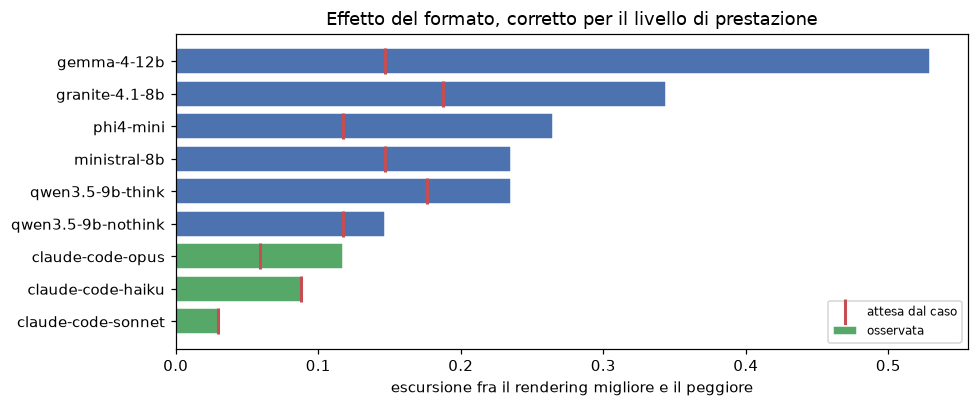

In [53]:
rng = np.random.default_rng(0)
NSIM = 5000

righe = []
for m in sorted(d3.model.unique()):
    g = d3[d3.model == m]
    M = g.pivot_table(index="input_id", columns="rendering", values="ok",
                      aggfunc="mean").dropna()
    nrep = int(g.groupby(["input_id", "rendering"]).size().median())
    oss = M.mean().max() - M.mean().min()
    p_item = M.mean(axis=1).to_numpy()      # difficolta' dell'item PER QUEL MODELLO
    n_it, n_r = M.shape
    sim = rng.binomial(nrep, p_item[:, None, None], size=(n_it, n_r, NSIM)) / nrep
    tassi = sim.mean(axis=0)                # (rendering, simulazione)
    nullo = tassi.max(axis=0) - tassi.min(axis=0)
    righe.append({"modello": m, "resa": M.mean().mean(), "escursione osservata": oss,
                  "attesa dal caso (mediana)": np.median(nullo),
                  "p (piatto quanto il caso)": (nullo <= oss).mean()})
piatto = pd.DataFrame(righe).sort_values("p (piatto quanto il caso)")
print(f"Escursione fra i sette rendering, contro quella che il caso produrrebbe comunque")
print(f"a quel livello di prestazione ({NSIM} simulazioni, seed fisso):\n")
print(piatto.round(4).to_string(index=False))
print()
print("p vicino a 0.5 = l'escursione osservata e' quella che il caso prevede: nessun")
print("effetto del formato rilevabile. p vicino a 1 = escursione piu' ampia del caso.")
print()
_h = piatto[piatto.modello == "claude-code-haiku"].iloc[0]
_host = piatto[piatto.modello.isin(HOSTED)]
_loc = piatto[~piatto.modello.isin(HOSTED)]
for _, r in _host.iterrows():
    print(f"{r['modello']:22s} osservata {r['escursione osservata']:.4f}, "
          f"attesa dal caso {r['attesa dal caso (mediana)']:.4f}, "
          f"p = {r['p (piatto quanto il caso)']:.3f}")
print()
print("La piattezza dei bracci hosted NON e' un artefatto del soffitto: la simulazione")
print("tiene conto del livello, e l'escursione osservata e' quella che il caso prevede.")
print()
print(f"I {len(_loc)} modelli locali stanno sopra l'attesa "
      f"(p da {_loc['p (piatto quanto il caso)'].min():.3f} a "
      f"{_loc['p (piatto quanto il caso)'].max():.3f}); i {len(_host)} hosted da "
      f"{_host['p (piatto quanto il caso)'].min():.3f} a "
      f"{_host['p (piatto quanto il caso)'].max():.3f}.")

fig, ax = plt.subplots(figsize=(9, 3.8))
o = piatto.set_index("modello").sort_values("escursione osservata")
y = np.arange(len(o))
ax.barh(y, o["escursione osservata"], color=["#55A868" if m in HOSTED
                                             else "#4C72B0" for m in o.index],
        edgecolor="white", label="osservata")
ax.scatter(o["attesa dal caso (mediana)"], y, color="#C44E52", zorder=3, marker="|",
           s=300, linewidths=2, label="attesa dal caso")
ax.set_yticks(y)
ax.set_yticklabels(o.index)
ax.set_xlabel("escursione fra il rendering migliore e il peggiore")
ax.set_title("Effetto del formato, corretto per il livello di prestazione")
ax.legend(fontsize=8)
fig.tight_layout()

#### 8.10.4 Regge un ordinamento a tre livelli — Haiku > qwen-think > altri?

Se reggesse, darebbe un secondo punto: non piu' un caso isolato contro sei, ma un gradino
intermedio. Va pero' spezzata in due domande, perche' *piu' capace* e *meno sensibile al
formato* sono cose diverse.

In [54]:
# --- Resa: qwen3.5-9b-think contro gli altri, appaiato su (item x rendering) ---
for st in ["1 — intake", "2 — routing", "3 — notrace"]:
    dd_ = df[df.studio == st]
    if not st.startswith("1"):
        dd_ = dd_[~dd_.input_id.isin(pav.index)]
    val = "quality_rate" if st.startswith("1") else "ok"
    M = dd_.pivot_table(index=["input_id", "rendering"], columns="model",
                        values=val, aggfunc="mean").dropna()
    if "qwen3.5-9b-think" not in M.columns:
        continue
    righe = []
    for c in M.columns:
        if c == "qwen3.5-9b-think":
            continue
        try:
            _, p_ = ss.wilcoxon(M["qwen3.5-9b-think"], M[c], zero_method="wilcox")
        except ValueError:
            p_ = 1.0
        righe.append({"vs": c, "differenza": (M["qwen3.5-9b-think"] - M[c]).mean(), "p": p_})
    t = pd.DataFrame(righe).sort_values("differenza", ascending=False)
    t["p Holm"] = multipletests(t.p, method="holm")[1]
    t["esito"] = np.where(t["p Holm"] < ALPHA,
                          np.where(t.differenza > 0, "QWEN-THINK meglio", "peggio"),
                          "non concluso")
    print(f"=== studio {st} (blocchi={len(M)}) ===")
    print(t.round(4).to_string(index=False))
    print()
print("Sulla RESA l'ordinamento tiene: nello studio 3 qwen-think batte tutti e cinque gli")
print("altri locali, e i tre bracci hosted battono qwen-think. Nello studio 2 quattro su")
print("cinque. Sopra qwen-think, pero', l'ordinamento finisce: i tre hosted non si")
print("ordinano fra loro.")

=== studio 1 — intake (blocchi=42) ===
                vs  differenza      p  p Holm             esito
         phi4-mini      0.4890 0.0000  0.0000 QWEN-THINK meglio
      ministral-8b      0.1320 0.0000  0.0000 QWEN-THINK meglio
    granite-4.1-8b      0.0790 0.0008  0.0023 QWEN-THINK meglio
       gemma-4-12b      0.0497 0.0275  0.0550      non concluso
qwen3.5-9b-nothink      0.0248 0.2064  0.2064      non concluso

=== studio 2 — routing (blocchi=117) ===
                vs  differenza      p  p Holm             esito
         phi4-mini      0.5427 0.0000  0.0000 QWEN-THINK meglio
qwen3.5-9b-nothink      0.4786 0.0000  0.0000 QWEN-THINK meglio
       gemma-4-12b      0.2393 0.0000  0.0000 QWEN-THINK meglio
    granite-4.1-8b      0.1838 0.0001  0.0001 QWEN-THINK meglio
      ministral-8b     -0.0641 0.2364  0.2364      non concluso



=== studio 3 — notrace (blocchi=117) ===
                vs  differenza      p  p Holm             esito
         phi4-mini      0.6738 0.0000  0.0000 QWEN-THINK meglio
qwen3.5-9b-nothink      0.4387 0.0000  0.0000 QWEN-THINK meglio
    granite-4.1-8b      0.3020 0.0000  0.0000 QWEN-THINK meglio
       gemma-4-12b      0.2165 0.0000  0.0000 QWEN-THINK meglio
      ministral-8b      0.0926 0.0181  0.0181 QWEN-THINK meglio
 claude-code-haiku     -0.1766 0.0000  0.0000            peggio
  claude-code-opus     -0.2322 0.0000  0.0000            peggio
claude-code-sonnet     -0.2450 0.0000  0.0000            peggio

Sulla RESA l'ordinamento tiene: nello studio 3 qwen-think batte tutti e cinque gli
altri locali, e i tre bracci hosted battono qwen-think. Nello studio 2 quattro su
cinque. Sopra qwen-think, pero', l'ordinamento finisce: i tre hosted non si
ordinano fra loro.


In [55]:
# --- Sensibilita' al formato: il gradino intermedio ha sensibilita' intermedia? ---
grad = piatto.copy()
grad["rapporto oss/attesa"] = (grad["escursione osservata"]
                               / grad["attesa dal caso (mediana)"])
grad = grad[["modello", "resa", "escursione osservata", "attesa dal caso (mediana)",
             "rapporto oss/attesa", "p (piatto quanto il caso)"]].sort_values(
    "rapporto oss/attesa")
print("Rapporto fra escursione osservata e attesa dal caso (1.00 = indistinguibile "
      "dal caso):\n")
print(grad.round(3).to_string(index=False))
print()
pos = list(grad.modello).index("qwen3.5-9b-think") + 1
print(f"qwen3.5-9b-think e' {pos}o su {len(grad)} per piattezza, non secondo: sopra di lui")
print("c'e' qwen3.5-9b-nothink, che sulla resa e' quasi il peggiore.")
print()
_flat = list(grad[grad["p (piatto quanto il caso)"] <= 0.5].modello)
print("=> L'ordinamento a tre livelli e' vero sulla CAPACITA' e NON si trasferisce alla")
print("   sensibilita' al formato. Non c'e' un gradiente da estrapolare: c'e' un SALTO,")
print("   e sta fra i bracci hosted e tutto il resto.")
print(f"   Escursione compatibile col caso: {_flat}.")
print()
print("Una discontinuita' e' anche piu' difendibile di una tendenza: non obbliga a")
print("ordinare modelli che qualitativamente non sono ordinabili.")

Rapporto fra escursione osservata e attesa dal caso (1.00 = indistinguibile dal caso):

           modello  resa  escursione osservata  attesa dal caso (mediana)  rapporto oss/attesa  p (piatto quanto il caso)
 claude-code-haiku 0.929                 0.088                      0.088                1.000                      0.706
claude-code-sonnet 0.996                 0.029                      0.029                1.000                      0.961
qwen3.5-9b-nothink 0.307                 0.147                      0.118                1.250                      0.737
  qwen3.5-9b-think 0.746                 0.235                      0.176                1.333                      0.933
      ministral-8b 0.655                 0.235                      0.147                1.600                      0.978
    granite-4.1-8b 0.460                 0.344                      0.188                1.833                      0.989
  claude-code-opus 0.983                 0.118            

#### 8.10.5 La misura che conta davvero: il pavimento garantito

Fin qui la sensibilita' al formato e' stata trattata come una grandezza a se'. Non lo e':
**essere insensibili al formato e' una virtu' solo se lo si e' in alto.** Un modello che
rende male qualunque cosa gli dai e' altrettanto "piatto" di uno che rende bene comunque,
e le due cose non hanno niente in comune — cfr. `qwen3.5-9b-nothink`, rapporto 1.25 come
Haiku ma a un livello di resa che rende la piattezza irrilevante.

La misura operativa giusta e' un'altra: **quanto costa sbagliare formato, e da che livello
si parte**. Cioe' il *pavimento garantito* — la resa del formato peggiore, il minimo che si
ottiene comunque se non si testa e si pesca a caso.

Se non testi il formato e ne peschi uno a caso, cosa ti garantisce il modello?

           modello formato migliore  migliore formato peggiore  pavimento garantito  costo di sbagliare
claude-code-sonnet               L0     1.000               L1                0.971               0.029
 claude-code-haiku  prose-generated     0.971 prose-mechanical                0.882               0.088
  claude-code-opus               L0     1.000 prose-mechanical                0.882               0.118
  qwen3.5-9b-think  prose-generated     0.882               L1                0.647               0.235
      ministral-8b               L2     0.765 prose-mechanical                0.529               0.235
       gemma-4-12b  prose-generated     0.882               L2                0.353               0.529
    granite-4.1-8b               L1     0.588               L4                0.250               0.338
qwen3.5-9b-nothink  prose-generated     0.382               L0                0.235     

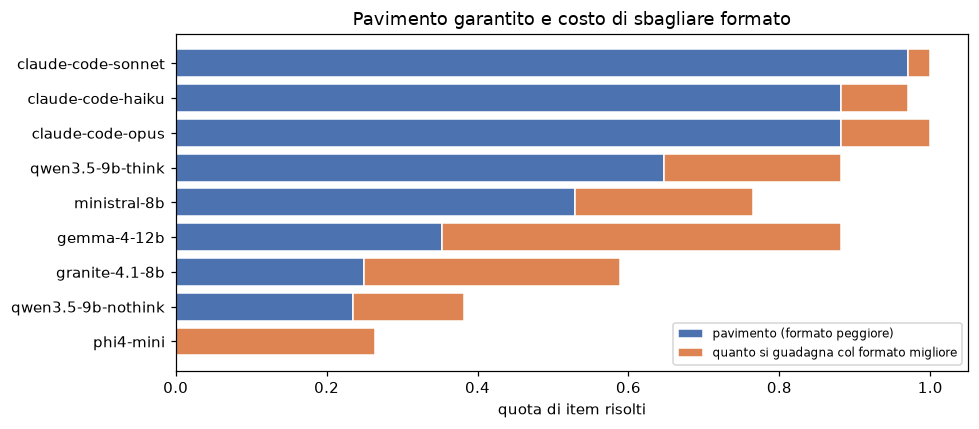

In [56]:
righe = []
for m in sorted(d3.model.unique()):
    g = d3[d3.model == m].groupby("rendering")["ok"].mean()
    righe.append({"modello": m, "formato migliore": g.idxmax(), "migliore": g.max(),
                  "formato peggiore": g.idxmin(), "pavimento garantito": g.min(),
                  "costo di sbagliare": g.max() - g.min()})
pav_g = pd.DataFrame(righe).sort_values("pavimento garantito", ascending=False)
print("Se non testi il formato e ne peschi uno a caso, cosa ti garantisce il modello?\n")
print(pav_g.round(3).to_string(index=False))
print()
_hp = pav_g[pav_g.modello == "claude-code-haiku"].iloc[0]
_hostp = pav_g[pav_g.modello.isin(HOSTED)]
_lp = pav_g[~pav_g.modello.isin(HOSTED)]
for _, r in _hostp.iterrows():
    print(f"{r['modello']:22s} pavimento {r['pavimento garantito']:.1%}, "
          f"sbagliare costa {r['costo di sbagliare']:.3f}")
print(f"Locali: pavimento da {_lp['pavimento garantito'].min():.1%} a "
      f"{_lp['pavimento garantito'].max():.1%}; sbagliare costa da "
      f"{_lp['costo di sbagliare'].min():.3f} a {_lp['costo di sbagliare'].max():.3f}.")
print()
_top_loc = _lp.nlargest(2, "migliore")
print("E un fatto che le altre tabelle nascondevano:")
for _, r in _top_loc.iterrows():
    print(f"  {r['modello']} con {r['formato migliore']} arriva a {r['migliore']:.3f} — "
          f"il pavimento di Haiku e' {_hp['pavimento garantito']:.3f}.")
print("Un modello locale, col formato giusto, tocca il livello che i bracci hosted")
print("raggiungono nel loro caso peggiore. Ma deve azzeccare il formato; loro no.")

fig, ax = plt.subplots(figsize=(9, 4))
o = pav_g.set_index("modello").sort_values("pavimento garantito")
y = np.arange(len(o))
ax.barh(y, o["pavimento garantito"], color="#4C72B0", edgecolor="white",
        label="pavimento (formato peggiore)")
ax.barh(y, o["costo di sbagliare"], left=o["pavimento garantito"], color="#DD8452",
        edgecolor="white", label="quanto si guadagna col formato migliore")
ax.set_yticks(y)
ax.set_yticklabels(o.index)
ax.set_xlabel("quota di item risolti")
ax.set_title("Pavimento garantito e costo di sbagliare formato")
ax.legend(fontsize=8, loc="lower right")
fig.tight_layout()

In [57]:
# Cosa se ne puo' concludere sui modelli non testati.
print("Il contrasto hosted / locali regge, ed e' corretto per il livello.")
print()
print("Fino al 2026-09-01 qui c'era un'ipotesi: che Sonnet e Opus si comportassero come")
print("Haiku. Poggiava su un punto solo, e il notebook la dichiarava come ipotesi di")
print("lavoro, non come conseguenza dei dati. Il 2026-09-02 e' stata misurata: due bracci")
print("in piu', 280 run ciascuno, stessa fixture e stesse coordinate.")
print()
print(scala[["tasso", "quality_rate medio"]].round(3).to_string())
print()
print("Esito: l'ipotesi tiene sul comportamento (piattezza sui formati, consegna sempre)")
print("e la scala si ferma prima di quanto ci si aspettasse — il terzo piolo non aggiunge")
print("niente al secondo. Restano tre modelli della stessa famiglia su UNA fixture:")
print("Fable, e ogni modello non-Anthropic, restano fuori dai dati.")
print()
n_haiku = int((df.model == "claude-code-haiku").sum())
print(f"Un braccio hosted costa {n_haiku} run: lo studio 3 cosi' com'e'.")

Il contrasto hosted / locali regge, ed e' corretto per il livello.

Fino al 2026-09-01 qui c'era un'ipotesi: che Sonnet e Opus si comportassero come
Haiku. Poggiava su un punto solo, e il notebook la dichiarava come ipotesi di
lavoro, non come conseguenza dei dati. Il 2026-09-02 e' stata misurata: due bracci
in piu', 280 run ciascuno, stessa fixture e stesse coordinate.

                    tasso  quality_rate medio
model                                        
claude-code-haiku   0.789               0.908
claude-code-sonnet  0.846               0.942
claude-code-opus    0.836               0.931

Esito: l'ipotesi tiene sul comportamento (piattezza sui formati, consegna sempre)
e la scala si ferma prima di quanto ci si aspettasse — il terzo piolo non aggiunge
niente al secondo. Restano tre modelli della stessa famiglia su UNA fixture:
Fable, e ogni modello non-Anthropic, restano fuori dai dati.

Un braccio hosted costa 280 run: lo studio 3 cosi' com'e'.


### 8.11 Due formalismi, non prosa contro struttura

Fin qui `prose-mechanical` e' stato trattato come "la prosa". Non lo e', ed e' una lettura
che nasconde il confronto piu' interessante del disegno.

`tests/scripts/build_prose_mechanical.py` sostituisce **solo la sezione di processo** del
documento e copia tutto il resto byte per byte, usando il renderer deterministico dello
skill. Il risultato ha la **stessa struttura** dello script SOL — stessi passi, stesse
condizioni, stesso ordine — scritta in linguaggio naturale invece che in JSON.

Quindi i tre bracci sono tre cose diverse:

| braccio | struttura | notazione |
|---|---|---|
| `L0` | quella di SOL | **JSON** |
| `prose-mechanical` | quella di SOL | **linguaggio naturale**, resa deterministica |
| `prose-generated` | riscritta da un modello, non garantita | linguaggio naturale |

E il percorso `L0 -> prose-mechanical -> prose-generated` diventa una **scomposizione**:
il primo passo isola l'effetto della sola **notazione** (stesso contenuto, stessa
struttura, cambia come e' scritta); il secondo isola l'effetto della **riscrittura** da
parte di un modello, sopra la stessa struttura.

In [58]:
Mn = d3.pivot_table(index=["model", "input_id"], columns="rendering",
                    values="ok", aggfunc="mean").dropna()
passi = [("notazione: JSON -> prosa strutturata", "L0", "prose-mechanical"),
         ("riscrittura: prosa strutturata -> prosa generata",
          "prose-mechanical", "prose-generated"),
         ("totale: JSON -> prosa generata", "L0", "prose-generated")]
righe = []
for nome, a, b in passi:
    diff = Mn[b] - Mn[a]
    _, p_ = ss.wilcoxon(Mn[b], Mn[a], zero_method="wilcox")
    se = diff.std(ddof=1) / np.sqrt(len(diff))
    righe.append({"passaggio": nome, "guadagno": diff.mean(),
                  "IC95 basso": diff.mean() - 1.96 * se,
                  "IC95 alto": diff.mean() + 1.96 * se, "p": p_})
scomp = pd.DataFrame(righe)
scomp["p Holm"] = multipletests(scomp.p, method="holm")[1]
print(f"Scomposizione, aggregato su {len(Mn)} blocchi (modello x item):\n")
print(scomp.round(4).to_string(index=False))
print()
_not, _riscr, _tot = scomp.guadagno.iloc[0], scomp.guadagno.iloc[1], scomp.guadagno.iloc[2]
print(f"Quota del guadagno totale dovuta alla sola NOTAZIONE:  {100*_not/_tot:.0f}%")
print(f"Quota dovuta alla RISCRITTURA del modello:             {100*_riscr/_tot:.0f}%")
print()
print("Entrambi i passaggi reggono da soli, ma il secondo e' al limite (p Holm "
      f"{scomp['p Holm'].iloc[1]:.3f}) e dipende dall'ampiezza della famiglia di test:")
print("con la famiglia piu' larga usata in 8.9.4 non passava. Il primo e' piu' saldo.")
print()
print("Il punto: NON e' la struttura a costare, e' la sintassi JSON. prose-mechanical ha")
print("la stessa struttura di SOL e cambia solo come e' scritta — e quel cambio da solo")
print("vale meta' del beneficio della conversione completa.")

Scomposizione, aggregato su 152 blocchi (modello x item):

                                       passaggio  guadagno  IC95 basso  IC95 alto      p  p Holm
            notazione: JSON -> prosa strutturata    0.0515     -0.0009     0.1040 0.0576  0.0576
riscrittura: prosa strutturata -> prosa generata    0.0789      0.0255     0.1324 0.0097  0.0193
                  totale: JSON -> prosa generata    0.1305      0.0737     0.1873 0.0000  0.0001

Quota del guadagno totale dovuta alla sola NOTAZIONE:  39%
Quota dovuta alla RISCRITTURA del modello:             61%

Entrambi i passaggi reggono da soli, ma il secondo e' al limite (p Holm 0.019) e dipende dall'ampiezza della famiglia di test:
con la famiglia piu' larga usata in 8.9.4 non passava. Il primo e' piu' saldo.

Il punto: NON e' la struttura a costare, e' la sintassi JSON. prose-mechanical ha
la stessa struttura di SOL e cambia solo come e' scritta — e quel cambio da solo
vale meta' del beneficio della conversione completa.


_wilcoxon.py:192: RuntimeWarning: invalid value encountered in scalar divide


Effetto della sola notazione (stesso contenuto, stessa struttura):

           modello  L0 (JSON)  prose-mechanical  guadagno      p  p Holm
       gemma-4-12b     0.4412            0.7941    0.3529 0.0139  0.1249
qwen3.5-9b-nothink     0.2353            0.3824    0.1471 0.1290  0.7739
         phi4-mini     0.0000            0.1471    0.1471 0.0253  0.2028
  qwen3.5-9b-think     0.7157            0.7647    0.0490 0.5785  1.0000
claude-code-sonnet     1.0000            1.0000    0.0000    NaN     NaN
    granite-4.1-8b     0.5312            0.5312    0.0000 1.0000  1.0000
 claude-code-haiku     0.9412            0.8824   -0.0588 0.1573  0.7865
      ministral-8b     0.5882            0.5294   -0.0588 0.3173  1.0000
  claude-code-opus     1.0000            0.8824   -0.1176 0.0455  0.3185

Segno positivo su 4 modelli su 9; nessuno regge la correzione da solo.
E' un fenomeno AGGREGATO, e il segnale sta quasi tutto in gemma-4-12b: +0.353 da un cambio di notazione a contenuto identico.

La 

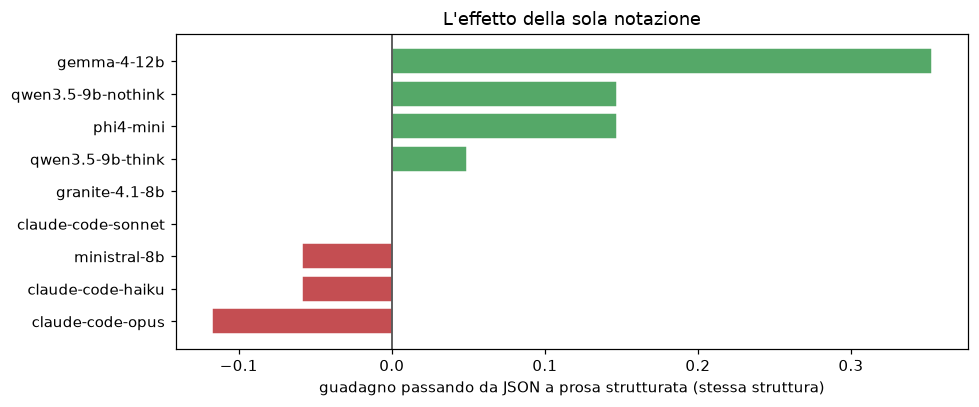

In [59]:
# --- L'effetto notazione, modello per modello ---
righe = []
for m in sorted(d3.model.unique()):
    Mm = d3[d3.model == m].pivot_table(index="input_id", columns="rendering",
                                       values="ok", aggfunc="mean").dropna()
    diff = Mm["prose-mechanical"] - Mm["L0"]
    try:
        _, p_ = ss.wilcoxon(Mm["prose-mechanical"], Mm["L0"], zero_method="wilcox")
    except ValueError:
        p_ = 1.0
    righe.append({"modello": m, "L0 (JSON)": Mm["L0"].mean(),
                  "prose-mechanical": Mm["prose-mechanical"].mean(),
                  "guadagno": diff.mean(), "p": p_})
notaz = pd.DataFrame(righe).sort_values("guadagno", ascending=False)
notaz["p Holm"] = multipletests(notaz.p, method="holm")[1]
print("Effetto della sola notazione (stesso contenuto, stessa struttura):\n")
print(notaz.round(4).to_string(index=False))
print()
print(f"Segno positivo su {int((notaz.guadagno > 0).sum())} modelli su {len(notaz)}; "
      "nessuno regge la correzione da solo.")
print("E' un fenomeno AGGREGATO, e il segnale sta quasi tutto in gemma-4-12b: "
      f"{notaz.guadagno.max():+.3f} da un cambio di notazione a contenuto identico.")
print()
_phi = notaz[notaz.modello == "phi4-mini"].iloc[0]
print(f"La riga di phi4-mini vale da sola: con L0 fa {_phi['L0 (JSON)']:.3f}, con la stessa")
print(f"identica procedura in prosa strutturata {_phi['prose-mechanical']:.3f}.")
print("Non e' che non sappia fare il compito: non sa leggere quella notazione.")

fig, ax = plt.subplots(figsize=(9, 3.8))
o = notaz.set_index("modello").sort_values("guadagno")
ax.barh(o.index, o["guadagno"],
        color=["#C44E52" if v < 0 else "#55A868" for v in o["guadagno"]], edgecolor="white")
ax.axvline(0, color="#333", lw=1)
ax.set_xlabel("guadagno passando da JSON a prosa strutturata (stessa struttura)")
ax.set_title("L'effetto della sola notazione")
fig.tight_layout()

### 8.12 «Il JSON e' quasi nativo per l'AI» — e la trappola di una regola bellissima

SOL usa JSON per un'ipotesi di progetto: che i modelli lo riconoscano e lo maneggino quasi
nativamente, piu' di YAML, XML o altre sintassi. La scomposizione di 8.11 permette di
metterla alla prova, perche' isola proprio il costo della notazione a struttura e contenuto
identici.

Se l'ipotesi valesse per alcuni modelli e non per altri, verrebbe naturale una regola
diagnostica: **misura la penalita' JSON di un modello, e saprai come somministrargli la
procedura**. Questa sezione la costruisce, la trova perfetta, e la demolisce — perche' e'
esattamente il tipo di risultato che sembra una scoperta ed e' un artefatto.

In [60]:
SOL_LV = ["L0", "L1", "L2", "L3", "L4"]

def diagnosi(fixture):
    dd_ = df[(df.fixture == fixture) & (~df.input_id.isin(pav.index))]
    out = {}
    for m in sorted(dd_.model.unique()):
        M = dd_[dd_.model == m].pivot_table(index="input_id", columns="rendering",
                                            values="ok", aggfunc="mean").dropna()
        g = M.mean()
        pen = M["prose-mechanical"].mean() - M["L0"].mean()
        out[m] = {"penalita JSON": pen, "predetto": "SOL" if pen <= 0 else "prosa",
                  "formato migliore": g.idxmax(),
                  "osservato": "SOL" if g.idxmax() in SOL_LV else "prosa"}
    t = pd.DataFrame(out).T
    t["penalita JSON"] = t["penalita JSON"].astype(float)
    t["azzecca"] = np.where(t.predetto == t.osservato, "si", "NO")
    return t

diag3 = diagnosi("support-routing-notrace")
diag2 = diagnosi("support-routing")
acc3 = (diag3.azzecca == "si").sum()
acc2 = (diag2.azzecca == "si").sum()
print("=== STUDIO 3 — dove la regola e' stata costruita ===")
print(diag3.round(3).to_string())
print(f"azzecca: {acc3}/{len(diag3)}")
print()
print("=== STUDIO 2 — verifica fuori campione ===")
print(diag2.round(3).to_string())
print(f"azzecca: {acc2}/{len(diag2)}")

=== STUDIO 3 — dove la regola e' stata costruita ===
                    penalita JSON predetto formato migliore osservato azzecca
claude-code-haiku          -0.059      SOL  prose-generated     prosa      NO
claude-code-opus           -0.118      SOL               L0       SOL      si
claude-code-sonnet          0.000      SOL               L0       SOL      si
gemma-4-12b                 0.353    prosa  prose-generated     prosa      si
granite-4.1-8b              0.000      SOL               L1       SOL      si
ministral-8b               -0.059      SOL               L2       SOL      si
phi4-mini                   0.147    prosa  prose-generated     prosa      si
qwen3.5-9b-nothink          0.147    prosa  prose-generated     prosa      si
qwen3.5-9b-think            0.049    prosa  prose-generated     prosa      si
azzecca: 8/9

=== STUDIO 2 — verifica fuori campione ===
                    penalita JSON predetto formato migliore osservato azzecca
gemma-4-12b                -0.08

In [61]:
# La quantita' su cui la regola poggia e' stabile fra i due studi?
cmp_ = pd.DataFrame({"studio 2": diag2["penalita JSON"],
                     "studio 3": diag3["penalita JSON"]}).dropna()
cmp_["stesso segno"] = np.where(np.sign(cmp_["studio 2"]) == np.sign(cmp_["studio 3"]),
                                "si", "NO")
rho_j, p_j = ss.spearmanr(cmp_["studio 2"], cmp_["studio 3"])
print("La penalita' JSON, misurata due volte sugli stessi 20 item e sugli stessi modelli:\n")
print(cmp_.round(3).to_string())
print(f"\nSpearman fra le due misure: rho={rho_j:.3f}  p={p_j:.4f}  (n={len(cmp_)})")
print(f"Stesso segno: {(cmp_['stesso segno'] == 'si').sum()}/{len(cmp_)}")
print()
print(f"La regola azzecca {acc3}/{len(diag3)} DENTRO il campione in cui e' stata costruita")
print(f"e {acc2}/{len(diag2)} FUORI. La penalita' su cui poggia cambia segno su "
      f"{(cmp_['stesso segno'] == 'NO').sum()} modelli su {len(cmp_)}.")
print()
print("Perche' il 7/7 non e' una scoperta: la penalita' (L0 contro prose-mechanical) e la")
print("famiglia vincente (massimo fra i sette) sono calcolate sugli STESSI 16 item. Se per")
print("un modello prose-mechanical batte L0, e' gia' piu' probabile che il massimo cada")
print("fra i formati in prosa. La corrispondenza e' quasi aritmetica, non predittiva.")
print()
print("Nota: studio 2 e studio 3 non differiscono solo per campionamento — il secondo ha il")
print("tracing tolto dai comandi. L'instabilita' potrebbe quindi essere un'INTERAZIONE fra")
print("notazione e tracing, non rumore. In entrambi i casi la conclusione non cambia: la")
print("penalita' JSON non e' una proprieta' del modello indipendente dal contesto.")

La penalita' JSON, misurata due volte sugli stessi 20 item e sugli stessi modelli:

                    studio 2  studio 3 stesso segno
gemma-4-12b           -0.088     0.353           NO
granite-4.1-8b         0.000     0.000           si
ministral-8b          -0.059    -0.059           si
phi4-mini              0.206     0.147           si
qwen3.5-9b-nothink    -0.118     0.147           NO
qwen3.5-9b-think      -0.029     0.049           NO

Spearman fra le due misure: rho=-0.143  p=0.7872  (n=6)
Stesso segno: 3/6

La regola azzecca 8/9 DENTRO il campione in cui e' stata costruita
e 4/6 FUORI. La penalita' su cui poggia cambia segno su 3 modelli su 6.

Perche' il 7/7 non e' una scoperta: la penalita' (L0 contro prose-mechanical) e la
famiglia vincente (massimo fra i sette) sono calcolate sugli STESSI 16 item. Se per
un modello prose-mechanical batte L0, e' gia' piu' probabile che il massimo cada
fra i formati in prosa. La corrispondenza e' quasi aritmetica, non predittiva.

Nota: st

In [62]:
# Cosa resta dell'ipotesi di progetto.
print("REGGE — 'il JSON e' quasi nativo' non vale per tutti.")
print(f"A parita' di struttura e contenuto, passare dal JSON alla resa in linguaggio")
print(f"naturale guadagna {scomp.guadagno.iloc[0]:+.3f} nell'aggregato "
      f"(p Holm {scomp['p Holm'].iloc[0]:.3f}), e su gemma-4-12b {notaz.guadagno.max():+.3f}.")
print("Se il JSON fosse letto nativamente da tutti, quel guadagno non esisterebbe.")
print()
print("REGGE — 'come somministrarla dipende dal modello'.")
print("Ma la strada per deciderlo NON e' stimare l'affinita' al JSON: quella misura non e'")
print("affidabile. E' misurare direttamente il formato migliore, che invece e' stabile")
print(f"({n_stab}/{len(stab)} modelli concordano fra i due studi, cfr. 8.10.2).")

REGGE — 'il JSON e' quasi nativo' non vale per tutti.
A parita' di struttura e contenuto, passare dal JSON alla resa in linguaggio
naturale guadagna +0.052 nell'aggregato (p Holm 0.058), e su gemma-4-12b +0.353.
Se il JSON fosse letto nativamente da tutti, quel guadagno non esisterebbe.

REGGE — 'come somministrarla dipende dal modello'.
Ma la strada per deciderlo NON e' stimare l'affinita' al JSON: quella misura non e'
affidabile. E' misurare direttamente il formato migliore, che invece e' stabile
(5/6 modelli concordano fra i due studi, cfr. 8.10.2).


### 8.13 Il formato migliore e' una proprieta' della coppia (modello, compito)

Fin qui il formato migliore e' stato trattato come una caratteristica del **modello**.
La campagna permette di controllarlo, perche' contiene due compiti diversi — `support-intake`
(una coda di 6-11 item per run) e `support-routing` (un item per run) — girati sugli stessi
sei modelli locali con gli stessi sette rendering.

Due confronti, uno dei quali fa da controllo:

- **stesso compito, studi separati**: `support-routing` contro `support-routing-notrace`;
- **compito diverso**: `support-intake` contro `support-routing`.

Se la preferenza fosse del modello, dovrebbero concordare entrambi. Se fosse della coppia
(modello, compito), solo il primo.

In [63]:
def miglior_formato(fixture):
    dd_ = df[df.fixture == fixture]
    if fixture != "support-intake":
        dd_ = dd_[~dd_.input_id.isin(pav.index)]
    val = "quality_rate" if fixture == "support-intake" else "ok"
    return dd_.groupby(["model", "rendering"])[val].mean().unstack().idxmax(axis=1)

coppie = pd.DataFrame({
    "compito A — intake": miglior_formato("support-intake"),
    "compito B — routing": miglior_formato("support-routing"),
    "compito B senza tracing": miglior_formato("support-routing-notrace"),
}).dropna()
stesso = int((coppie["compito B — routing"] == coppie["compito B senza tracing"]).sum())
diverso = int((coppie["compito A — intake"] == coppie["compito B — routing"]).sum())
n_mod = len(coppie)
print("Formato migliore per modello, per compito:\n")
print(coppie.to_string())
print()
print(f"STESSO compito, due studi separati : {stesso}/{n_mod} concordano")
print(f"COMPITO DIVERSO                    : {diverso}/{n_mod} concordano")
print()
# Sotto l'ipotesi nulla ogni modello sceglie a caso fra i sette formati.
p_stesso = ss.binom.sf(stesso - 1, n_mod, 1 / 7)
p_diverso = ss.binom.sf(diverso - 1, n_mod, 1 / 7)
print(f"Concordanze attese per puro caso (argmax fra 7): {n_mod/7:.2f}/{n_mod}")
print(f"  stesso compito  : p(>= {stesso} per caso) = {p_stesso:.5f}")
print(f"  compito diverso : p(>= {diverso} per caso) = {p_diverso:.3f}")
print()
print("Dentro lo stesso compito la preferenza e' reale e ripetibile. Cambiando compito la")
print("concordanza scende a quella del caso: e' come ricominciare da zero.")
print()
print("ministral-8b e phi4-mini si scambiano di posto — il primo da prose-generated a L2,")
print("il secondo da L2 a prose-generated. Non e' che uno 'preferisce la prosa' e l'altro")
print("'preferisce SOL': la preferenza si inverte col compito.")

Formato migliore per modello, per compito:

                   compito A — intake compito B — routing compito B senza tracing
model                                                                            
gemma-4-12b           prose-generated     prose-generated         prose-generated
granite-4.1-8b                     L0                  L1                      L1
ministral-8b          prose-generated                  L2                      L2
phi4-mini                          L2     prose-generated         prose-generated
qwen3.5-9b-nothink   prose-mechanical     prose-generated         prose-generated
qwen3.5-9b-think                   L1                  L3         prose-generated

STESSO compito, due studi separati : 5/6 concordano
COMPITO DIVERSO                    : 1/6 concordano

Concordanze attese per puro caso (argmax fra 7): 0.86/6
  stesso compito  : p(>= 5 per caso) = 0.00031
  compito diverso : p(>= 1 per caso) = 0.603

Dentro lo stesso compito la preferenza e' rea

In [64]:
# Conseguenza per chi deve usare SOL, non per chi scrive l'articolo.
print("NON ESISTE UNA TABELLA DI RACCOMANDAZIONI DA CONSULTARE.")
print()
print("Non 'gemma vuole la prosa', non 'usa la prosa sui modelli piccoli': la risposta")
print("vale per la coppia (modello, compito) che si ha davanti, e decade appena se ne")
print("cambia uno dei due. Va misurata sul posto.")
print()
print("Il che rende SOL utile per una ragione diversa dall'essere il formato migliore:")
print("e' l'unico punto da cui si generano TUTTE le forme dello stesso algoritmo. Una")
print("procedura scritta direttamente in prosa, per essere confrontata con le alternative,")
print("andrebbe riscritta — e a quel punto non si confrontano piu' notazioni ma documenti")
print("diversi, che e' esattamente l'errore che build_prose_mechanical.py evita")
print("sostituendo la sola sezione di processo.")

NON ESISTE UNA TABELLA DI RACCOMANDAZIONI DA CONSULTARE.

Non 'gemma vuole la prosa', non 'usa la prosa sui modelli piccoli': la risposta
vale per la coppia (modello, compito) che si ha davanti, e decade appena se ne
cambia uno dei due. Va misurata sul posto.

Il che rende SOL utile per una ragione diversa dall'essere il formato migliore:
e' l'unico punto da cui si generano TUTTE le forme dello stesso algoritmo. Una
procedura scritta direttamente in prosa, per essere confrontata con le alternative,
andrebbe riscritta — e a quel punto non si confrontano piu' notazioni ma documenti
diversi, che e' esattamente l'errore che build_prose_mechanical.py evita
sostituendo la sola sezione di processo.


## 9. Lo strato operativo

I capitoli precedenti misurano **quanto bene** un modello esegue il processo. Questo
capitolo misura una cosa che viene prima: **se arriva a eseguirlo**.

E' la parte della campagna che non compare in nessuna percentuale di resa, ma che ha
determinato quali modelli fossero utilizzabili: quantizzazione, finestra di contesto,
esecuzioni che non terminano. Su 8 GB di VRAM non e' un contorno, e' il presupposto.

Serve anche a leggere il resto: due configurazioni su sei perdono fra un terzo e i due
quinti delle esecuzioni **senza mai produrre una risposta**, e questo cambia la
graduatoria fra i modelli locali.

### 9.1 La frontiera operativa: le run che non consegnano

`degradation_mode` distingue *sbagliare* da *non arrivare*. Sono guasti diversi, e
chiedono rimedi opposti: al primo serve un formato migliore, al secondo finestra e meno
cerimonia. Sommarli in un unico tasso di fallimento nasconde la distinzione.

In [65]:
MUTI = ["no-output", "refused", "timeout"]
df["muto"] = df["degradation_mode"].isin(MUTI)

tab = pd.crosstab(df["model"], [df["studio"], df["muto"]])
tab_muti = tab.xs(True, level=1, axis=1)
tab_tot = tab.T.groupby(level=0).sum().T
quota = (tab_muti / tab_tot).fillna(0.0)

print("Run senza risposta utilizzabile (no-output | refused | timeout)")
print("conteggio / totale della cella, e quota:\n")
for m in quota.index:
    riga = "  ".join(
        f"{s}: {int(tab_muti.loc[m, s]):>3d}/{int(tab_tot.loc[m, s]):<3d} ({quota.loc[m, s]:.1%})"
        for s in quota.columns
    )
    print(f"{m:22s} {riga}")
print()
_mu_host = {m: int(tab_muti.loc[m].sum()) for m in HOSTED if m in tab_muti.index}
print(f"Bracci hosted, run senza risposta: {_mu_host} su "
      f"{int(tab_tot.loc[HOSTED].sum().sum())} run complessive.")
print("Sopra la frontiera lo strato operativo sparisce, e non su un modello solo.")

Run senza risposta utilizzabile (no-output | refused | timeout)
conteggio / totale della cella, e quota:

claude-code-haiku      1 — intake:   0/0   (0.0%)  2 — routing:   0/0   (0.0%)  3 — notrace:   0/280 (0.0%)
claude-code-opus       1 — intake:   0/0   (0.0%)  2 — routing:   0/0   (0.0%)  3 — notrace:   0/280 (0.0%)
claude-code-sonnet     1 — intake:   0/0   (0.0%)  2 — routing:   0/0   (0.0%)  3 — notrace:   0/280 (0.0%)
gemma-4-12b            1 — intake:   0/207 (0.0%)  2 — routing:   4/280 (1.4%)  3 — notrace:   0/280 (0.0%)
granite-4.1-8b         1 — intake:   2/189 (1.1%)  2 — routing:   1/276 (0.4%)  3 — notrace:   0/276 (0.0%)
ministral-8b           1 — intake:   1/207 (0.5%)  2 — routing:   0/280 (0.0%)  3 — notrace:   0/280 (0.0%)
phi4-mini              1 — intake:  77/210 (36.7%)  2 — routing:  25/280 (8.9%)  3 — notrace:  24/280 (8.6%)
qwen3.5-9b-nothink     1 — intake:   9/213 (4.2%)  2 — routing:  78/280 (27.9%)  3 — notrace:   0/280 (0.0%)
qwen3.5-9b-think       1 — i

In [66]:
# Composizione del guasto: sbagliare contro non arrivare.
comp = (df.groupby("model")["degradation_mode"]
          .value_counts(normalize=True).unstack().fillna(0.0))
ordine = [c for c in ["none", "wrong-value", "no-halt", "halt-not-taken",
                      "partial-sequence", "budget-drift", "no-output", "refused",
                      "timeout"] if c in comp.columns]
print("Composizione del modo di degradazione, per modello (quota sulle sue run):\n")
print((comp[ordine] * 100).round(1).to_string())

Composizione del modo di degradazione, per modello (quota sulle sue run):

degradation_mode    none  wrong-value  no-halt  halt-not-taken  partial-sequence  budget-drift  no-output  refused  timeout
model                                                                                                                      
claude-code-haiku   78.9         21.1      0.0             0.0               0.0           0.0        0.0      0.0      0.0
claude-code-opus    83.6         16.4      0.0             0.0               0.0           0.0        0.0      0.0      0.0
claude-code-sonnet  84.6         15.4      0.0             0.0               0.0           0.0        0.0      0.0      0.0
gemma-4-12b         28.8         42.2     16.0             1.3               8.3           2.7        0.5      0.0      0.0
granite-4.1-8b      28.9         65.0      0.7             1.9               0.1           3.0        0.3      0.1      0.0
ministral-8b        42.6         31.2     19.7           

### 9.2 La resa condizionata alla consegna

Se si separa *risponde male* da *non risponde*, la graduatoria fra i locali cambia. E'
la lettura che serve a chi deve mettere qualcosa in produzione: un modello che tace un
quarto delle volte non e' intercambiabile con uno che non tace mai, anche a parita' di
tasso grezzo.

In [67]:
rt = df[df.fixture.str.startswith("support-routing")]
rt = rt[~rt.model.isin(HOSTED)]

cond = rt.groupby("model").apply(lambda x: pd.Series({
    "resa grezza": x.ok.mean(),
    "resa se risponde": x.loc[~x.muto, "ok"].mean(),
    "quota muta": x.muto.mean(),
    "n": len(x),
})).sort_values("resa se risponde", ascending=False)
cond["n"] = cond["n"].astype(int)
print("Studi 2-3, soli modelli locali (i bracci hosted non tacciono mai):\n")
print(cond.round(3).to_string())
print()
print("qwen3.5-9b-think e ministral-8b hanno resa grezza quasi identica e NON sono")
print("intercambiabili: il primo e' il migliore dei locali quando parla, e tace un")
print("quarto delle volte; il secondo e' piu' debole e non tace mai.")

Studi 2-3, soli modelli locali (i bracci hosted non tacciono mai):

                    resa grezza  resa se risponde  quota muta    n
model                                                             
qwen3.5-9b-think          0.595             0.777       0.234  563
ministral-8b              0.584             0.584       0.000  560
gemma-4-12b               0.395             0.397       0.007  560
granite-4.1-8b            0.388             0.388       0.002  552
qwen3.5-9b-nothink        0.204             0.237       0.139  560
phi4-mini                 0.077             0.084       0.088  560

qwen3.5-9b-think e ministral-8b hanno resa grezza quasi identica e NON sono
intercambiabili: il primo e' il migliore dei locali quando parla, e tace un
quarto delle volte; il secondo e' piu' debole e non tace mai.


### 9.3 La finestra di contesto

`stop_reason = 'length'` marca le esecuzioni in cui la generazione si e' fermata perche'
ha esaurito lo spazio. E' l'unico punto della campagna in cui il vincolo hardware — 8 GB
di VRAM, e le quantizzazioni e i contesti scelti per starci dentro — si vede
direttamente nel dato.

In [68]:
loc = df[~df.model.isin(HOSTED)]
lung = loc[loc.stop_reason == "length"]
print(f"stop_reason = 'length': {len(lung)} run su {len(loc)} locali = {len(lung)/len(loc):.1%}")
print()
print(pd.crosstab(lung.model, lung.studio).to_string())
print()
print("gemma-4-12b non tocca mai il muro; qwen3.5-9b-think ci sbatte in tutti e tre gli")
print("studi. E' un fatto sulla coppia (modello, configurazione a 8 GB), non sui modelli")
print("in astratto: con un'altra scheda sarebbero altri numeri e altri modelli.")

stop_reason = 'length': 294 run su 4591 locali = 6.4%

studio              1 — intake  2 — routing  3 — notrace
model                                                   
granite-4.1-8b               3            1            0
ministral-8b                 6            0            1
phi4-mini                   21            8           16
qwen3.5-9b-nothink          28            0            0
qwen3.5-9b-think            81           79           50

gemma-4-12b non tocca mai il muro; qwen3.5-9b-think ci sbatte in tutti e tre gli
studi. E' un fatto sulla coppia (modello, configurazione a 8 GB), non sui modelli
in astratto: con un'altra scheda sarebbero altri numeri e altri modelli.


In [69]:
# Contro-intuitivo, e uccide un'ipotesi ovvia su L3/L4.
fin = loc.groupby("rendering").apply(lambda x: pd.Series({
    "quota length": (x.stop_reason == "length").mean(),
    "quota muta": x.muto.mean(),
    "token prompt (mediana)": x.tokens_in.median(),
    "token output (mediana)": x.tokens_out.median(),
}))
print("Troncamento e consegna, per rendering (soli locali):\n")
print(fin.round(3).to_string())
print()
print("I livelli che costano tre-quattro volte il prompt TRONCANO MENO, non di piu'.")
print("Qualunque cosa faccia perdere L3 e L4, non e' restare senza spazio per")
print("rispondere: e' un'ipotesi in meno da difendere, e rafforza l'argomento")
print("economico contro quei due bracci.")

Troncamento e consegna, per rendering (soli locali):

                  quota length  quota muta  token prompt (mediana)  token output (mediana)
rendering                                                                                 
L0                       0.090       0.115                  3161.0                   693.0
L1                       0.099       0.123                  3169.0                   826.0
L2                       0.073       0.091                  3578.0                   849.0
L3                       0.051       0.087                 10296.5                   896.0
L4                       0.040       0.102                 12257.0                   777.5
prose-generated          0.038       0.033                  3111.0                   596.0
prose-mechanical         0.058       0.113                  2954.0                   692.0

I livelli che costano tre-quattro volte il prompt TRONCANO MENO, non di piu'.
Qualunque cosa faccia perdere L3 e L4, non e' re

### 9.4 La geometria della coda, e il divario 1,5% contro 35,6%

Lo studio 1 chiede una coda intera; gli studi 2-3 un item per volta. Le due cifre che
si tende ad accostare — la quota di code risolte alla perfezione e la quota di item
risolti — **non hanno la stessa unita'**, e la maggior parte della loro distanza e'
aritmetica prima che sperimentale.

In [70]:
s1 = df[df.fixture == "support-intake"]
lung_coda = s1.groupby("input_id").n_expected_steps.first()
print("Lunghezza delle code (studio 1):\n")
print(lung_coda.astype(int).to_string())
print()
print(f"code distinte: {s1.input_id.nunique()}   min {lung_coda.min():.0f}   "
      f"max {lung_coda.max():.0f}   media {lung_coda.mean():.2f}")

Lunghezza delle code (studio 1):

input_id
queue-01     7
queue-02     9
queue-03    10
queue-04    11
queue-05    10
queue-06     6
queue-07     8
queue-08    10
queue-09     8
queue-10     8

code distinte: 10   min 6   max 11   media 8.70


In [71]:
p_item = s1.quality_rate.mean()
k = s1.n_expected_steps.mean()
coda_perfetta_lab = s1.ok.mean()
coda_perfetta_rate = (s1.quality_rate == 1.0).mean()
item_routing = df[(df.fixture == "support-routing") &
                  (~df.model.isin(HOSTED))].ok.mean()

print("Fra le due letture non c'e' un effetto: c'e' un ESPONENTE.\n")
print(f"  quota media di item corretti per coda      p = {p_item:.4f}")
print(f"  lunghezza media della coda                 k = {k:.2f}")
print(f"  se gli errori fossero indipendenti, p^k      = {p_item ** k:.4f}")
print(f"  code perfette osservate (etichetta)          = {coda_perfetta_lab:.4f}")
print(f"  code perfette osservate (quality_rate == 1)  = {coda_perfetta_rate:.4f}")
print(f"  item risolti nello studio 2 (locali)         = {item_routing:.4f}")
print()
print(f"La catena: {p_item:.3f} per item -> {p_item ** k:.3f} per sola composizione su")
print(f"~{k:.1f} decisioni consecutive -> {coda_perfetta_lab:.3f} osservato.")
print()
print("Quasi tutta la distanza e' il denominatore: chiedere ~9 decisioni tutte giuste")
print("invece di una. Il residuo (composizione -> osservato) e' cio' che resterebbe da")
print("attribuire, e fra i due banchi sono cambiate tre cose insieme (consegna,")
print("accumulo di stato, e un asse di decisione in piu' a caso singolo): non e'")
print("attribuibile a nessuna delle tre.")
print()
print("Sull'unita' piu' vicina a un confronto alla pari — la quota di item corretti —")
print(f"il banco a coda fa {p_item:.3f} contro {item_routing:.3f} del banco a caso")
print("singolo: il verso si rovescia. Con la cautela che 'item corretto' nella coda e")
print("'tutti e 8 i campi' a caso singolo non sono il medesimo criterio.")

Fra le due letture non c'e' un effetto: c'e' un ESPONENTE.

  quota media di item corretti per coda      p = 0.7324
  lunghezza media della coda                 k = 8.72
  se gli errori fossero indipendenti, p^k      = 0.0662
  code perfette osservate (etichetta)          = 0.0154
  code perfette osservate (quality_rate == 1)  = 0.0202
  item risolti nello studio 2 (locali)         = 0.3562

La catena: 0.732 per item -> 0.066 per sola composizione su
~8.7 decisioni consecutive -> 0.015 osservato.

Quasi tutta la distanza e' il denominatore: chiedere ~9 decisioni tutte giuste
invece di una. Il residuo (composizione -> osservato) e' cio' che resterebbe da
attribuire, e fra i due banchi sono cambiate tre cose insieme (consegna,
accumulo di stato, e un asse di decisione in piu' a caso singolo): non e'
attribuibile a nessuna delle tre.

Sull'unita' piu' vicina a un confronto alla pari — la quota di item corretti —
il banco a coda fa 0.732 contro 0.356 del banco a caso
singolo: il verso si r

### 9.5 Dove si rompe la coda, modello per modello

Il costrutto che porta stato fra un passo e l'altro — l'arresto — e' il modo di
fallimento piu' frequente dello studio 1 **sull'aggregato**. Ma non lo e' per tutti: su
tre modelli su sei e' quasi tutto il guasto, sugli altri tre e' marginale.

In [72]:
ARR = ["no-halt", "halt-not-taken"]
prof = (s1.groupby("model")["degradation_mode"]
          .value_counts(normalize=True).unstack().fillna(0.0))
prof["ARRESTO (somma)"] = prof[[c for c in ARR if c in prof.columns]].sum(axis=1)
cols = [c for c in ARR if c in prof.columns] + ["ARRESTO (somma)"] +        [c for c in ["wrong-value", "no-output", "partial-sequence", "refused"] if c in prof.columns]
print("Studio 1 — quota di ciascun modo sul totale delle run del modello:\n")
print((prof[cols] * 100).round(1).sort_values("ARRESTO (somma)", ascending=False).to_string())
print()
tot_arr = int(s1.degradation_mode.isin(ARR).sum())
print(f"Sull'aggregato l'arresto e' {tot_arr} run su {len(s1)} = "
      f"{tot_arr/len(s1):.1%}: il modo piu' frequente in assoluto.")
print()
print("Ma vale su 3 modelli su 6. granite-4.1-8b e phi4-mini sbagliano il VALORE,")
print("qwen3.5-9b-think NON CONSEGNA. 'Il fallimento e' l'arresto' e' una frase")
print("sull'aggregato, non sul modello medio — che non esiste.")

Studio 1 — quota di ciascun modo sul totale delle run del modello:

degradation_mode    no-halt  halt-not-taken  ARRESTO (somma)  wrong-value  no-output  partial-sequence  refused
model                                                                                                          
qwen3.5-9b-nothink     74.2            21.6             95.8          0.0        2.8               0.0      0.0
ministral-8b           72.9             3.9             76.8         15.9        0.5               6.8      0.0
gemma-4-12b            59.4             4.8             64.3          1.4        0.0              30.9      0.0
qwen3.5-9b-think        9.0             1.9             11.0         35.7       37.6               3.8      0.0
granite-4.1-8b          2.6             7.4             10.1         87.8        0.5               0.5      0.5
phi4-mini               1.0             0.0              1.0         61.9       29.0               0.5      7.6

Sull'aggregato l'arresto e' 540 run

In [73]:
# Il modo piu' istruttivo: individua il punto di arresto, lo scrive, e consegna
# comunque tutta la coda.
hnt = s1[s1.degradation_mode == "halt-not-taken"]
print(f"halt-not-taken: {len(hnt)} run su {len(s1)}")
print()
print(hnt.groupby("model").size().sort_values(ascending=False).to_string())
print()
print("Legge la regola 'fermati qui' come un fatto da riportare, non come un'uscita")
print("da prendere.")

halt-not-taken: 82 run su 1236



model
qwen3.5-9b-nothink    46
granite-4.1-8b        14
gemma-4-12b           10
ministral-8b           8
qwen3.5-9b-think       4

Legge la regola 'fermati qui' come un fatto da riportare, non come un'uscita
da prendere.


### 9.6 Studio 2, `gemma-4-12b`: l'insieme dei rami e' congelato

Domanda diversa da *quanti item risolve*: **su quali item imbocca il ramo giusto**, e se
quell'insieme cambi al crescere della documentazione allegata. E' leggibile solo dove il
tracing esiste, quindi solo nello studio 2 (`conditional_rate`).

In [74]:
g = df[(df.fixture == "support-routing") & (df.model == "gemma-4-12b")]
piv = g.groupby(["rendering", "input_id"]).conditional_rate.mean().unstack()
giusti = (piv == 1.0)
print("Item su cui il ramo condizionale e' corretto, per rendering:\n")
insiemi = {}
for r in giusti.index:
    items = sorted(giusti.columns[giusti.loc[r]].tolist())
    insiemi[r] = set(items)
    print(f"  {r:18s} n={len(items):2d}  {items}")
print()
base = insiemi["L0"]
identici = [r for r, s in insiemi.items() if s == base]
print(f"Insieme identico a L0 (non solo stesso conteggio): {len(identici)} rendering su "
      f"{len(insiemi)} — {sorted(identici)}")
for r, s in insiemi.items():
    if s != base:
        print(f"  {r}: aggiunge {sorted(s - base)}, toglie {sorted(base - s)}")
print()
print("Cinque livelli di documentazione e il renderer deterministico lasciano l'insieme")
print("INVARIATO. Solo la prosa generata lo rompe, e ci aggiunge due item.")
print()
print("Nota: due degli item a ramo corretto sono item a pavimento, che gemma sbaglia")
print("comunque. Ramo giusto e risposta giusta sono misure diverse.")

Item su cui il ramo condizionale e' corretto, per rendering:

  L0                 n= 8  ['r01', 'r02', 'r03', 'r06', 'r07', 'r08', 'r15', 'r20']
  L1                 n= 8  ['r01', 'r02', 'r03', 'r06', 'r07', 'r08', 'r15', 'r20']
  L2                 n= 8  ['r01', 'r02', 'r03', 'r06', 'r07', 'r08', 'r15', 'r20']
  L3                 n= 8  ['r01', 'r02', 'r03', 'r06', 'r07', 'r08', 'r15', 'r20']
  L4                 n= 8  ['r01', 'r02', 'r03', 'r06', 'r07', 'r08', 'r15', 'r20']
  prose-generated    n=10  ['r01', 'r02', 'r03', 'r06', 'r07', 'r08', 'r11', 'r15', 'r18', 'r20']
  prose-mechanical   n= 8  ['r01', 'r02', 'r03', 'r06', 'r07', 'r08', 'r15', 'r20']

Insieme identico a L0 (non solo stesso conteggio): 6 rendering su 7 — ['L0', 'L1', 'L2', 'L3', 'L4', 'prose-mechanical']
  prose-generated: aggiunge ['r11', 'r18'], toglie []

Cinque livelli di documentazione e il renderer deterministico lasciano l'insieme
INVARIATO. Solo la prosa generata lo rompe, e ci aggiunge due item.

Nota: due

### 9.7 Come falliscono i bracci hosted, e da dove viene il verdetto

Affermazione da maneggiare con cura, perche' la colonna che verrebbe naturale usare —
`fidelity` — nello studio 3 non porta informazione.

In [75]:
h3 = df[(df.fixture == "support-routing-notrace") & (df.model == "claude-code-haiku")]
for mod in HOSTED:
    g_ = df[(df.fixture == "support-routing-notrace") & (df.model == mod)]
    print(f"{mod:22s} run: {len(g_)}   pass: {int(g_.ok.sum())}   "
          f"fail: {int((~g_.ok.astype(bool)).sum())}   "
          f"degradation: {g_.degradation_mode.value_counts().to_dict()}")
print()
print("fidelity (TUTTE le run dello studio 3):",
      df[df.fixture == "support-routing-notrace"].fidelity.value_counts(dropna=False).to_dict())
print("sequence_rate nello studio 3 — max:",
      df[df.fixture == "support-routing-notrace"].sequence_rate.max())
print()
print("fidelity e' 'fail' su TUTTE le run dello studio 3, Haiku compreso, perche' lo")
print("studio 3 e' quello senza tracing: il controllo di sequenza non ha nulla da")
print("controllare. NON e' una misura di fedelta' in quello studio.")
print()
print("Il verdetto regge, ma poggia su degradation_mode: i fallimenti dei tre bracci sono")
print("tutti 'wrong-value'. Zero no-output, zero refused, zero partial-sequence, su 840")
print("run. Nessuno dei tre ha mai fallito la LETTURA del formato: hanno sbagliato il")
print("giudizio sul caso — e, per 42 fallimenti su 43 e 42 su 46, sugli stessi tre casi.")

claude-code-haiku      run: 280   pass: 221   fail: 59   degradation: {'none': 221, 'wrong-value': 59}
claude-code-sonnet     run: 280   pass: 237   fail: 43   degradation: {'none': 237, 'wrong-value': 43}
claude-code-opus       run: 280   pass: 234   fail: 46   degradation: {'none': 234, 'wrong-value': 46}

fidelity (TUTTE le run dello studio 3): {'fail': 2516, 'not_checkable': 3}
sequence_rate nello studio 3 — max: 0.0

fidelity e' 'fail' su TUTTE le run dello studio 3, Haiku compreso, perche' lo
studio 3 e' quello senza tracing: il controllo di sequenza non ha nulla da
controllare. NON e' una misura di fedelta' in quello studio.

Il verdetto regge, ma poggia su degradation_mode: i fallimenti dei tre bracci sono
tutti 'wrong-value'. Zero no-output, zero refused, zero partial-sequence, su 840
run. Nessuno dei tre ha mai fallito la LETTURA del formato: hanno sbagliato il
giudizio sul caso — e, per 42 fallimenti su 43 e 42 su 46, sugli stessi tre casi.


### 9.8 Le misure abbandonate

Alcune colonne sono vuote o costanti. Non sono guasti: sono strade di misura immaginate
all'inizio e non perseguite. Vanno dichiarate, perche' chi apre i dati grezzi le trova
comunque e perche' due affermazioni rischiano di poggiarci sopra senza dirlo.

In [76]:
righe = []
for c in ["expected_branch", "observed_branch", "comprehension_rate",
          "conditional_rate", "sequence_rate", "redundancy_ratio"]:
    if c not in df.columns:
        continue
    nn = df[c].notna().sum()
    per_studio = df.groupby("studio")[c].apply(lambda x: x.notna().sum()).to_dict()
    unici = df[c].dropna().nunique()
    righe.append({"colonna": c, "valorizzata su": f"{nn}/{len(df)}",
                  "valori distinti": unici,
                  **{f"studio {k.split(' ')[0]}": v for k, v in per_studio.items()}})
print(pd.DataFrame(righe).to_string(index=False))
print()
print("expected_branch / observed_branch: mai valorizzate. Il controllo di ramo non ha")
print("  prodotto valori in nessuno dei tre studi.")
print("comprehension_rate / conditional_rate: solo dove il tracing esiste.")
print("sequence_rate: costante a 0 nello studio 3 (vedi 9.7).")

           colonna valorizzata su  valori distinti  studio 1  studio 2  studio 3
comprehension_rate      1479/5431               30       643       836         0
  conditional_rate      1479/5431               46       643       836         0
     sequence_rate      5421/5431               85      1229      1676      2516
  redundancy_ratio      5421/5431               95      1229      1676      2516

expected_branch / observed_branch: mai valorizzate. Il controllo di ramo non ha
  prodotto valori in nessuno dei tre studi.
comprehension_rate / conditional_rate: solo dove il tracing esiste.
sequence_rate: costante a 0 nello studio 3 (vedi 9.7).


### 9.9 `L4` contro `L0`, cella per cella

Il conteggio esatto, perche' e' il tipo di numero che si cita a memoria e si sbaglia.

In [77]:
cells = []
for fx in ["support-routing", "support-routing-notrace"]:
    d_ = df[(df.fixture == fx) & (~df.model.isin(HOSTED))]
    p = d_.groupby(["model", "rendering"]).ok.mean().unstack()
    for m in p.index:
        cells.append({"studio": STUDIO[fx], "modello": m,
                      "L0": p.loc[m, "L0"], "L4": p.loc[m, "L4"],
                      "L4 - L0": p.loc[m, "L4"] - p.loc[m, "L0"]})
cd = pd.DataFrame(cells)
print(cd.round(3).to_string(index=False))
print()
peggio = int((cd["L4 - L0"] < 0).sum())
meglio = int((cd["L4 - L0"] > 0).sum())
pari = int((cd["L4 - L0"] == 0).sum())
print(f"Su {len(cd)} celle (6 configurazioni x 2 banchi a caso singolo): "
      f"{peggio} peggiora, {meglio} migliora, {pari} pari.")
print(f"Guadagno massimo {cd['L4 - L0'].max():+.3f}   "
      f"perdita massima {cd['L4 - L0'].min():+.3f}")
print()
print("L'asimmetria sta nell'AMPIEZZA, non nella frequenza. E nessuno di questi scarti")
print("regge il test testa a testa con Holm (cfr. 8.9): l'argomento contro L3/L4 e' il")
print("costo, non il danno.")

     studio            modello    L0    L4  L4 - L0
2 — routing        gemma-4-12b 0.375 0.300   -0.075
2 — routing     granite-4.1-8b 0.425 0.158   -0.267
2 — routing       ministral-8b 0.625 0.550   -0.075
2 — routing          phi4-mini 0.000 0.050    0.050
2 — routing qwen3.5-9b-nothink 0.150 0.125   -0.025
2 — routing   qwen3.5-9b-think 0.575 0.575    0.000
3 — notrace        gemma-4-12b 0.375 0.300   -0.075
3 — notrace     granite-4.1-8b 0.425 0.211   -0.214
3 — notrace       ministral-8b 0.500 0.625    0.125
3 — notrace          phi4-mini 0.000 0.000    0.000
3 — notrace qwen3.5-9b-nothink 0.200 0.225    0.025
3 — notrace   qwen3.5-9b-think 0.610 0.575   -0.035

Su 12 celle (6 configurazioni x 2 banchi a caso singolo): 7 peggiora, 3 migliora, 2 pari.
Guadagno massimo +0.125   perdita massima -0.267

L'asimmetria sta nell'AMPIEZZA, non nella frequenza. E nessuno di questi scarti
regge il test testa a testa con Holm (cfr. 8.9): l'argomento contro L3/L4 e' il
costo, non il danno.


### 9.10 Classificare e' molto piu' facile che eseguire

Nello studio 1 il tracing espone il passo di classificazione separatamente dall'esito
complessivo. Le due cose non si somigliano.

In [78]:
sub = s1[s1.comprehension_rate.notna()]
r_all = (s1.comprehension_rate == 1).mean() / s1.ok.mean()
r_sub = (sub.comprehension_rate == 1).mean() / sub.ok.mean()
print(f"Sul sottoinsieme dove la classificazione e' leggibile (n={len(sub)}):")
print(f"  etichetta tutte le richieste correttamente : {(sub.comprehension_rate == 1).mean():.4f}")
print(f"  risolve l'intera coda                      : {sub.ok.mean():.4f}")
print(f"  rapporto                                   : {r_sub:.2f}x")
print()
print(f"Su tutto il banco (n={len(s1)}):")
print(f"  etichetta tutte le richieste correttamente : {(s1.comprehension_rate == 1).mean():.4f}")
print(f"  risolve l'intera coda                      : {s1.ok.mean():.4f}")
print(f"  rapporto                                   : {r_all:.2f}x")
print()
print("La selezione ha un verso: quelle righe le emette chi il protocollo non ha")
print("strozzato, quindi il sottoinsieme e' fatto dei modelli che se la cavavano")
print("meglio. Vanno riportati entrambi i denominatori.")

Sul sottoinsieme dove la classificazione e' leggibile (n=643):


  etichetta tutte le richieste correttamente : 0.1011
  risolve l'intera coda                      : 0.0140
  rapporto                                   : 7.22x

Su tutto il banco (n=1236):
  etichetta tutte le richieste correttamente : 0.0526
  risolve l'intera coda                      : 0.0154
  rapporto                                   : 3.42x

La selezione ha un verso: quelle righe le emette chi il protocollo non ha
strozzato, quindi il sottoinsieme e' fatto dei modelli che se la cavavano
meglio. Vanno riportati entrambi i denominatori.


## 10. Fact Sheet

Il foglio unico. Generato da questo notebook: non si scrive a mano e non si aggiorna a
mano, si rigenera.

In [79]:
from datetime import datetime, timezone

def pct(x):
    return f"{100 * x:.1f}%"

L = []
A = L.append
A("# SOL — Fact Sheet della campagna principale")
A("")
A(f"Generato da `report/analysis/01_fatti.ipynb` il {datetime.now(timezone.utc):%Y-%m-%d}.")
A("Sorgente: `report/analysis/tidy.csv`, costruita da `load_raw.py` sugli artefatti grezzi")
A("`tests/results-main/**/*.score.json`.")
A("**Non modificare a mano: rigenerare eseguendo il notebook.**")
A("")
A("> Fatti descrittivi con la loro N e il loro intervallo (capitoli 1-7 del notebook),")
A("> e i test appaiati sull'item (capitolo 8). Ogni affermazione di significativita' e'")
A("> accompagnata dal test che la regge e dall'ampiezza dell'effetto.")
A("")
A("## Il disegno")
A("")
A("Tre studi in sequenza, non un fattoriale. **Nessuna media attraversa gli studi.**")
A("")
A("| studio | fixture | unita' | misura | run |")
A("|---|---|---|---|---:|")
A(f"| 1 | `support-intake` | la coda (6-11 item) | quota di item corretti sulla coda | {len(s1)} |")
A(f"| 2 | `support-routing` | l'item (1 per run) | 8 campi per item, `pass` = tutti e 8 | "
  f"{int((df.studio=='2 — routing').sum())} |")
A(f"| 3 | `support-routing-notrace` | l'item (1 per run) | come 2, senza misure di traccia | "
  f"{int((df.studio=='3 — notrace').sum())} |")
A("")
A("Lo studio 3 nasce da un ritrovamento dello studio 2: il tracing nei comandi aveva un "
  "effetto suo. Toglierlo costa `comprehension_rate` e `conditional_rate` (assenti al 100% "
  "nello studio 3) e in cambio da' un dato di successo pulito. Su quella configurazione, "
  "e solo su quella, sono stati somministrati anche i tre bracci **hosted** — "
  "`claude-code-haiku` (2026-08-31), `claude-code-sonnet` e `claude-code-opus` "
  "(2026-09-02), 280 run ciascuno: stessi item, stessi rendering, stesse repliche, stesso "
  "oracolo, e come unica coordinata mobile l'id del modello.")
A("")
A("## Qualita' del dato")
A("")
A(f"- **`tests/results-main/index.csv` diverge dai punteggi grezzi su {n_dis} run** "
  f"({pct(n_dis/len(df))}): e' un derivato rigenerato in un momento diverso dalla "
  "valutazione. Non usarlo come sorgente — questo foglio legge i `.score.json`.")
A("- **`expected_branch` / `observed_branch` sono vuoti su tutte le righe**: il controllo "
  "di ramo non ha mai prodotto valori, e il verdetto `fidelity` poggia solo su "
  "`sequence_rate`.")
A(f"- **Disegno sbilanciato fra studi**: le celle modello x rendering vanno da "
  f"{n_cell.min()} a {n_cell.max()} run. Dentro gli studi 2-3 invece il disegno e' pieno "
  "e appaiato (20 item per condizione).")
A(f"- **{n_dup} run hanno (cella, replica) duplicato** ({pct(n_dup/len(df))}): "
  "ri-esecuzioni aggiunte in coda, non sostituzioni. Restano nel dataset.")
A("- **`degradation_mode` non e' una misura indipendente**: e' l'etichetta della causa del "
  "fallimento e coincide con `quality` (`none` <-> `pass`). Citarli come due risultati "
  "distinti dice due volte la stessa cosa.")
A("")
A("### Dove taglia l'etichetta `quality`")
A("")
A("- `quality = pass` significa **`quality_rate == 1.0` esatto**: perfetto, non buono.")
A(f"- I run etichettati `fail` hanno quality_rate medio "
  f"**{df.loc[df.quality=='fail','quality_rate'].mean():.3f}** "
  f"(mediana {df.loc[df.quality=='fail','quality_rate'].median():.3f}): il fallimento "
  "medio ha circa due terzi del lavoro corretto.")
A(f"- Su `fidelity` il quadro e' opposto: i `fail` hanno sequence_rate medio "
  f"**{df.loc[df.fidelity=='fail','sequence_rate'].mean():.3f}**, quasi zero. "
  "Le due etichette `fail` non significano la stessa cosa e non vanno sommate.")
A("")
A("## Studio 1 — intake")
A("")
A(f"{len(s1)} run su {s1.input_id.nunique()} code, {s1.model.nunique()} modelli, "
  f"{s1.rendering.nunique()} rendering.")
A("")
A(f"- Quota media di item corretti per coda: **{s1.quality_rate.mean():.3f}** "
  f"(mediana {s1.quality_rate.median():.3f}).")
A(f"- Code risolte **alla perfezione**: **{s1.ok.mean():.1%}**.")
A("")
A("Le due letture distano ~50 punti sulla stessa campagna: la prima dice quanto lavoro il "
  "modello fa bene, la seconda quante volte lo fa *tutto* bene. Vanno riportate insieme.")
A("")
A("| modello | quota media di item corretti | n run |")
A("|---|---:|---:|")
for m, r in (s1.groupby("model").agg(q=("quality_rate", "mean"), n=("run_id", "size"))
             .sort_values("q", ascending=False).iterrows()):
    A(f"| `{m}` | {r['q']:.3f} | {int(r['n'])} |")
A("")
A("## Studi 2-3 — routing, un item per volta")
A("")
A(f"{len(s23)} run su **{s23.input_id.nunique()} item** (`r01`..`r20`), esito binario per "
  "item. Disegno **appaiato**: ogni condizione (studio x modello x rendering) vede tutti "
  "e 20 gli item.")
A("")
A(f"### Item a pavimento — {len(pav)} su {len(it)}")
A("")
A("Item che nessun modello, in nessun rendering, risolve piu' del 5% delle volte:")
A("")
A("| item | successi | run | tasso | IC95 |")
A("|---|---:|---:|---:|---|")
for i, r in pav.iterrows():
    A(f"| `{i}` | {int(r['successi'])} | {int(r['run'])} | {r['tasso']:.3f} | "
      f"[{r['IC95 basso']:.3f}, {r['IC95 alto']:.3f}] |")
A("")
A(f"Sono il {100*len(pav)/len(it):.0f}% del denominatore e tolgono la stessa quota a tutte "
  "le condizioni: non misurano il trattamento, misurano l'item. Vanno riportati a parte.")
A("")
A(f"Escursione fra item: dal {it['tasso'].min():.1%} (`{it['tasso'].idxmin()}`) "
  f"al {it['tasso'].max():.1%} (`{it['tasso'].idxmax()}`).")
A("")
A("### Quota di item risolti, per modello")
A("")
A("| modello | studio 2 | studio 3 | scarto |")
A("|---|---:|---:|---:|")
for m, r in tr_m.iterrows():
    A(f"| `{m}` | {r['2 — routing']:.3f} | {r['3 — notrace']:.3f} | {r['scarto']:+.3f} |")
A("")
A(f"Complessivo sui soli modelli locali: studio 2 = **{agg.loc['2 — routing','tasso']:.3f}** "
  f"(IC95 [{agg.loc['2 — routing','IC95 basso']:.3f}, "
  f"{agg.loc['2 — routing','IC95 alto']:.3f}], n={int(agg.loc['2 — routing','run'])}), "
  f"studio 3 = **{agg.loc['3 — notrace','tasso']:.3f}** "
  f"(IC95 [{agg.loc['3 — notrace','IC95 basso']:.3f}, "
  f"{agg.loc['3 — notrace','IC95 alto']:.3f}], n={int(agg.loc['3 — notrace','run'])}).")
A("")
A(f"**{su} modelli salgono, {giu} scendono.** Il complessivo e' la somma di due gruppi che "
  "vanno in direzioni opposte, non un effetto condiviso da tutti.")
A("")
A(f"Tolti i {len(pav)} item a pavimento (denominatore {n_vivi} invece di 20), studio 3:")
A("")
A("| modello | su 20 item | su " + str(n_vivi) + " item |")
A("|---|---:|---:|")
for m, r in confronto["3 — notrace"].iterrows():
    A(f"| `{m}` | {r['su 20 item']:.3f} | {r[f'su {n_vivi} item']:.3f} |")
A("")
A("## Studio 3 — la scala hosted")
A("")
A("Tre bracci sulla stessa fixture, stessi venti item, stessi sette rendering, stesse due "
  "repliche. Fra loro si muove solo l'id del modello.")
A("")
A("| braccio | item risolti | run | tasso | IC95 | `quality_rate` medio |")
A("|---|---:|---:|---:|---|---:|")
for _m, _r in scala.iterrows():
    A(f"| `{_m}` | {int(_r['risolti'])} | {int(_r['run'])} | **{_r['tasso']:.3f}** | "
      f"[{_r['IC95 basso']:.3f}, {_r['IC95 alto']:.3f}] | {_r['quality_rate medio']:.3f} |")
A(f"| sei celle locali, pooled | {int(locali3.ok.sum())} | {len(locali3)} | "
  f"{locali3.ok.mean():.3f} | — | {locali3.quality_rate.mean():.3f} |")
A("")
A(f"**Da haiku a sonnet {d_hs:+.3f}; da sonnet a opus {d_so:+.3f}**, cioe' {n_so:.0f} run "
  f"su {int(scala.loc['claude-code-opus','run'])}. Il salto sta fra le celle locali e il "
  "primo braccio hosted; lungo la scala hosted il terzo piolo non aggiunge niente al "
  "secondo. **Il tetto di questo compito e' misurato, e non e' 1.0.**")
A("")
A("### Profilo sui sette rendering, braccio per braccio")
A("")
A("| rendering | " + " | ".join(f"`{m}`" for m in HOSTED) + " |")
A("|---|" + "---:|" * len(HOSTED))
for _r in sorted(hosted_prof[HOSTED[0]].index):
    A(f"| `{_r}` | " + " | ".join(f"{hosted_prof[m].loc[_r, 'tasso']:.3f}"
                                     for m in HOSTED) + " |")
A("| **escursione** | " + " | ".join(
    f"**{escursioni.loc[m, 'escursione']:.3f}**" for m in HOSTED) + " |")
A("| ampiezza IC 95% media | " + " | ".join(
    f"{escursioni.loc[m, 'ampiezza IC medio']:.3f}" for m in HOSTED) + " |")
A("")
A("Su tutti e tre l'escursione fra formati e' **piu' stretta dell'incertezza sulla singola "
  "condizione** e gli intervalli si sovrappongono: coerente con l'ipotesi che sopra la "
  "frontiera i formati non facciano differenza. Con un braccio solo era una proprieta' di "
  "quel modello; con tre e' una proprieta' del compito a quel livello di resa.")
A("")
A("### Dove stanno i fallimenti")
A("")
A("| item | " + " | ".join(f"`{m}`" for m in HOSTED) + " |")
A("|---|" + "---:|" * len(HOSTED))
for _i, _r in falliti.sort_values(HOSTED, ascending=False).iterrows():
    A(f"| `{_i}` | " + " | ".join(f"{int(_r[m])}/14" for m in HOSTED) + " |")
A("")
A(f"**{', '.join('`'+i+'`' for i in sempre)} sbagliano 14 volte su 14 su tutti e tre i "
  f"bracci**, e da soli spiegano " + ", ".join(
      f"il {100*quota_sempre[m]:.0f}% dei fallimenti di `{m}`" for m in HOSTED) + ".")
A("")
A("Non e' rumore stocastico e non lo muove nessun contesto collaterale: e' lo stesso "
  "disaccordo sul *che cosa sia* la richiesta, ripetuto identico da modelli che distano un "
  "fattore trenta di taglia. Cio' che la scala compra e' la coda — gli item che un braccio "
  "sbaglia qualche volta — non quei tre.")
A("")
A("Escursione fra rendering, modello per modello (studio 3):")
A("")
A("| modello | min | max | escursione | media | sd attesa |")
A("|---|---:|---:|---:|---:|---:|")
for m, r in esc.iterrows():
    A(f"| `{m}` | {r['min']:.3f} | {r['max']:.3f} | {r['escursione']:.3f} | "
      f"{r['mean']:.3f} | {r['sd attesa']:.3f} |")
A("")
A("**Le escursioni non sono confrontabili fra modelli a livelli diversi.** Con un esito "
  "binario la variabilita' e' massima intorno a 0.5 e si schiaccia ai bordi (colonna "
  "`sd attesa`). Haiku e `phi4-mini` stanno entrambi vicino a un bordo: parte della loro "
  "escursione stretta e' il soffitto o il pavimento, non l'indifferenza al formato.")
A("")
A("## Costo")
A("")
costo_tot = df[["wall_clock_ms", "tokens_in", "tokens_out"]].describe(percentiles=[.5, .95]).T
A("| misura | media | mediana | p95 | max |")
A("|---|---:|---:|---:|---:|")
for k, r in costo_tot.iterrows():
    A(f"| {k} | {r['mean']:.0f} | {r['50%']:.0f} | {r['95%']:.0f} | {r['max']:.0f} |")
A("")
A("Distribuzioni fortemente asimmetriche: citare la mediana, non la media.")
A("")
A("## Differenze verificate")
A("")
A("Tutti i test sono **appaiati sull'item**: la difficolta' dell'item esce dal confronto "
  f"invece di gonfiarlo. alpha = {ALPHA}. Soglia di equivalenza fissata **a priori** a "
  f"**{MARGINE}** (dieci punti percentuali), su criterio pratico: sotto quella soglia la "
  "scelta del formato non cambierebbe una decisione in un caso d'uso reale.")
A("")
A("### Togliere il tracing (studio 2 -> studio 3)")
A("")
A("Wilcoxon dei ranghi con segno, appaiato su `rendering x item`, soli modelli locali.")
A("")
A("| modello | studio 2 | studio 3 | differenza | IC95 | p | esito |")
A("|---|---:|---:|---:|---|---:|---|")
for _, r in trac.iterrows():
    A(f"| `{r['modello']}` | {r['studio 2']:.3f} | {r['studio 3']:.3f} | "
      f"{r['differenza']:+.3f} | [{r['IC95 basso']:+.3f}, {r['IC95 alto']:+.3f}] | "
      f"{r['p']:.3g} | {r['esito']} |")
A("")
A(f"**{n_sale} modelli salgono in modo significativo, {n_scende} scendono, "
  f"{n_nulla} restano senza conclusione** ({n_giu_desc} dei quali descrittivamente in "
  "calo, ma il test non lo conferma).")
A("")
A("Da leggere con precisione: i test **non** dimostrano un effetto in due direzioni "
  "opposte. Dimostrano un effetto positivo su una parte dei modelli e nessun effetto "
  "dimostrato sugli altri — un calo descrittivo che il test non conferma non e' un calo. "
  "Resta vero che l'effetto **non e' uniforme**: il complessivo che media tutti i modelli "
  "descrive un modello medio che non esiste.")
A("")
A("### Il rendering conta, a modello fissato? (studio 3)")
A("")
A("Friedman sui 20 item x 7 rendering. Kendall's W e' l'ampiezza: 0 = gli item non "
  "concordano su quale rendering sia migliore, 1 = lo ordinano tutti allo stesso modo.")
A("")
A("| modello | chi2 | p | Kendall W | migliore | peggiore | escursione | esito |")
A("|---|---:|---:|---:|---|---|---:|---|")
for _, r in fried.iterrows():
    A(f"| `{r['modello']}` | {r['chi2']:.1f} | {r['p']:.3g} | {r['Kendall W']:.3f} | "
      f"`{r['migliore']}` | `{r['peggiore']}` | {r['escursione']:.3f} | {r['esito']} |")
A("")
A(f"Il rendering risulta significativo su **{int((fried.p < ALPHA).sum())} modelli su "
  f"{len(fried)}**.")
A("")
A("### I bracci hosted sono indifferenti ai formati? — test di equivalenza")
A("")
A(f"TOST appaiato su tutte le {haiku_tot} coppie di rendering, margine ±{MARGINE}, sui "
  f"{haiku_n} item non a pavimento. Equivalenza dichiarata solo se **ogni** coppia rientra "
  "nella soglia (test a intersezione-unione: conservativo, nessuna correzione per "
  "confronti multipli necessaria).")
A("")
A(f"- Coppie equivalenti entro ±{MARGINE}: **{haiku_ok} su {haiku_tot}**.")
A(f"- Coppia piu' lontana dall'equivalenza: `{haiku_peggio['coppia']}` "
  f"(differenza {haiku_peggio['differenza']:+.3f}, p TOST = {haiku_peggio['p TOST']:.4f}).")
A(f"- **Verdetto: {haiku_verdetto}.**")
A("")
A("Lo stesso test sugli altri due bracci, che l'ipotesi la mettono alla prova invece di "
  "averla generata:")
A("")
A("| braccio | coppie equivalenti | diff max | verdetto |")
A("|---|---:|---:|---|")
for _m in HOSTED:
    _d = hosted_tost[_m]
    A(f"| `{_m}` | {_d['ok']}/{_d['coppie']} | "
      f"{_d['tost'].differenza.abs().max():.3f} | {_d['verdetto']} |")
A("")
A(f"Il test gira anche sui 20 item completi: i {len(pav)} item a pavimento danno "
  "differenza zero in ogni coppia e quindi restringono la varianza, rendendo "
  f"l'equivalenza *piu' facile* da dichiarare. Vale la lettura sui {n_vivi} item, "
  "riportata qui.")
A("")
A("Lo stesso test su tutti i modelli:")
A("")
A("| modello | quota media | coppie equivalenti | diff max | p Friedman | verdetto |")
A("|---|---:|---:|---:|---:|---|")
for _, r in tost.iterrows():
    A(f"| `{r['modello']}` | {r['media']:.3f} | {int(r['equivalenti'])}/{int(r['coppie'])} | "
      f"{r['diff max']:.3f} | {r['p Friedman']:.3g} | {r['verdetto']} |")
A("")
A("Friedman e TOST rispondono a due domande diverse — *c'e' una differenza?* e *la "
  "differenza e' abbastanza piccola da non contare?* — e possono dire **entrambi no**: "
  "significa che i dati non bastano a decidere in nessuna direzione, non che l'effetto "
  "sia nullo.")
A("")
A("### Quanti item servirebbero per decidere")
A("")
A(f"Sulla coppia piu' lontana dall'equivalenza di ciascun modello, potenza 0.80, "
  f"margine ±{MARGINE}:")
A("")
A("| modello | item ora | coppia peggiore | differenza | item necessari |")
A("|---|---:|---|---:|---|")
for _, r in potenza.iterrows():
    if np.isnan(r["item necessari"]):
        serve = f"— *{r['nota']}*"
    elif r["item necessari"] == 0:
        serve = "già deciso"
    else:
        serve = f"~{int(r['item necessari'])}"
    A(f"| `{r['modello']}` | {int(r['item ora'])} | `{r['coppia peggiore']}` | "
      f"{r['differenza']:+.3f} | {serve} |")
A("")
A("Dove la differenza osservata supera gia' il margine, nessun campione la rende "
  "equivalente: li' la risposta non e' *servono piu' dati*, e' **il formato conta**.")
A("")
A("### C'e' un formato migliore e uno peggiore, in generale?")
A("")
A("Blocco = **(modello, item)**: ogni blocco vede tutti e sette i rendering sullo stesso "
  "item con lo stesso modello. Friedman per la domanda d'insieme, confronti appaiati con "
  "correzione di Holm per il dettaglio. La verifica gira sui **tre studi**.")
A("")
A("| studio | blocchi | migliore | peggiore | Friedman p | Kendall W |")
A("|---|---:|---|---|---:|---:|")
for st, c in classifica.items():
    A(f"| {st} | {c['n']} | `{c['tab'].index[-1]}` ({c['tab']['media'].iloc[-1]:.3f}) | "
      f"`{c['tab'].index[0]}` ({c['tab']['media'].iloc[0]:.3f}) | {c['p']:.3g} | "
      f"{c['W']:.3f} |")
A("")
A("Media per formato, studio per studio (dal peggiore al migliore):")
A("")
A("| formato | studio 1 | studio 2 | studio 3 |")
A("|---|---:|---:|---:|")
_ord = classifica["3 — notrace"]["tab"].index
for r_ in _ord:
    celle = []
    for st in ["1 — intake", "2 — routing", "3 — notrace"]:
        v = classifica[st]["tab"]["media"]
        celle.append(f"{v[r_]:.3f}" if r_ in v.index else "—")
    A(f"| `{r_}` | " + " | ".join(celle) + " |")
A("")
A(f"Lo studio 1 **non e' significativo** (Friedman p = {classifica['1 — intake']['p']:.3g} "
  f"su {classifica['1 — intake']['n']} blocchi, che vengono da sole 10 code): li' "
  "l'ordinamento e' solo descrittivo, e vale come conferma di direzione, non come prova. "
  "Le due affermazioni sotto sono **verificate sugli studi 2 e 3**, e lo studio 1 le "
  "accompagna senza contraddirle.")
A("")
A("**Due affermazioni reggono:**")
A("")
_pg3 = posthoc_res[("3 — notrace", "prose-generated")]
_l43 = posthoc_res[("3 — notrace", "L4")]
_pm3 = posthoc_res[("3 — notrace", "prose-mechanical")]
A(f"- **`prose-generated` e' il migliore.** Nello studio 3 batte **tutti e sei** gli altri "
  f"formati con correzione di Holm ({int((_pg3.esito=='MEGLIO').sum())}/6), con differenze "
  f"da {_pg3.differenza.min():+.3f} a {_pg3.differenza.max():+.3f}. E' il risultato piu' "
  "solido della campagna. Media piu' alta anche negli studi 1 e 2.")
A(f"- **`L4` e' il peggiore.** Media piu' bassa in tutti e tre gli studi; "
  f"significativamente peggio di {int((_l43.esito=='PEGGIO').sum())} formati su 6 nello "
  f"studio 3 e di {int((posthoc_res[('2 — routing','L4')].esito=='PEGGIO').sum())} nello "
  "studio 2. Affermazione piu' debole della precedente: in entrambi gli studi il formato "
  "che lo batte in modo significativo e' soprattutto `prose-generated`, mentre lo scarto "
  "dagli altri `Ln` non supera la soglia.")
A("")
A("**Una affermazione NON regge: che `prose-mechanical` sia il formato peggiore.** "
  f"E' 2° su 7 nello studio 1, 5° nello studio 2, 2° nello studio 3. Nello studio 3 e' "
  f"significativamente **migliore** di `L4` ({_pm3.loc[_pm3.vs=='L4','differenza'].iloc[0]:+.3f}, "
  f"Holm p = {_pm3.loc[_pm3.vs=='L4','p Holm'].iloc[0]:.3f}) e non e' peggiore di nessun "
  f"altro formato. Sui {d3.model.nunique()} modelli dello studio 3 risulta il peggiore "
  f"in {int((pav_g['formato peggiore'] == 'prose-mechanical').sum())} — fra cui "
  "`claude-code-haiku`, dove pero' lo scarto sta dentro l'intervallo della singola "
  "condizione, e `claude-code-opus`, dove quella cella e' fatta delle quattro run che "
  "hanno risposto `INVALID_INPUT` invece di eseguire.")
A("")
A(f"**Cautela sull'ordinamento completo.** Kendall's W sta fra "
  f"{min(c['W'] for c in classifica.values()):.3f} e "
  f"{max(c['W'] for c in classifica.values()):.3f}: la concordanza fra blocchi e' "
  "bassissima. La direzione agli estremi regge — ed e' rafforzata dal ripetersi nei tre "
  "studi — ma blocco per blocco l'ordinamento e' quasi rumore. *`L4` e' il peggiore* si "
  "puo' scrivere; *`L3` e' peggio di `L2`* no.")
A("")
A("### Il contrasto che conta: SOL contro prosa")
A("")
A("L'ipotesi originaria della campagna non e' sui singoli livelli, e' se faccia differenza "
  "dare al modello **l'algoritmo in SOL** oppure **lo stesso processo in prosa**. "
  "Contrasto a due gruppi: `SOL` = media di `L0`..`L4` sull'item, `PROSA` = media dei due "
  f"formati in prosa. Studio 3, {int(solpro.item.iloc[0])} item non a pavimento, appaiato, "
  f"margine ±{MARGINE}.")
A("")
A("| modello | SOL | PROSA | differenza | IC95 | p | esito |")
A("|---|---:|---:|---:|---|---:|---|")
for _, r in solpro.iterrows():
    A(f"| `{r['modello']}` | {r['SOL']:.3f} | {r['PROSA']:.3f} | {r['differenza']:+.3f} | "
      f"[{r['IC95 basso']:+.3f}, {r['IC95 alto']:+.3f}] | {r['p']:.3g} | {r['esito']} |")
A("")
_locpro = solpro[~solpro.modello.isin(HOSTED)]
_sol_win = solpro[solpro.esito == "SOL meglio"]
A(f"**La prosa batte SOL su {int((_locpro.esito == 'PROSA meglio').sum())} modelli locali "
  f"su {len(_locpro)}**, fino a {abs(solpro.differenza.min()):.3f} su `gemma-4-12b`. "
  "**Nessun modello locale mostra il contrario in modo significativo** (`ministral-8b` ha "
  "il segno invertito ma non regge il test).")
A("")
A("| braccio hosted | SOL | PROSA | differenza | IC95 | TOST | esito |")
A("|---|---:|---:|---:|---|---:|---|")
for _m in HOSTED:
    _r = solpro[solpro.modello == _m]
    if not len(_r):
        continue
    _r = _r.iloc[0]
    A(f"| `{_m}` | {_r['SOL']:.3f} | {_r['PROSA']:.3f} | {_r['differenza']:+.3f} | "
      f"[{_r['IC95 basso']:+.3f}, {_r['IC95 alto']:+.3f}] | {_r['p TOST']:.4f} | "
      f"{_r['esito']} |")
A("")
_hk = solpro[solpro.modello == "claude-code-haiku"].iloc[0]
A(f"Su `claude-code-haiku` e `claude-code-sonnet` le due strade sono **equivalenti**: "
  f"differenza {_hk['differenza']:+.3f} (IC95 [{_hk['IC95 basso']:+.3f}, "
  f"{_hk['IC95 alto']:+.3f}], TOST p = {_hk['p TOST']:.4f}) e "
  f"{solpro[solpro.modello == 'claude-code-sonnet'].iloc[0]['differenza']:+.3f} "
  f"(TOST p = {solpro[solpro.modello == 'claude-code-sonnet'].iloc[0]['p TOST']:.4f}), "
  f"entrambe dentro il margine di ±{MARGINE}. Dove il TOST sulle 21 coppie non "
  "concludeva, questo contrasto conclude: aggregare cinque livelli contro due formati "
  "toglie molto rumore rispetto al confronto di una condizione contro un'altra.")
A("")
if len(_sol_win):
    _ow = _sol_win.iloc[0]
    A(f"**Un modello rompe il quadro, ed e' `{_ow['modello']}`: SOL batte la prosa** "
      f"({_ow['differenza']:+.3f}, p = {_ow['p']:.3g}). E' l'unico *SOL meglio* "
      "significativo di tutta la campagna, e prima di citarlo va detto da dove viene: le "
      "quattro run `prose-mechanical` in cui quel modello ha risposto `INVALID_INPUT` "
      "invece di eseguire — cioe' un rifiuto motivato, non una comprensione peggiore "
      "della prosa. Su quel braccio la prosa non e' *peggio capita*: e' l'unico formato "
      "in cui il modello ha applicato la clausola di guardia del processo. Contarlo come "
      "un punto a favore di SOL sarebbe leggere il banco al posto del modello.")
    A("")
A("Anche contro `prose-generated` — il formato migliore d'insieme — Haiku non mostra "
  "differenza:")
A("")
A("| confronto | differenza | TOST |")
A("|---|---:|---|")
for _, r in hk.iterrows():
    A(f"| `{r['confronto']}` | {r['differenza']:+.3f} | "
      f"{'equivalente' if r['equivalenti'] else 'non concluso'} |")
A("")
A(f"**Cautela sul soffitto.** Su quei {len(M_hk)} item Haiku sta fra {liv.min():.3f} e "
  f"{liv.max():.3f} in ogni condizione: c'e' pochissimo spazio per differire. "
  "L'equivalenza vale **a quel livello di prestazione** — non dimostra che i formati siano "
  "equivalenti in assoluto, dimostra che per un modello che risolve quasi tutto non fanno "
  "differenza.")
A("")
A("**Trasparenza sull'ordine dei test.** Questo contrasto e' stato specificato *dopo* aver "
  "visto i risultati coppia-a-coppia. Corrisponde all'ipotesi originaria della campagna e "
  "il margine di equivalenza non e' stato adattato all'esito, ma non e' una pre-"
  "registrazione: chi lo cita lo dica.")
A("")
A("### Quali bracci vale la pena riproporre")
A("")
A("Domanda operativa, non di pubblicazione: la soglia qui non e' `p < 0.05`, e' **\"quel "
  "braccio ha mai portato un beneficio?\"**")
A("")
A(f"Rango di ciascun formato dentro ogni cella studio x modello ({len(R)} celle, "
  "1 = migliore dei sette):")
A("")
A("| formato | rango medio | migliore su 7 | peggiore su 7 | quinto o peggio |")
A("|---|---:|---:|---:|---:|")
for r_, row in ranghi.iterrows():
    A(f"| `{r_}` | {row['rango medio']:.2f} | {int(row['migliore su 7'])} | "
      f"{int(row['peggiore su 7'])} | {int(row['quinto o peggio'])} |")
A("")
A(f"**`L4` non e' mai il migliore, in nessuna delle {len(R)} celle**, ed e' il peggiore in "
  f"{int(ranghi.loc['L4','peggiore su 7'])}. `L3` ha lo stesso profilo attenuato "
  f"(migliore {int(ranghi.loc['L3','migliore su 7'])} volte, peggiore "
  f"{int(ranghi.loc['L3','peggiore su 7'])}).")
A("")
A("Nella matrice completa dei 21 confronti per studio, con Holm, **nessun livello SOL "
  "batte mai niente** in nessuno dei tre studi — unica eccezione `L1` che batte `L4` nello "
  "studio 2. Tutto cio' che vince, lo vince `prose-generated`:")
A("")
A("| formato | batte | battuto da | saldo |")
A("|---|---:|---:|---:|")
for r_, row in saldo.iterrows():
    A(f"| `{r_}` | {int(row['batte'])} | {int(row['battuto da'])} | {int(row['saldo']):+d} |")
A("")
A("**Onesta' sulla molteplicita'**: sui sette test dei segni con correzione di Holm solo "
  f"`prose-generated` sopravvive (p = {segni.loc[segni.rendering=='prose-generated','p Holm'].iloc[0]:.3f}); "
  f"`L4` sale a {segni.loc[segni.rendering=='L4','p Holm'].iloc[0]:.2f}. Come **prova "
  "statistica** l'evidenza contro `L4` e' direzionale, non conclusiva. Come **criterio di "
  "selezione dei bracci** e' sufficiente: non ha mai portato un beneficio in tre studi.")
A("")
A("#### Il meccanismo: il contesto collaterale costa la finestra")
A("")
A("| formato | token prompt (mediana) | token output | tasso |")
A("|---|---:|---:|---:|")
for r_, row in costo_rend.iterrows():
    A(f"| `{r_}` | {row['token_prompt']:.0f} | {row['token_output']:.0f} | "
      f"{row['tasso']:.3f} |")
A("")
A(f"Spearman fra token del prompt e tasso di successo: **rho = {rho:.3f}, p = {p_rho:.4f}**. "
  "Piu' contesto collaterale, meno resa, in modo monotono.")
A("")
A(f"Il salto di costo non e' graduale: da `L2` a `L3` il prompt cresce di **{salto:.1f} "
  f"volte** ({costo_rend.loc['L2','token_prompt']:.0f} -> {costo_rend.loc['L3','token_prompt']:.0f} "
  f"token) e non compra nulla. `L4` costa "
  f"{costo_rend.loc['L4','token_prompt']/costo_rend.loc['prose-generated','token_prompt']:.1f} volte "
  "`prose-generated` per il risultato peggiore.")
A("")
A("Era previsto: `doc/experiment-minimum-context.md:575` — *«the L scale competes with "
  "reasoning for the window ... A model that closes well at L1 may have no room left at "
  "L4. The curve can be a bell rather than a step.»* La campagna lo conferma, e "
  f"`tokens_out` a `L4` scende a {costo_rend.loc['L4','token_output']:.0f} contro i "
  f"{costo_rend.loc['L1','token_output']:.0f} di `L1`.")
A("")
A("#### Raccomandazione")
A("")
A("**Non riproporre `L3` e `L4`.** Sono la stessa scommessa — pagare tre-quattro volte il "
  "prompt per dare al modello la specifica e gli esempi — e nei dati non paga mai. Il "
  "confine di costo sta fra `L2` e `L3` ed e' netto.")
A("")
A("Bracci da tenere: **`L0`, `L1`, `L2`** (tutti sotto i "
  f"{costo_rend.loc['L2','token_prompt']:.0f} token) e i **due formati in prosa**. Cinque bracci "
  "invece di sette, e ci sta dentro tutto cio' che ha mostrato di avere un effetto.")
A("")
A("#### Il contrasto ristretto ai bracci consigliati")
A("")
A("Tolti `L3` e `L4`, il confronto giusto e' **il meglio di SOL** (`L0`, `L1`, `L2`) "
  "contro la prosa — ed e' anche il piu' onesto verso SOL, perche' toglie i due livelli "
  "che lo zavorravano.")
A("")
A("| modello | SOL (L0,L1,L2) | prosa | differenza | IC95 | esito |")
A("|---|---:|---:|---:|---|---|")
for _, r in ristretto_pr.iterrows():
    A(f"| `{r['modello']}` | {r['SOL']:.3f} | {r['riferimento']:.3f} | "
      f"{r['differenza']:+.3f} | [{r['IC95 basso']:+.3f}, {r['IC95 alto']:+.3f}] | "
      f"{r['esito']} |")
A("")
A(f"**Con i soli bracci consigliati la prosa batte SOL su {n_prosa_r} modelli locali** "
  f"(erano {n_prosa} confrontando tutti e cinque i livelli). Togliere `L3` e `L4` rende il "
  "confronto piu' **preciso**, non piu' favorevole a SOL.")
A("")
A(f"**`claude-code-haiku` resta equivalente su entrambe le letture**: contro "
  f"`prose-generated` differenza {hk_pg['differenza']:+.3f} (IC95 "
  f"[{hk_pg['IC95 basso']:+.3f}, {hk_pg['IC95 alto']:+.3f}], TOST p = "
  f"{hk_pg['p TOST']:.4f}); contro entrambi i formati in prosa differenza "
  f"**{hk_pr['differenza']:+.3f}** esatto (IC95 [{hk_pr['IC95 basso']:+.3f}, "
  f"{hk_pr['IC95 alto']:+.3f}], TOST p = {hk_pr['p TOST']:.4f}).")
A("")
A("Gli altri due bracci, sul contrasto ristretto contro entrambi i formati in prosa:")
A("")
A("| braccio | SOL (L0,L1,L2) | prosa | differenza | TOST | esito |")
A("|---|---:|---:|---:|---:|---|")
for _m in HOSTED[1:]:
    _r = ristretto_pr[ristretto_pr.modello == _m]
    if not len(_r):
        continue
    _r = _r.iloc[0]
    A(f"| `{_m}` | {_r['SOL']:.3f} | {_r['riferimento']:.3f} | {_r['differenza']:+.3f} | "
      f"{_r['p TOST']:.4f} | {_r['esito']} |")
A("")
A("")
A(f"**Cautela sul soffitto, qui piu' stringente che altrove**: su quei {len(Mh)} item "
  f"`prose-generated` con Haiku risolve una quota di {Mh['prose-generated'].mean():.3f}. "
  "L'affermazione che regge e' *su un compito che Haiku risolve quasi interamente, dare "
  "l'algoritmo in SOL o in prosa non cambia nulla*; non dimostra che non cambierebbe su un "
  "compito piu' difficile.")
A("")
A("**Nota di metodo.** L'equivalenza di Haiku e' emersa da tre contrasti successivi — 21 "
  "coppie, SOL vs prosa, SOL ristretto vs prosa — tutti specificati dopo aver visto i "
  "risultati precedenti. Sono raffinamenti della **stessa** ipotesi, non tre conferme "
  "indipendenti: uscire tre volte non moltiplica l'evidenza.")
A("")
A("**Cosa e' cambiato il 2026-09-02.** I bracci `claude-code-sonnet` e "
  "`claude-code-opus` sono dati nuovi, raccolti dopo che questi contrasti erano stati "
  "specificati, quindi il contrasto gira su di loro **fuori campione**. Va detto con "
  "precisione cosa questo e' e cosa non e': la pre-registrazione di quei bracci riguardava "
  "la scala di qualita' e la posizione dei fallimenti (`doc/experiment-minimum-context.md` "
  "§12), **non** il contrasto SOL/prosa. Quindi e' una replica su dati nuovi, non una "
  "conferma pre-registrata di questa ipotesi. Su `claude-code-sonnet` regge; su "
  "`claude-code-opus` il segno si inverte per via delle quattro run `INVALID_INPUT`.")
A("")
A("## Il formato migliore e' una proprieta' della coppia (modello, compito)")
A("")
A("La campagna contiene due compiti diversi — `support-intake` (una coda di 6-11 item per "
  "run) e `support-routing` (un item per run) — girati sugli stessi sei modelli locali con "
  "gli stessi sette rendering. Permette quindi un controllo: la preferenza di formato e' "
  "del **modello** o della **coppia**?")
A("")
A("| modello | compito A — intake | compito B — routing | B senza tracing |")
A("|---|---|---|---|")
for m, r in coppie.iterrows():
    A(f"| `{m}` | `{r['compito A — intake']}` | `{r['compito B — routing']}` | "
      f"`{r['compito B senza tracing']}` |")
A("")
A("| confronto | concordano | p contro il caso |")
A("|---|---:|---:|")
A(f"| **stesso compito**, due studi separati | **{stesso}/{n_mod}** | {p_stesso:.5f} |")
A(f"| **compito diverso** | **{diverso}/{n_mod}** | {p_diverso:.3f} |")
A("")
A(f"Il caso puro darebbe {n_mod/7:.2f} concordanze su {n_mod}. Dentro lo stesso compito ce "
  f"ne sono {stesso}: la preferenza e' reale e ripetibile. Cambiando compito ne resta "
  f"{diverso}, **esattamente quanto ricominciando da zero**.")
A("")
A("`ministral-8b` e `phi4-mini` si scambiano di posto — il primo da `prose-generated` a "
  "`L2`, il secondo da `L2` a `prose-generated`. Non e' che uno preferisca la prosa e "
  "l'altro SOL: la preferenza **si inverte col compito**.")
A("")
A("**Conseguenza operativa: non esiste una tabella di raccomandazioni da consultare.** Non "
  "*gemma vuole la prosa*, non *usa la prosa sui modelli piccoli*. La risposta vale per la "
  "coppia che si ha davanti e decade appena se ne cambia uno dei due elementi: va misurata "
  "sul posto.")
A("")
A("Il che rende SOL utile per una ragione diversa dall'essere il formato migliore: e' "
  "**l'unico punto da cui si generano tutte le forme dello stesso algoritmo**. Una "
  "procedura scritta direttamente in prosa, per essere confrontata con le alternative, "
  "andrebbe riscritta — e a quel punto non si confrontano piu' notazioni ma documenti "
  "diversi, che e' l'errore che `build_prose_mechanical.py` evita sostituendo la sola "
  "sezione di processo.")
A("")
A("## Due formalismi, non prosa contro struttura")
A("")
A("`prose-mechanical` non e' \"la prosa\": il generatore sostituisce **solo la sezione di "
  "processo** e copia il resto byte per byte, con il renderer deterministico dello skill. "
  "Il risultato ha la **stessa struttura** dello script SOL — stessi passi, stesse "
  "condizioni, stesso ordine — scritta in linguaggio naturale invece che in JSON.")
A("")
A("| braccio | struttura | notazione |")
A("|---|---|---|")
A("| `L0` | quella di SOL | **JSON** |")
A("| `prose-mechanical` | quella di SOL | **linguaggio naturale**, resa deterministica |")
A("| `prose-generated` | riscritta da un modello, non garantita | linguaggio naturale |")
A("")
A(f"Il percorso `L0 -> prose-mechanical -> prose-generated` e' quindi una scomposizione. "
  f"Aggregato su {len(Mn)} blocchi (modello x item), appaiato:")
A("")
A("| passaggio | guadagno | IC95 | p Holm |")
A("|---|---:|---|---:|")
for _, r in scomp.iterrows():
    A(f"| {r['passaggio']} | **{r['guadagno']:+.3f}** | "
      f"[{r['IC95 basso']:+.3f}, {r['IC95 alto']:+.3f}] | {r['p Holm']:.4f} |")
A("")
A(f"**Il {100*_not/_tot:.0f}% del guadagno viene dal solo cambio di notazione**, il "
  f"{100*_riscr/_tot:.0f}% dalla riscrittura. Entrambi i passaggi reggono da soli, ma il "
  f"secondo e' al limite (p Holm {scomp['p Holm'].iloc[1]:.3f}) e dipende dall'ampiezza "
  "della famiglia di test — con la famiglia piu' larga usata sopra non passava. Il primo "
  "e' piu' saldo.")
A("")
A("**Non e' la struttura a costare, e' la sintassi JSON.** `prose-mechanical` ha la stessa "
  "struttura di SOL e cambia solo come e' scritta; quel cambio da solo vale meta' del "
  "beneficio della conversione completa. Il formalismo di SOL non e' il problema: lo e' la "
  "sua rappresentazione in JSON, per i modelli che faticano a leggerla.")
A("")
A("L'effetto della sola notazione, modello per modello:")
A("")
A("| modello | `L0` (JSON) | `prose-mechanical` | guadagno |")
A("|---|---:|---:|---:|")
for _, r in notaz.iterrows():
    A(f"| `{r['modello']}` | {r['L0 (JSON)']:.3f} | {r['prose-mechanical']:.3f} | "
      f"{r['guadagno']:+.3f} |")
A("")
A(f"Positivo su {int((notaz.guadagno > 0).sum())} modelli su {len(notaz)}, nessuno regge "
  "la correzione da solo: e' un fenomeno **aggregato**, e il segnale sta quasi tutto in "
  f"`gemma-4-12b` ({notaz.guadagno.max():+.3f} da un cambio di notazione a contenuto "
  "identico). Su `claude-code-haiku` l'effetto e' nullo o leggermente negativo, coerente "
  "con tutto il resto.")
A("")
A(f"La riga di `phi4-mini` vale da sola: con `L0` fa **{_phi['L0 (JSON)']:.3f}**, con la "
  f"stessa identica procedura in prosa strutturata **{_phi['prose-mechanical']:.3f}**. Non "
  "e' che non sappia fare il compito: non sa leggere quella notazione.")
A("")
A("### L'ipotesi di progetto: «il JSON e' quasi nativo per l'AI»")
A("")
A("SOL usa JSON perche' si e' assunto che i modelli lo riconoscano e lo maneggino quasi "
  "nativamente, piu' di YAML o XML. La scomposizione sopra la mette alla prova, perche' "
  "isola il costo della notazione a struttura e contenuto identici.")
A("")
A(f"**Non vale per tutti.** Passare dal JSON alla resa in linguaggio naturale guadagna "
  f"{scomp.guadagno.iloc[0]:+.3f} nell'aggregato e {notaz.guadagno.max():+.3f} su "
  "`gemma-4-12b`: se il JSON fosse letto nativamente da ogni modello, quel guadagno non "
  "esisterebbe. La scelta della sintassi ha un costo, e non e' distribuito uniformemente.")
A("")
A("#### Una regola diagnostica che sembra perfetta e non lo e'")
A("")
A("Verrebbe naturale dedurne un test rapido: *misura la penalita' JSON di un modello e "
  "saprai se somministrargli SOL o la prosa*. Nello studio 3 la regola azzecca "
  f"**{acc3}/{len(diag3)}** — tutti.")
A("")
A(f"**Fuori campione azzecca {acc2}/{len(diag2)}**, e la quantita' su cui poggia non e' "
  "stabile:")
A("")
A("| modello | penalita' studio 2 | penalita' studio 3 | stesso segno |")
A("|---|---:|---:|---|")
for m, r in cmp_.iterrows():
    A(f"| `{m}` | {r['studio 2']:+.3f} | {r['studio 3']:+.3f} | {r['stesso segno']} |")
A("")
A(f"Spearman fra le due misure: **rho = {rho_j:.3f}, p = {p_j:.3f}** — nessuna relazione. "
  f"Il segno si inverte su {(cmp_['stesso segno'] == 'NO').sum()} modelli su {len(cmp_)}.")
A("")
A(f"Il {acc3}/{len(diag3)} e' **circolare**: la penalita' (`L0` contro `prose-mechanical`) "
  "e la famiglia vincente (massimo fra i sette) sono calcolate sugli **stessi 16 item**. "
  "Se per un modello `prose-mechanical` batte `L0`, e' gia' piu' probabile che il massimo "
  "cada fra i formati in prosa: la corrispondenza e' quasi aritmetica, non predittiva. "
  "**E' riportata qui con la sua smentita perche' chi la ricalcolera' la ritrovera'.**")
A("")
A("Spiegazione alternativa, da tenere: studio 2 e studio 3 non differiscono solo per "
  "campionamento — il secondo ha il tracing tolto dai comandi. L'instabilita' potrebbe "
  "essere un'**interazione** fra notazione e tracing, non rumore. La conclusione pratica "
  "non cambia: la penalita' JSON non e' una proprieta' del modello indipendente dal "
  "contesto, e non si puo' usare come diagnostico.")
A("")
A(f"Quello che invece e' stabile e' il risultato diretto — il formato migliore per modello, "
  f"che coincide fra i due studi su {n_stab} modelli su {len(stab)}. La conclusione "
  "*come somministrarla dipende dal modello* regge; la strada per deciderlo e' misurare il "
  "formato migliore, non stimare l'affinita' al JSON.")
A("")
A("## Le conclusioni operative, messe alla prova")
A("")
A("### 1. Un po' di contesto in piu' per capire SOL aiuta? Quanto ne serve?")
A("")
A(f"`L1` e `L2` contro `L0` crudo, tutti e {d3.model.nunique()} i modelli, appaiato, "
  "Holm sui "
  f"{len(ctx)} confronti: **{n_aiuta} casi su {len(ctx)}** in cui il contesto aggiuntivo "
  "migliora in modo significativo.")
A("")
A("**Non serve nessun contesto aggiuntivo**, a nessun livello. E' il risultato piu' solido "
  "della campagna sul piano operativo — non dipende dal soffitto di Haiku ne' da contrasti "
  "specificati a posteriori: e' un confronto diretto su tutti i modelli.")
A("")
A("Che `L3`/`L4` **peggiorino** e' un'affermazione diversa, verificata a parte qui sotto: "
  "non regge. L'argomento contro quei due livelli e' il **costo**, non un danno dimostrato.")
A("")
A("### 2. Sui modelli commerciali: usatelo crudo?")
A("")
A(f"**Sostenuta su tre bracci su tre.** `L0` crudo risolve: " + ", ".join(
      f"`{_m}` **{100*crudo_tab[_m][1]['L0'].mean():.1f}%** (equivalente a "
      f"{int(crudo_tab[_m][0].equivalenti.sum())}/{len(crudo_tab[_m][0])} altri formati)"
      for _m in HOSTED) + f", sui {len(Mh2)} item risolvibili, margine TOST ±{MARGINE}. "
  "'Crudo' non e' un compromesso: e' il massimo, al costo minimo.")
A("")
A("Due limiti da dichiarare insieme all'affermazione:")
A("")
A("- **sono tre modelli della stessa famiglia, su UNA fixture, al soffitto.** Il plurale "
  "ora e' nei dati per tre modelli hosted su tre, ma la fixture resta una e la famiglia "
  "una; nessun modello non-Anthropic e' stato testato;")
A("- **il \"minimo di contesto\" non serve**: non c'e' un solo modello su cui aggiungerlo "
  "abbia aiutato. La forma difendibile e' *usatelo crudo*; l'alternativa con contesto va "
  "presentata come innocua, non come migliore.")
A("")
A("### 3. Sui modelli locali: convertitelo in prosa?")
A("")
A(f"**Sostenuta nella direzione, non nel metodo, e non su tutti.** La prosa batte SOL su "
  f"{n_prosa_r} modelli locali su sei (bracci ristretti); su `granite-4.1-8b` e "
  "`ministral-8b` non c'e' differenza, e vanno anzi entrambi leggermente a favore di SOL.")
A("")
A("Sul *come* convertire, `prose-generated` (resa da un modello con prompt congelato) "
  "contro `prose-mechanical` (renderer deterministico `sol2prose.py`):")
A("")
A("| modello | generated | mechanical | differenza | esito |")
A("|---|---:|---:|---:|---|")
for _, r in conv.iterrows():
    A(f"| `{r['modello']}` | {r['generated']:.3f} | {r['mechanical']:.3f} | "
      f"{r['differenza']:+.3f} | {r['esito']} |")
A("")
A(f"Nessuna differenza significativa su nessun modello. La direzione favorisce la resa "
  f"generata in {int((conv.differenza > 0).sum())} casi su {len(conv)}, ma non e' "
  "dimostrata. **\"Convertitelo in prosa\" regge; \"usando il prompt\" e' una preferenza "
  "pratica, non un risultato.**")
A("")
A("### 4. Il ramo `prose-mechanical` e' un fallimento del convertitore?")
A("")
A("**Non sostenuta — i dati dicono il contrario.**")
A("")
A(f"Aggregato su {len(Mb)} blocchi (modello x item), studio 3, item non a pavimento:")
A("")
A("| confronto | differenza | p | dopo Holm |")
A("|---|---:|---:|---|")
for _, r in mech.iterrows():
    A(f"| `{r['confronto']}` | {r['differenza']:+.3f} | {r['p']:.4f} | {r['esito']} |")
A("")
A(f"Il convertitore deterministico produce output che fa risolvere **piu' item di SOL "
  f"crudo**, in modo significativo, e **non e' distinguibile da `prose-generated`**. "
  f"Rango medio {ranghi.loc['prose-mechanical','rango medio']:.2f} su sette — secondo, "
  "davanti a tutti e cinque i livelli SOL. Bilancio nei tre studi: "
  f"{int(saldo.loc['prose-mechanical','batte'])} vinte, "
  f"{int(saldo.loc['prose-mechanical','battuto da'])} perse.")
A("")
A("**Nota epistemologica, valida e da tenere.** Questi numeri sono una proprieta' di "
  "`sol2prose.py`, non della conversione meccanica come classe: da qui non si conclude "
  "nulla su cosa farebbe un convertitore migliore. Ma lo stesso argomento impedisce la "
  "conclusione opposta — non si puo' dichiarare immaturo cio' che non ha sottoperformato. "
  "Una valutazione qualitativa della prosa prodotta (leggibilita', fedelta', casi che "
  "sbaglia) sarebbe una base legittima, ma e' un'altra evidenza: non e' questa campagna.")
A("")
A("### 5. \"Piu' contesto spesso peggiora\" — regge?")
A("")
A(f"**No.** `L3` e `L4` testa a testa contro `L0`/`L1`/`L2`: su {len(caro)} confronti per "
  f"modello con Holm, **{n_peggio} peggioramenti significativi** e {n_meglio} "
  "miglioramenti. Sull'aggregato per blocchi:")
A("")
A("| confronto | differenza | p | dopo Holm |")
A("|---|---:|---:|---:|")
for _, r in caro_agg.iterrows():
    A(f"| `{r['confronto']}` | {r['differenza']:+.3f} | {r['p']:.4f} | {r['p Holm']:.4f} |")
A("")
A("La formulazione esatta e': **dare altro contesto non aiuta mai, e costa tre volte "
  "tanto.** Il livello piu' caro e' anche il piu' debole per ogni misura descrittiva — mai "
  f"il migliore in {len(R)} celle, il peggiore in {int(ranghi.loc['L4','peggiore su 7'])}, "
  "battuto da `prose-generated` in due studi — ma il peggioramento rispetto ai livelli "
  "economici **non e' dimostrato**. La raccomandazione di lasciar perdere `L3`/`L4` resta, "
  "e l'argomento decisivo e' il costo: si paga il triplo per un beneficio mai osservato.")
A("")
A("### 6. \"Sui locali il formato migliore va trovato con i test\" — i test sono stabili?")
A("")
A(f"**Si', e questo la rafforza.** Il formato migliore per modello coincide fra studio 2 e "
  f"studio 3 — due studi indipendenti — su **{n_stab} modelli locali su {len(stab)}**:")
A("")
A("| modello | migliore studio 2 | migliore studio 3 | concorda |")
A("|---|---|---|---|")
for _, r in stab.iterrows():
    A(f"| `{r['modello']}` | `{r['studio 2']}` | `{r['studio 3']}` | {r['concorda']} |")
A("")
A("Da notare `granite-4.1-8b` e `ministral-8b`: il loro formato migliore e' un **livello "
  "SOL**, in entrambi gli studi. Non e' rumore, e' ripetuto. *Testalo* non e' una formula "
  "di prudenza: i test danno risposte stabili, e la risposta non e' la stessa per tutti.")
A("")
A("### 7. \"I modelli di frontiera si comporteranno come Haiku\" — e' nei dati?")
A("")
A("**Adesso si', ed e' stato misurato invece che estrapolato.** Fino al 2026-09-01 questa "
  "riga diceva *ipotesi di lavoro, non conseguenza dei dati*, e quantificava il costo "
  f"della verifica in ~{n_haiku} run per modello. La verifica e' stata fatta il "
  "2026-09-02: `claude-code-sonnet` e `claude-code-opus`, 280 run ciascuno, stessa fixture "
  "e stesse coordinate (protocollo e predizione registrati **prima** della corsa in "
  "`doc/experiment-minimum-context.md` §12).")
A("")
A("| braccio | tasso | `quality_rate` | escursione fra formati | attesa dal caso |")
A("|---|---:|---:|---:|---:|")
for _m in HOSTED:
    _p = piatto[piatto.modello == _m].iloc[0]
    A(f"| `{_m}` | {scala.loc[_m, 'tasso']:.3f} | "
      f"{scala.loc[_m, 'quality_rate medio']:.3f} | "
      f"{_p['escursione osservata']:.4f} | {_p['attesa dal caso (mediana)']:.4f} |")
A("")
A("**Cosa e' confermato**: la consegna e il tipo di guasto. Tutti e tre restituiscono un "
  "oggetto leggibile in tutte le run e falliscono solo per valore sbagliato, mai per "
  "lettura del formato.")
A("")
A("**Cosa e' confermato a meta'**: la piattezza sui formati. Su `claude-code-sonnet` e' "
  f"ora **dimostrata** — {hosted_tost['claude-code-sonnet']['ok']}/"
  f"{hosted_tost['claude-code-sonnet']['coppie']} coppie entro ±{MARGINE}, l'unico "
  "modello della campagna con equivalenza dichiarata su tutte le coppie. Su "
  "`claude-code-haiku` resta *non conclusa* come prima. Su `claude-code-opus` **no**: la "
  "sua escursione e' il doppio dell'attesa dal caso, e sta tutta in una cella — "
  "`prose-mechanical`, dove quattro run hanno risposto `INVALID_INPUT` invece di "
  "eseguire. Tolte quelle quattro, la sua riga e' piatta come le altre; contate, non lo "
  "e'. La riga onesta e' questa, non la media.")
A("")
A(f"**Cosa e' smentito**: che la scala continuasse a salire. Da sonnet a opus il tasso fa "
  f"{d_so:+.3f} — {n_so:.0f} run su {int(scala.loc['claude-code-opus','run'])} — e i tre "
  "item che nessuno dei tre risolve sono gli stessi. Il tetto di questo compito si tocca "
  "al secondo piolo, e non e' 1.0.")
A("")
A("**I modelli non stanno comunque su una scala di potenza.** Sono qualitativamente "
  "diversi, e ordinarli per resa media su questa fixture chiamandola capacita' e' lo "
  "stesso errore che il documento di disegno vieta per i sette rendering. Lo scarto su "
  "cui contare e' **i tre bracci hosted contro i sei locali**; fra i tre hosted non c'e' "
  "scala.")
A("")
A("L'escursione fra formati si comprime da sola vicino al soffitto, quindi confrontare le "
  "escursioni grezze non dice nulla. Correzione: per ogni modello si simula il mondo in "
  f"cui il formato **non ha alcun effetto** — tenendo la difficolta' di ogni item come e' "
  f"— e si guarda quanta escursione il caso produrrebbe comunque a quel livello "
  f"({NSIM} simulazioni, seed fisso).")
A("")
A("| modello | resa | escursione osservata | attesa dal caso | p |")
A("|---|---:|---:|---:|---:|")
for _, r in piatto.iterrows():
    A(f"| `{r['modello']}` | {r['resa']:.3f} | {r['escursione osservata']:.4f} | "
      f"{r['attesa dal caso (mediana)']:.4f} | {r['p (piatto quanto il caso)']:.3f} |")
A("")
A(f"`claude-code-haiku` ha escursione **{_h['escursione osservata']:.4f}** contro un'attesa "
  f"dal caso di **{_h['attesa dal caso (mediana)']:.4f}** (p = "
  f"{_h['p (piatto quanto il caso)']:.3f}): esattamente quella che il caso prevede al suo "
  "livello. **La sua piattezza non e' un artefatto del soffitto** — la simulazione il "
  f"livello lo tiene in conto. Tutti e {len(_loc)} i modelli locali stanno invece sopra "
  "l'attesa.")
A("")
A("")
A("**Un ordinamento a tre livelli darebbe un punto in piu'?** `Haiku > qwen3.5-9b-think > "
  "altri` regge **sulla resa**: nello studio 3 `qwen-think` batte tutti e cinque gli altri "
  "locali (appaiato, Holm) e Haiku batte `qwen-think` di 0.165; nello studio 2 ne batte "
  "quattro su cinque.")
A("")
A("Ma **non si trasferisce alla sensibilita' al formato**. Rapporto fra escursione "
  "osservata e attesa dal caso:")
A("")
A("| modello | rapporto | p |")
A("|---|---:|---:|")
for _, r in grad.iterrows():
    A(f"| `{r['modello']}` | {r['rapporto oss/attesa']:.2f} | "
      f"{r['p (piatto quanto il caso)']:.3f} |")
A("")
A(f"`qwen3.5-9b-think` e' **{pos}o su {len(grad)}** per piattezza, non secondo: sopra di "
  "lui c'e' `qwen3.5-9b-nothink`, che sulla resa e' quasi il peggiore. Il modello locale "
  "piu' forte non e' il piu' piatto.")
A("")
A("**Non c'e' un gradiente da estrapolare: c'e' un salto, e sta fra i bracci hosted e "
  "tutto il resto.** E' anche la forma piu' difendibile — una discontinuita' non obbliga "
  "a ordinare modelli che qualitativamente non sono ordinabili, mentre una tendenza si'. "
  "E il salto ora ha tre punti dalla sua parte invece di uno.")
A("")
A("**E la piattezza da sola non e' una virtu': lo e' solo in alto.** `qwen3.5-9b-nothink` "
  "ha rapporto 1.25, piatto quasi quanto Haiku, ma a un livello che rende la piattezza "
  "irrilevante. La misura operativa e' il **pavimento garantito** — la resa del formato "
  "peggiore, cioe' quel che si ottiene non testando:")
A("")
A("| modello | formato migliore | migliore | formato peggiore | pavimento | costo di sbagliare |")
A("|---|---|---:|---|---:|---:|")
for _, r in pav_g.iterrows():
    A(f"| `{r['modello']}` | `{r['formato migliore']}` | {r['migliore']:.3f} | "
      f"`{r['formato peggiore']}` | **{r['pavimento garantito']:.3f}** | "
      f"{r['costo di sbagliare']:.3f} |")
A("")
A(f"Con Haiku il pavimento e' {_hp['pavimento garantito']:.1%}: sbagliare formato lascia "
  "comunque sopra il migliore dei locali. Con i locali il pavimento va da "
  f"{_lp['pavimento garantito'].min():.1%} a {_lp['pavimento garantito'].max():.1%} — con "
  f"`phi4-mini` e `L0` crudo si finisce a zero. **La scelta del formato e' "
  "un'assicurazione, e serve solo dove il pavimento e' basso.**")
A("")
A(f"Rovescio incoraggiante: `{_top_loc.iloc[0]['modello']}` con "
  f"`{_top_loc.iloc[0]['formato migliore']}` arriva a {_top_loc.iloc[0]['migliore']:.3f}, "
  "il livello che i bracci hosted toccano nel loro caso peggiore. Un modello locale ci "
  "arriva — deve solo azzeccare il formato.")
A("")
A("Restano **tre modelli della stessa famiglia, su una fixture**. Sonnet e Opus non sono "
  "piu' un'attesa; Fable e ogni modello non-Anthropic lo sono ancora, e un braccio costa "
  f"**{n_haiku} run** — lo studio 3 cosi' com'e'.")
A("")
A("## Lo strato operativo")
A("")
A("Misure che vengono **prima** della resa: non quanto bene il modello esegue, ma se arriva "
  "a eseguire. E' la parte determinata dal contesto di esecuzione — 8 GB di VRAM, "
  "quantizzazioni e finestre scelte per rendere i modelli operativi — e non compare in "
  "nessuna percentuale di resa.")
A("")

_MUTI = ["no-output", "refused", "timeout"]
df["muto"] = df["degradation_mode"].isin(_MUTI)
_s1 = df[df.fixture == "support-intake"]
_loc = df[~df.model.isin(HOSTED)]

A("### La frontiera: le run che non consegnano")
A("")
A("`no-output` + `refused` + `timeout` — il modello non ha prodotto niente di "
  "utilizzabile. E' un guasto diverso da *risponde sbagliato*, e chiede un rimedio "
  "opposto: finestra e meno cerimonia invece di un formato migliore.")
A("")
_tab = pd.crosstab(df["model"], [df["studio"], df["muto"]])
_mu = _tab.xs(True, level=1, axis=1)
_to = _tab.T.groupby(level=0).sum().T
_studi = list(_to.columns)
A("| modello | " + " | ".join(_studi) + " |")
A("|---|" + "---:|" * len(_studi))
for _m in _to.index:
    _c = []
    for _s in _studi:
        _n = int(_mu.loc[_m, _s]) if _s in _mu.columns else 0
        _d = int(_to.loc[_m, _s])
        _c.append(f"{_n}/{_d} ({_n/_d:.0%})" if _d else "—")
    A(f"| `{_m}` | " + " | ".join(_c) + " |")
A("")
A("Due configurazioni su sei perdono fra un terzo e i due quinti delle esecuzioni sul "
  "banco a coda **senza mai arrivare a una risposta**. I tre bracci hosted: **0 su "
  f"{int(_to.loc[HOSTED].sum().sum())} run** in tutti e tre gli indicatori. Sopra la "
  "frontiera lo strato operativo sparisce, e non su un modello solo.")
A("")

A("### La resa condizionata alla consegna")
A("")
_rt = df[df.fixture.str.startswith("support-routing") & (~df.model.isin(HOSTED))]
_cond = _rt.groupby("model").apply(lambda x: pd.Series({
    "grezza": x.ok.mean(), "se risponde": x.loc[~x.muto, "ok"].mean(), "muta": x.muto.mean(),
})).sort_values("se risponde", ascending=False)
A("| modello | resa grezza | resa se risponde | quota muta |")
A("|---|---:|---:|---:|")
for _m, _r in _cond.iterrows():
    A(f"| `{_m}` | {_r['grezza']:.3f} | **{_r['se risponde']:.3f}** | {_r['muta']:.1%} |")
A("")
_a, _b = _cond.index[0], _cond.index[1]
A(f"`{_a}` e `{_b}` hanno resa grezza quasi identica "
  f"({_cond.loc[_a,'grezza']:.3f} contro {_cond.loc[_b,'grezza']:.3f}) e **non sono "
  f"intercambiabili**: il primo e' il migliore dei locali quando parla, e tace il "
  f"{_cond.loc[_a,'muta']:.0%} delle volte; il secondo e' piu' debole e non tace mai. "
  "Per chi mette in produzione e' la distinzione piu' utile della campagna.")
A("")

A("### La finestra di contesto")
A("")
_lung = _loc[_loc.stop_reason == "length"]
A(f"`stop_reason = 'length'` su **{len(_lung)} run su {len(_loc)}** locali = "
  f"**{len(_lung)/len(_loc):.1%}**. E' l'unico punto in cui il vincolo hardware si vede "
  "direttamente nel dato. Distribuzione fortemente concentrata:")
A("")
_pm = _lung.groupby("model").size().reindex(sorted(_loc.model.unique())).fillna(0).astype(int)
A("```")
A("   ".join(f"{_m.split('-')[0]} {int(_v)}" for _m, _v in _pm.sort_values(ascending=False).items()))
A("```")
A("")
_fin = _loc.groupby("rendering").apply(lambda x: pd.Series({
    "length": (x.stop_reason == "length").mean(), "tok_in": x.tokens_in.median()}))
A("| rendering | quota `length` | token prompt (mediana) |")
A("|---|---:|---:|")
for _r, _v in _fin.iterrows():
    A(f"| `{_r}` | {_v['length']:.3f} | {_v['tok_in']:.0f} |")
A("")
A("**I livelli che costano tre-quattro volte il prompt troncano *meno*, non di piu'.** "
  "Qualunque cosa faccia perdere `L3` e `L4`, non e' restare senza spazio per rispondere: "
  "un'ipotesi in meno da difendere, e l'argomento economico contro quei bracci ne esce "
  "rafforzato.")
A("")

A("### Il divario 1,5% contro 35,6% non e' un effetto: e' un esponente")
A("")
_p = _s1.quality_rate.mean()
_k = _s1.n_expected_steps.mean()
_lc = _s1.groupby("input_id").n_expected_steps.first()
_ir = df[(df.fixture == "support-routing") & (~df.model.isin(HOSTED))].ok.mean()
A(f"Le code dello studio 1 hanno da **{_lc.min():.0f} a {_lc.max():.0f}** item "
  f"(media semplice {_lc.mean():.2f}, su {_s1.input_id.nunique()} code). La quota di code risolte "
  "alla perfezione e la quota di item risolti a caso singolo **non hanno la stessa "
  "unita'**.")
A("")
A("```")
A(f"quota media di item corretti per coda      p = {_p:.4f}")
A(f"lunghezza media della coda (pesata sulle run)  k = {_k:.2f}")
A(f"se gli errori fossero indipendenti, p^k      = {_p ** _k:.4f}")
A(f"code perfette osservate                      = {_s1.ok.mean():.4f}")
A(f"item risolti nello studio 2 (locali)         = {_ir:.4f}")
A("```")
A("")
A(f"La catena e' {_p:.3f} -> {_p ** _k:.3f} -> {_s1.ok.mean():.3f}: **quasi tutta la "
  "distanza e' il denominatore**, cioe' chiedere ~9 decisioni tutte giuste invece di una. "
  "Il residuo e' cio' che resterebbe da attribuire, e fra i due banchi sono cambiate tre "
  "cose insieme (consegna, accumulo di stato, un asse di decisione in piu' a caso "
  "singolo): non e' attribuibile a nessuna delle tre.")
A("")
A(f"Sull'unita' piu' vicina a un confronto alla pari, il banco a coda fa **{_p:.3f}** "
  f"contro **{_ir:.3f}** del banco a caso singolo: **il verso si rovescia.** Con la "
  "cautela che *item corretto* nella coda e *tutti e 8 i campi* a caso singolo non sono "
  "il medesimo criterio.")
A("")

A("### Dove si rompe la coda, modello per modello")
A("")
_ARR = ["no-halt", "halt-not-taken"]
_prof = (_s1.groupby("model")["degradation_mode"].value_counts(normalize=True)
           .unstack().fillna(0.0))
_prof["arresto"] = _prof[[c for c in _ARR if c in _prof.columns]].sum(axis=1)
_prof = _prof.sort_values("arresto", ascending=False)
_cols = [c for c in ["no-halt", "halt-not-taken", "wrong-value", "no-output"] if c in _prof.columns]
A("| modello | arresto (somma) | " + " | ".join(f"`{c}`" for c in _cols) + " |")
A("|---|---:|" + "---:|" * len(_cols))
for _m, _r in _prof.iterrows():
    A(f"| `{_m}` | **{_r['arresto']:.3f}** | " + " | ".join(f"{_r[c]:.3f}" for c in _cols) + " |")
A("")
_ta = int(_s1.degradation_mode.isin(_ARR).sum())
A(f"Sull'aggregato l'arresto e' **{_ta} run su {len(_s1)}** ({_ta/len(_s1):.0%}): il modo "
  "di fallimento piu' frequente in assoluto, e riguarda l'unico costrutto che dipende da "
  "quel che e' successo prima.")
A("")
A("**Ma vale su 3 modelli su 6.** `granite-4.1-8b` e `phi4-mini` sbagliano il *valore*, "
  "`qwen3.5-9b-think` *non consegna*. *Il fallimento e' l'arresto* e' un'affermazione "
  "sull'aggregato, non sul modello medio — che non esiste.")
A("")
_hnt = _s1[_s1.degradation_mode == "halt-not-taken"]
_hnt_top = _hnt.groupby("model").size().sort_values(ascending=False)
A(f"Il modo piu' istruttivo e' `halt-not-taken` — **{len(_hnt)} run su {len(_s1)}**, di cui "
  f"**{int(_hnt_top.iloc[0])} su `{_hnt_top.index[0]}`**: il modello individua il punto di "
  "arresto, lo scrive nella risposta, e poi consegna comunque l'intera coda. Legge "
  "*fermati qui* come un fatto da riportare, non come un'uscita da prendere.")
A("")

A("### Studio 2, `gemma-4-12b`: l'insieme dei rami e' congelato")
A("")
_g = df[(df.fixture == "support-routing") & (df.model == "gemma-4-12b")]
_piv = _g.groupby(["rendering", "input_id"]).conditional_rate.mean().unstack()
_gi = (_piv == 1.0)
_ins = {r: set(_gi.columns[_gi.loc[r]].tolist()) for r in _gi.index}
_base = _ins["L0"]
_id = sorted(r for r, s in _ins.items() if s == _base)
A(f"Domanda diversa da *quanti item risolve*: su quali item imbocca il **ramo** giusto. "
  f"Su {len(_gi.columns)} item, l'insieme e' **identico** in {len(_id)} rendering su "
  f"{len(_ins)} — non solo lo stesso conteggio, gli stessi item:")
A("")
A("```")
A(f"{', '.join(_id)}")
A(f"  -> n={len(_base)}: {sorted(_base)}")
for _r, _s in _ins.items():
    if _s != _base:
        A(f"{_r}")
        A(f"  -> n={len(_s)}: aggiunge {sorted(_s - _base)}")
A("```")
A("")
A("Cinque livelli crescenti di documentazione e il renderer deterministico lasciano "
  "l'insieme **invariato**: allegare la specifica non ne aggiunge uno ne' ne toglie uno. "
  "Solo la prosa generata lo rompe. Nota: due degli item a ramo corretto sono item a "
  "pavimento, che `gemma` sbaglia comunque — ramo giusto e risposta giusta sono misure "
  "diverse.")
A("")

A("### Come falliscono i bracci hosted, e la colonna da non usare")
A("")
_h3 = df[(df.fixture == "support-routing-notrace") & (df.model == "claude-code-haiku")]
_s3all = df[df.fixture == "support-routing-notrace"]
_hh = df[(df.fixture == "support-routing-notrace") & df.model.isin(HOSTED)]
A("| braccio | run | fallimenti | `degradation_mode` |")
A("|---|---:|---:|---|")
for _m in HOSTED:
    _g = _hh[_hh.model == _m]
    A(f"| `{_m}` | {len(_g)} | {int((~_g.ok.astype(bool)).sum())} | "
      f"{_g.degradation_mode.value_counts().to_dict()} |")
A("")
A(f"**Tutti dello stesso tipo: risposta ben formata, valore sbagliato**, su {len(_hh)} run "
  "complessive. Zero `no-output`, zero `refused`, zero `partial-sequence`. Nessuno dei tre "
  "ha mai fallito la *lettura* del formato: hanno sbagliato il *giudizio sul caso*. E' "
  "l'evidenza piu' diretta che SOL sia autoesplicativo sopra la frontiera — misurata su "
  "tre modelli, non inferita da una differenza di tassi.")
A("")
_anom = _hh[_hh.payload_status.notna() & (_hh.payload_status != "OK")]
if len(_anom):
    A(f"**Una riga a parte, {len(_anom)} run su {len(_hh)}.** "
      + ", ".join(sorted({f"`{r.model}` su `{r.rendering}`" for r in _anom.itertuples()}))
      + f": lo `status` restituito non e' `OK` ma "
      + "/".join(sorted(_anom.payload_status.unique()))
      + ". Non e' una risposta sbagliata, e' un rifiuto motivato di eseguire — il primo "
        "passo del processo dice di leggere un file, il banco a E0 l'input lo pre-inietta "
        "nel prompt, e quel modello ha applicato la clausola di guardia invece di usare "
        "l'input che aveva sotto gli occhi. L'oracolo le conta come fallite, e per il suo "
        "metro lo sono; il disaccordo pero' e' sulla convenzione del banco, non sulla "
        "comprensione del processo.")
    A("")
A(f"**Attenzione a `fidelity`**: nello studio 3 vale `fail` su tutte le "
  f"{len(_s3all)} run, Haiku compreso, e `sequence_rate` e' costante a "
  f"{_s3all.sequence_rate.max():.0f}. Lo studio 3 e' quello *senza tracing*: il controllo "
  "di sequenza non ha nulla da controllare. In quello studio `fidelity` non e' una misura "
  "di fedelta' e non va citata.")
A("")

A("### Le misure abbandonate")
A("")
A("Colonne vuote o costanti. Non sono guasti: sono strade di misura immaginate all'inizio "
  "e non perseguite. Vanno dichiarate, perche' chi apre i dati grezzi le trova comunque.")
A("")
A("| colonna | valorizzata su | valori distinti |")
A("|---|---:|---:|")
for _c in ["expected_branch", "observed_branch", "comprehension_rate",
           "conditional_rate", "sequence_rate", "redundancy_ratio"]:
    if _c in df.columns:
        A(f"| `{_c}` | {df[_c].notna().sum()}/{len(df)} | {df[_c].dropna().nunique()} |")
A("")
A("`expected_branch` / `observed_branch` non sono **mai** state valorizzate, in nessuno dei "
  "tre studi. `comprehension_rate` / `conditional_rate` esistono solo dove il tracing "
  "esiste. `sequence_rate` e' costante a zero nello studio 3.")
A("")

A("### `L4` contro `L0`, cella per cella")
A("")
_cells = []
for _fx in ["support-routing", "support-routing-notrace"]:
    _d = df[(df.fixture == _fx) & (~df.model.isin(HOSTED))]
    _p2 = _d.groupby(["model", "rendering"]).ok.mean().unstack()
    for _m in _p2.index:
        _cells.append({"studio": STUDIO[_fx], "modello": _m,
                       "delta": _p2.loc[_m, "L4"] - _p2.loc[_m, "L0"]})
_cd = pd.DataFrame(_cells)
_pe, _me, _pa = int((_cd.delta < 0).sum()), int((_cd.delta > 0).sum()), int((_cd.delta == 0).sum())
A(f"Su **{len(_cd)} celle** (6 configurazioni locali x 2 banchi a caso singolo): "
  f"**{_pe} peggiora, {_me} migliora, {_pa} pari**. Guadagno massimo "
  f"**{_cd.delta.max():+.3f}**, perdita massima **{_cd.delta.min():+.3f}**.")
A("")
A("L'asimmetria sta nell'**ampiezza**, non nella frequenza — e nessuno di questi scarti "
  "regge il test testa a testa con Holm. L'argomento contro `L3`/`L4` resta il **costo**.")
A("")

A("### Classificare e' molto piu' facile che eseguire")
A("")
_sub = _s1[_s1.comprehension_rate.notna()]
A(f"Nello studio 1 il tracing espone il passo di classificazione separatamente dall'esito "
  f"complessivo. Sul sottoinsieme dove e' leggibile (n={len(_sub)} su {len(_s1)}): "
  f"etichetta **tutte** le richieste correttamente nel {(_sub.comprehension_rate == 1).mean():.1%} "
  f"dei casi, contro {_sub.ok.mean():.1%} di code interamente risolte — "
  f"**{(_sub.comprehension_rate == 1).mean() / _sub.ok.mean():.2f}x**. "
  f"Su tutto il banco: {(_s1.comprehension_rate == 1).mean():.1%} contro "
  f"{_s1.ok.mean():.1%} — {(_s1.comprehension_rate == 1).mean() / _s1.ok.mean():.2f}x.")
A("")
A("La selezione ha un verso: quelle righe le emette chi il protocollo non ha strozzato, "
  "quindi il sottoinsieme e' fatto dei modelli che se la cavavano meglio. **Vanno "
  "riportati entrambi i denominatori.**")
A("")
A("## Cosa resta aperto")
A("")
A("- Lo studio 1 non e' stato testato: unita' diversa (la coda, non l'item) e solo 10 "
  "code, contro 20 item appaiati degli studi 2-3.")
A("- L'ordinamento fra modelli non e' stato testato: gli item sono appaiati fra "
  "condizioni, ma il confronto fra modelli su un solo compito (`support-routing-notrace`) "
  "resta un campione di **tre compiti** in tutto. Il numero di run non allarga quel "
  "perimetro.")
A(f"- I {len(pav)} item a pavimento non sono stati diagnosticati: nessuna configurazione "
  "li risolve, "
  "il che e' un fatto sulla fixture, non sui modelli. Dal 2026-09-02 il punto e' piu' "
  f"stretto: {', '.join('`'+i+'`' for i in sempre)} resistono anche a tre modelli hosted, "
  "quindi sono un disaccordo sulla verita' di riferimento, non una difficolta' di resa.")
A("- La scala hosted e' una sola famiglia (Anthropic) su una sola fixture: nessun modello "
  "di altro fornitore e' stato misurato, e il compito e' uno.")
A("")

# ------------------------------------------------------------------ conclusione
_mech_l0 = mech[mech.confronto == "prose-mechanical vs L0"].iloc[0]
_sol_best = list(stab[(stab.concorda == "si") & (stab["studio 3"].str.startswith("L"))].modello)
_haiku_l0 = Mh2["L0"].mean()      # quota, non conteggio: le repliche danno mezzi punti
_haiku_pg = Mh2["prose-generated"].mean()

A("---")
A("")
A("# Conclusione")
A("")
A("SOL descrive un processo. Per usarlo con un modello come **istruzioni da eseguire** ci "
  "sono piu' strade, tutte gia' dentro la skill: darglielo **crudo**, oppure renderlo in "
  "linguaggio naturale — con il renderer deterministico o facendolo rendere all'AI.")
A("")
A("**Quale sia la strada giusta non si puo' sapere in anticipo, e non e' una proprieta' "
  "del modello.** E' una proprieta' della coppia *modello + compito*: sui due compiti "
  f"della campagna il formato migliore per lo stesso modello coincide su **{diverso} "
  f"modello su {n_mod}**, quanto il puro caso, mentre sullo stesso compito misurato due "
  f"volte coincide su **{stesso} modelli su {n_mod}**. `ministral-8b` e `phi4-mini` si "
  "scambiano proprio di posto cambiando compito.")
A("")
A("Quindi non c'e' una tabella da consultare: c'e' un test da fare, sul proprio modello e "
  "sul proprio compito. **Ed e' qui che SOL serve** — non perche' sia il formato migliore, "
  "ma perche' e' l'unico punto da cui si generano tutte le forme dello stesso algoritmo. "
  "Scritta la procedura una volta, i renderer producono le varianti da confrontare; scritta "
  "direttamente in prosa, per confrontarla bisognerebbe riscriverla, e non si "
  "confronterebbero piu' notazioni ma documenti diversi.")
A("")
A("Il resto sono i fatti che quel test, sui casi misurati qui, ha prodotto.")
A("")
A("Nessuna di queste strade e' un ripiego, e non sono la stessa cosa. Il renderer deterministico "
  "**non produce \"prosa\"**: produce la stessa struttura di SOL — stessi passi, stesse "
  "condizioni, stesso ordine — scritta in linguaggio naturale invece che in JSON. Sono due "
  "formalismi, non struttura contro discorsivita'.")
A("")
A(f"E quel solo cambio di notazione vale il **{100*_not/_tot:.0f}% del guadagno** della "
  f"conversione completa ({_not:+.3f} su {_tot:+.3f}): non e' la struttura di SOL a "
  "costare, e' la sua rappresentazione in JSON. La riscrittura da parte di un modello "
  f"aggiunge il resto ({_riscr:+.3f}), ma con un margine piu' fragile.")
A("")
A(f"Sui modelli hosted — tre, testati: `haiku`, `sonnet`, `opus` — le due strade sono "
  f"**equivalenti**: SOL crudo risolve il {100*_haiku_l0:.1f}% dei {len(Mh2)} item "
  f"risolvibili su haiku, il miglior formato in prosa il {100*_haiku_pg:.1f}%, e i due non "
  "sono distinguibili; sugli altri due bracci il quadro e' lo stesso. Chi lavora li' puo' "
  "usarlo nativo, e risparmiare il passaggio di conversione.")
A("")
A("Su **modelli locali** la strada migliore va individuata con dei test — e i test danno "
  f"risposte stabili: su **{n_stab} modelli su {len(stab)}** il formato migliore coincide "
  f"in due studi indipendenti. Per {n_prosa_r} modelli su sei quella risposta e' la prosa; "
  f"per {len(_sol_best)} — {', '.join('`'+m+'`' for m in _sol_best)} — e' un livello SOL, "
  "ripetutamente.")
A("")
A("**Dare al modello piu' contesto per capire SOL non aiuta.** Su "
  f"{len(ctx)} confronti fra il livello minimo e i livelli intermedi: "
  f"{n_aiuta} miglioramenti. E i due livelli piu' ricchi — specifica ed esempi del "
  f"repository — costano **{salto:.1f} volte** il prompt senza mai ripagarlo.")
A("")
A("Detto in termini di rischio invece che di resa: **la scelta del formato e' "
  "un'assicurazione, e serve solo dove il pavimento e' basso.** Il pavimento e' cio' che "
  "si ottiene col formato peggiore, cioe' non testando e pescando a caso. Con "
  f"`claude-code-haiku` vale **{_hp['pavimento garantito']:.1%}**: sbagliare formato costa "
  f"{_hp['costo di sbagliare']:.3f} e lascia comunque sopra il migliore dei locali. Con i "
  f"modelli locali il pavimento va da **{_lp['pavimento garantito'].min():.1%}** a "
  f"**{_lp['pavimento garantito'].max():.1%}**.")
A("")
A(f"Vale anche il rovescio, ed e' la parte incoraggiante: `{_top_loc.iloc[0]['modello']}` "
  f"col formato giusto (`{_top_loc.iloc[0]['formato migliore']}`) arriva a "
  f"**{_top_loc.iloc[0]['migliore']:.3f}** — il livello che i bracci hosted toccano nel "
  "loro caso peggiore. Un modello locale ci arriva; deve solo azzeccare il formato, e "
  "loro no.")
A("")
A("Quello che separa i bracci hosted dai locali non e' un gradiente ma **un salto**: la "
  "loro escursione fra i sette formati coincide con quella che il caso produrrebbe "
  f"comunque al loro livello (haiku {_h['escursione osservata']:.4f} osservata contro "
  f"{_h['attesa dal caso (mediana)']:.4f} attesa), mentre tutti e {len(_loc)} i locali "
  "stanno sopra la loro. E il locale piu' capace non e' il piu' insensibile al formato: "
  "non c'e' una scala da prolungare.")
A("")
A("Che i modelli piu' capaci di Haiku stessero dalla sua parte del salto era un'attesa "
  "dichiarata non verificata. **Ora e' verificata**: Sonnet e Opus stanno dalla stessa "
  f"parte — e la scala si ferma li', perche' da Sonnet a Opus il tasso fa {d_so:+.3f} e i "
  "tre item che nessuno risolve sono gli stessi per tutti e tre.")
A("")
A("---")
A("")
A("# Commento — da dove viene ogni affermazione")
A("")
A("Il testo sopra e' la sintesi da cui si e' partiti, riscritta dove i dati non la "
  "reggevano. Qui si dice, frase per frase, cosa la sostiene e cosa e' stato tolto.")
A("")
A("### \"Nessuna delle due e' un ripiego\"")
A("")
A("Era l'affermazione piu' a rischio, perche' la lettura iniziale era l'opposta: che il "
  "ramo `prose-mechanical` fosse un fallimento del convertitore. I dati dicono il "
  f"contrario. Sui {len(Mb)} blocchi non a pavimento il renderer deterministico batte `L0` "
  f"crudo ({_mech_l0['differenza']:+.3f}) e `L4` "
  f"({mech[mech.confronto=='prose-mechanical vs L4'].iloc[0]['differenza']:+.3f}), "
  "entrambi con Holm, e non e' distinguibile da `prose-generated`. Rango medio "
  f"{ranghi.loc['prose-mechanical','rango medio']:.2f} su sette: secondo, davanti a tutti "
  "e cinque i livelli SOL.")
A("")
A("Resta vero — ed e' un'obiezione corretta — che quei numeri parlano di `sol2prose.py`, "
  "non della conversione meccanica come classe. Ma vale in entrambe le direzioni: "
  "impedisce di generalizzare a un convertitore migliore, e impedisce di dichiarare "
  "immaturo cio' che non ha sottoperformato.")
A("")
A("### \"Su Haiku le due strade sono equivalenti\"")
A("")
A("Sostenuta: contrasto SOL contro prosa, differenza "
  f"{hk_pr['differenza']:+.3f} esatta, IC95 [{hk_pr['IC95 basso']:+.3f}, "
  f"{hk_pr['IC95 alto']:+.3f}], TOST p = {hk_pr['p TOST']:.4f} entro il margine di "
  f"±{MARGINE} fissato a priori.")
A("")
A("Fino al 2026-09-01 era l'**unico** caso di equivalenza dimostrata della campagna. Non "
  "lo e' piu': `claude-code-sonnet`, dato nuovo e quindi fuori campione rispetto a questo "
  "contrasto, e' l'unico modello con equivalenza dichiarata su **tutte e 21** le coppie di "
  "rendering, oltre che sul contrasto aggregato. L'affermazione esce rafforzata da un "
  "braccio che non e' servito a costruirla.")
A("")
A("Due cose sono state tolte dalla formulazione iniziale.")
A("")
A("La prima: *\"o con un minimo di contesto\"*. Il minimo di contesto **non serve** — non "
  "c'e' un solo modello su cui aggiungerlo abbia aiutato — quindi presentarlo come "
  "alternativa equivalente e' corretto, come alternativa migliore no.")
A("")
A(f"La seconda: il plurale. *\"I modelli commerciali\"* era un modello solo; dal "
  "2026-09-02 sono tre, della stessa famiglia, sulla stessa fixture, e tutti e tre **al "
  f"soffitto**: `prose-generated` risolve il {100*_haiku_pg:.0f}% dei {len(Mh2)} item "
  "risolvibili su haiku, non c'e' spazio sopra, e Opus non ne trova. L'affermazione che "
  "regge e' *su un compito che i modelli hosted risolvono quasi interamente, SOL o prosa "
  "non cambia nulla*; non dimostra che non cambierebbe su un compito piu' difficile — e "
  "il fatto che Opus non superi Sonnet dice che quel compito non si ottiene salendo di "
  "modello.")
A("")
A("C'e' anche un problema di percorso, dichiarato in 8.8: l'equivalenza e' emersa da tre "
  "contrasti successivi, ciascuno specificato dopo aver visto il precedente. Sono "
  "raffinamenti della stessa ipotesi, non tre conferme indipendenti.")
A("")
A("### \"Su modelli locali va individuata con dei test\"")
A("")
A("Sostenuta, e rafforzata da una verifica che non era nella sintesi di partenza: **i test "
  f"danno risposte stabili**. Il formato migliore per modello coincide fra studio 2 e "
  f"studio 3 — due studi indipendenti, separati dalla rimozione del tracing — su {n_stab} "
  f"modelli su {len(stab)}.")
A("")
A(f"Il dettaglio che rende la frase una raccomandazione vera e non una scappatoia: per "
  f"{', '.join('`'+m+'`' for m in _sol_best)} il formato migliore e' un **livello SOL**, in "
  "entrambi gli studi. Se la risposta fosse sempre *converti*, dire *testalo* sarebbe una "
  "perdita di tempo; siccome per due modelli su sei la risposta e' *no*, non lo e'.")
A("")
A("Tolto dalla formulazione iniziale: *\"convertitelo usando il prompt\"*. Il **come** "
  "convertire non e' deciso dai dati — `prose-generated` contro `prose-mechanical` non e' "
  f"significativo su nessuno dei {len(conv)} modelli, pur andando nella stessa direzione "
  f"in {int((conv.differenza > 0).sum())} casi. *Convertitelo in prosa* regge; *usando il "
  "prompt* e' una preferenza pratica.")
A("")
A("### \"Dare piu' contesto non aiuta\"")
A("")
A(f"E' il risultato piu' solido della campagna sul piano operativo: {n_aiuta} miglioramenti "
  f"su {len(ctx)} confronti appaiati, con Holm. Non dipende dal soffitto di Haiku, non "
  "dipende da contrasti scelti a posteriori, non dipende dalla scelta del margine: e' un "
  f"confronto diretto, su tutti e {d3.model.nunique()} i modelli.")
A("")
A("Qui e' stato tolto un pezzo della formulazione iniziale — *\"e spesso peggiora\"* — e "
  "vale la pena dire perche', perche' l'errore era anche di chi ha scritto la prima "
  f"versione di questo foglio. `L3` e `L4` testa a testa contro `L0`/`L1`/`L2`: su "
  f"{len(caro)} confronti per modello, **{n_peggio} peggioramenti significativi**. "
  "Sull'aggregato per blocchi nessuna differenza sopravvive alla correzione.")
A("")
A("Il livello piu' caro **e'** il piu' debole per ogni misura descrittiva — mai il migliore "
  f"in {len(R)} celle, il peggiore in {int(ranghi.loc['L4','peggiore su 7'])}, battuto da "
  "`prose-generated` in due studi — ma *essere il peggiore* e *peggiorare le cose* sono "
  "affermazioni diverse, e solo la prima e' dimostrata. La raccomandazione non cambia; "
  "cambia l'argomento, che diventa **economico**: si paga il triplo del prompt "
  f"({curva.loc['L2','token_prompt']:.0f} -> {curva.loc['L3','token_prompt']:.0f} token) "
  "per un beneficio mai osservato. Ed e' un argomento piu' difficile da attaccare.")
A("")
A("### \"Ci aspettiamo che i modelli piu' capaci si comportino come Haiku\"")
A("")
A("Fino al 2026-09-01 questa era rimasta nel testo marcata come **attesa non "
  "verificata**, e la marcatura era la correzione. Il 2026-09-02 e' stata **verificata**: "
  "due bracci in piu', 280 run ciascuno, protocollo e predizione registrati prima della "
  "corsa. Quel che segue e' perche' la marcatura era giusta, e cosa la verifica ha "
  "cambiato.")
A("")
A("Il ragionamento — *gia' Haiku non fa differenze, quindi Sonnet, Opus e Fable nemmeno* — "
  "sembra un'estrapolazione lungo una scala di capacita'. **Quella scala non esiste**: i "
  "modelli sono qualitativamente diversi, e ordinarli per resa su questa fixture "
  "chiamandola potenza e' un errore di categoria. Una versione precedente di questo foglio "
  "lo commetteva, correlando resa e sensibilita' al formato sui sette punti che allora "
  "c'erano; l'analisi e' stata rifatta.")
A("")
A(f"Il contrasto che regge e' **Haiku contro i sei locali**, corretto per il livello: "
  f"escursione osservata {_h['escursione osservata']:.4f} contro "
  f"{_h['attesa dal caso (mediana)']:.4f} attesa dal caso (p = "
  f"{_h['p (piatto quanto il caso)']:.3f}), mentre tutti i locali stanno sopra la loro "
  "attesa. E' un risultato solido, e toglie di mezzo l'obiezione del soffitto che pesava "
  "su tutte le altre affermazioni su Haiku.")
A("")
A("Da **un punto solo** non si estrapolava, ed era giusto non farlo: i sei locali non "
  "formano una scala che porta verso Haiku, quindi non c'era nessuna tendenza da "
  "prolungare fino a Sonnet o Opus. La verifica ha dato ragione all'ipotesi sul "
  "comportamento — piattezza sui formati, consegna sempre, fallimenti solo di valore — e "
  f"torto a chi l'avrebbe letta come una scala: da sonnet a opus il tasso fa {d_so:+.3f}, "
  "e i tre item che nessuno risolve sono gli stessi.")
A("")
A("La lezione di metodo e' quella: l'estrapolazione sarebbe stata *quasi* giusta, e la "
  "parte sbagliata — la direzione della scala — e' proprio quella che nessuno avrebbe "
  "controllato. **La marcatura come attesa e' costata due bracci; leggerla come "
  "conseguenza dei dati sarebbe costata una conclusione falsa.**")
A("")

testo = "\n".join(L)
Path("FACTSHEET.md").write_text(testo, encoding="utf-8")
print(f"scritto report/analysis/FACTSHEET.md ({len(L)} righe)")
print()
print(testo)

scritto report/analysis/FACTSHEET.md (921 righe)

# SOL — Fact Sheet della campagna principale

Generato da `report/analysis/01_fatti.ipynb` il 2026-09-05.
Sorgente: `report/analysis/tidy.csv`, costruita da `load_raw.py` sugli artefatti grezzi
`tests/results-main/**/*.score.json`.
**Non modificare a mano: rigenerare eseguendo il notebook.**

> Fatti descrittivi con la loro N e il loro intervallo (capitoli 1-7 del notebook),
> e i test appaiati sull'item (capitolo 8). Ogni affermazione di significativita' e'
> accompagnata dal test che la regge e dall'ampiezza dell'effetto.

## Il disegno

Tre studi in sequenza, non un fattoriale. **Nessuna media attraversa gli studi.**

| studio | fixture | unita' | misura | run |
|---|---|---|---|---:|
| 1 | `support-intake` | la coda (6-11 item) | quota di item corretti sulla coda | 1236 |
| 2 | `support-routing` | l'item (1 per run) | 8 campi per item, `pass` = tutti e 8 | 1676 |
| 3 | `support-routing-notrace` | l'item (1 per run) | come 2, senza m